# How pathologists examine slides and make diagnostic decisions
## A guided analysis of the September 15, 2026 export

**Prepared for Connor and Jiaxiang to review.**

This notebook contains a fresh calculation from the raw event CSV. The initial descriptive analysis covers **Questions 0–10**. Every question has an executed calculation or an explicit assessment of what the available evidence can support. This is an exploratory research analysis for discussion, with its assumptions, denominators and limitations preserved. Previous examination of these data means this is not a new confirmatory study.

**Agreed comparison design (September 22, 2026)**

- **A · Two readers / 250 slides:** Muhammad Aslam and Ashish Bansal, each on the same full set.
- **B · Three readers / 180 slides:** Muhammad Aslam, Ashish Bansal and Iftikhar Rana, each restricted to the exact slides with a usable Rana diagnosis.

The 180-slide set is a subset of the 250-slide set. These are overlapping views of the study, not independent replication cohorts. For future questions we retain these memberships, report any question-specific missing measurements, and use matched valid slides for direct comparisons.

Read each question as **purpose → method → calculation → result → limitations**. Code stays alongside the explanation; all figures and tables are saved in the notebook. Computational checks do not certify Connor's understanding or agreement.

## Findings at a glance — initial analysis complete

This summary describes the **September 15, 2026 export**, with fixed A/B cohorts. Counts, assumptions, code, figures, sensitivity checks and source details are in the corresponding sections below. The 180-slide set is a subset of the 250-slide set; it is not an independent replication.

| Question | Main result | Interpretation limit |
|---|---|---|
| [0 · Data](#question-0) | 28,422 event rows; A has two readers × 250 slides; B has three readers × 180 slides. | Events and reader–slide diagnoses are not independent patients. |
| [1 · Reference agreement](#question-1) | A exact agreement: Muhammad 65.2%, Ashish 70.4%. B: Muhammad 68.3%, Ashish 71.1%, Rana 70.0%. | Reference agreement does not adjudicate clinical correctness. |
| [2 · Reader agreement](#question-2) | All three give the same exact label on 140/180 slides; 36 are unanimous disagreements with the reference. | Consensus is a review signal, not a reference-label correction. |
| [3 · Magnification](#question-3) | On B, ≥20× is reached on 21/180 Muhammad, 22/180 Ashish and 53/180 Rana examinations. | Logged magnification is a viewport measure. |
| [4 · Recorded effort](#question-4) | B median clicks: 5/5/8; estimated non-idle seconds: 17/30.5/24 (Muhammad/Ashish/Rana). | Clicks, duration and cognitive effort are different quantities. |
| [5 · Behavioural correspondence](#question-5) | B click-offset correlations range 0.299–0.436; click counts 0.203–0.326; duration −0.041–0.113. | Correlation ranks slides; it does not establish equal behaviour or shared tissue attention. |
| [6 · Class-dependent search](#question-6) | B reference-negative minus positive median duration: Muhammad +3 s; Ashish -4.5 s; Rana -7.5 s. | No universal longer-negative-search pattern; groups differ in case composition. |
| [7 · Spatial exposure](#question-7) | Common ≥2.5× maps: 247/250 in A and 178/180 in B; B pairwise SIM medians 0.736–0.815. | Similarity depends on magnification/normalization; no tissue/gaze truth is available. |
| [8 · Behaviour and agreement](#question-8) | Aggregate reference mismatches take longer median logged time for all reader/cohort summaries, with reversals in some class strata. | Association is not the causal effect of spending time or zooming. |
| [9 · Decision stability](#question-9) | B retained attempts with label changes: Muhammad 5/180 (2.8%); Ashish 0/180 (0.0%); Rana 1/180 (0.6%). Only 1 paired labelled re-reading exists. | Insufficient paired readings for an intra-reader reliability conclusion. |
| [10 · Progression](#question-10) | Early/later patterns vary by reader and case composition; only 3–5 paired activity bouts per reader/cohort meet the primary rule. | Temporal patterns do not isolate fatigue or learning. |

**How to use this notebook.** Read a question's purpose and measurement definition, inspect its table/figure, then read the limitations. Start with the cohort/label rules in Question 0 if any denominator is unclear. A result marked sparse or unidentifiable is part of the completed assessment, not a claim of no effect.

**Status.** This is a complete initial descriptive analysis for review, not approved thesis prose or a clinical adjudication. Separate model comparisons, training and additional expert/region-level evidence are listed at the end.


## The questions

| Section | Question | Current state |
|---|---|---|
| [0](#question-0) | What data do we have, and what can we reliably measure? | Analysed below |
| [1](#question-1) | How often does each diagnosis match the reference, and which disagreements occur? | Analysed below |
| [2](#question-2) | Do readers make the same diagnostic decisions on the same slides? | Analysed below |
| [3](#question-3) | At which magnifications do readers examine slides and decide? | Analysed below |
| [4](#question-4) | How do readers navigate, and how much effort do they expend? | Analysed below |
| [5](#question-5) | Do the same slides elicit similar behaviour across readers? | Analysed below |
| [6](#question-6) | Do non-neoplastic, low-grade and high-grade slides elicit different searching? | Analysed below |
| [7](#question-7) | Do readers display the same regions, including on mutually correct cases? | Analysed below |
| [8](#question-8) | How are effort and magnification associated with diagnostic agreement? | Analysed below |
| [9](#question-9) | Do selected diagnoses change within a visit or on later rereading? | Analysed below |
| [10](#question-10) | Does behaviour or agreement change across the study or within sessions? | Analysed below |

Separate follow-up work requiring additional evidence: expert review of shared disagreements; matched human–AdaZoom comparisons; image features associated with viewing; and models trained from human behaviour. Their presence here does not claim that those inputs or experiments are ready.

## Setup and how to rerun

Open the saved notebook to read its outputs without rerunning. To rerun, use Python with `pandas`, `numpy`, `matplotlib` and Jupyter/IPython; put `pathology_events_2026-09-15.csv` in `analysis/data/` in the study repository, or alongside this notebook. The next cell also supports setting `DATA_PATH` explicitly.

The notebook checks the exact input SHA-256 and agreed cohort sizes. A newer export should receive a deliberately updated snapshot configuration and a new cohort check, rather than silently replacing this analysis. The computations use only this CSV and an embedded snapshot of the study's slide manifest. They do not require the old analysis helpers or saved numerical results, credentials, live services, or temporary files.

Code and results are retained together. Some longer preparation/data-literal cells are initially collapsed in notebook viewers that honour that setting.

In [1]:
from pathlib import Path
from io import BytesIO
from html import escape
import hashlib
import json
import platform
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML, Image

DATA_PATH = None  # Optional: Path("/your/folder/pathology_events_2026-09-15.csv")
EXPORT_NAME = "pathology_events_2026-09-15.csv"
EXPECTED_SHA256 = "264c9397d7849bb85a22137e727681c0ffa5763cd8afcaf5700e9f5f9dce8d2a"
CLASSES = ["non-neoplastic", "low-grade", "high-grade"]
READER_NAMES = {"muhammad.aslam": "Muhammad Aslam", "ashish.bansal": "Ashish Bansal",
                "iftikhar.rana": "Iftikhar Rana", "alistair.heath": "Alistair Heath", "admin": "Admin / test"}
TWO = ["muhammad.aslam", "ashish.bansal"]
THREE = TWO + ["iftikhar.rana"]
GROUP_NAMES = {"A": "A · Two readers / 250 slides", "B": "B · Three readers / 180 slides"}
plt.rcParams.update({"font.family":"DejaVu Sans", "font.size":11, "axes.titlesize":13,
                     "axes.labelsize":11, "figure.dpi":120, "savefig.dpi":145,
                     "axes.spines.top":False, "axes.spines.right":False})
CLASS_COLOURS = ["#376E9C", "#D1A548", "#B88C9F"]

def show_table(frame):
    display(HTML(frame.to_html(index=False, border=0, na_rep="—", escape=True)))

def show_figure(fig):
    # Embed a static PNG: readable without a running kernel or external JavaScript.
    buffer = BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight", facecolor="white")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

print("Runtime:", "Python", platform.python_version(), "| pandas", pd.__version__,
      "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)

Runtime: Python 3.11.9 | pandas 3.0.4 | numpy 2.4.6 | matplotlib 3.11.0


<a id="question-0"></a>

# Question 0 — What data do we have, and what can we reliably measure?

**Purpose.** Establish the populations, reference labels and data limitations before scoring a single diagnosis. A percentage is only interpretable once we know what one observation represents and what its denominator includes.

| Unit | Meaning | Why the distinction matters |
|---|---|---|
| Event | One logged interaction or viewport poll | Many events belong to one slide; one physical action can trigger several events. |
| Viewing attempt | One recorded reader/slide/session/attempt combination | A slide may be reopened. Attempts are not independent images. |
| Reader–slide diagnosis | One extracted diagnosis for one reader on one slide | This is the unit used for Question 1. |
| Slide | One study image shared across readers | Three diagnoses of an image do not create three independent patients. |

Viewport coordinates record the displayed region. They do not measure eye gaze, diagnostic reasoning or whether every displayed feature was inspected.

### 0.1 Load and identify the snapshot

Load all exported rows as text, preserve their original order, then parse timestamps and attempt numbers. We preserve the original row order to resolve same-second ties reproducibly, while recognising that this cannot recover missing subsecond event order.

In [2]:
if DATA_PATH is None:
    candidates = []
    for base in (Path.cwd(), *Path.cwd().parents):
        candidates.extend([base / EXPORT_NAME, base / "data" / EXPORT_NAME,
                           base / "analysis" / "data" / EXPORT_NAME])
    DATA_PATH = next((p for p in candidates if p.is_file()), None)
if DATA_PATH is None or not Path(DATA_PATH).is_file():
    raise FileNotFoundError("Place the named CSV beside the notebook or set DATA_PATH explicitly.")
DATA_PATH = Path(DATA_PATH)
input_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
assert input_sha256 == EXPECTED_SHA256, "Input changed: review snapshot and cohort choices before rerunning."
raw = pd.read_csv(DATA_PATH, dtype=str, keep_default_na=False)
source_columns = list(raw.columns)
required = ["ts_iso8601", "user_id", "slide_id", "session_id", "viewing_attempt", "event", "label", "ground_truth"]
assert set(required).issubset(raw.columns)
assert not raw[[c for c in required if c != "label"]].eq("").any().any()
assert set(raw.ground_truth).issubset(CLASSES)
assert set(raw.loc[raw.label.ne(""), "label"]).issubset(CLASSES)
events = raw.copy()
events["source_row"] = np.arange(len(events)) + 2  # CSV row numbers, including header.
events["timestamp"] = pd.to_datetime(events.ts_iso8601.str.replace(r" GMT.*$", "", regex=True),
                                      format="%a %b %d %Y %H:%M:%S", utc=True, errors="raise")
attempt_numbers = pd.to_numeric(events.viewing_attempt, errors="raise")
assert (attempt_numbers >= 1).all() and (attempt_numbers % 1 == 0).all()
events["attempt"] = attempt_numbers.astype(int)
events = events.sort_values(["timestamp", "source_row"], kind="stable")
assert events.groupby("slide_id").ground_truth.nunique().eq(1).all()
assert events.groupby("session_id")[["user_id", "slide_id"]].nunique().eq(1).all().all()
reference = events[["slide_id", "ground_truth"]].drop_duplicates().set_index("slide_id").ground_truth
assert len(events) == 28422 and len(reference) == 250
show_table(pd.DataFrame([{"Snapshot":"September 15, 2026", "Event rows":len(events),
    "Columns":len(source_columns), "Distinct slides":len(reference),
    "First activity (UTC)":events.timestamp.min().strftime("%Y-%m-%d %H:%M:%S"),
    "Last activity (UTC)":events.timestamp.max().strftime("%Y-%m-%d %H:%M:%S")}]))
print("Input SHA-256:", input_sha256)

Input SHA-256: 264c9397d7849bb85a22137e727681c0ffa5763cd8afcaf5700e9f5f9dce8d2a


Snapshot,Event rows,Columns,Distinct slides,First activity (UTC),Last activity (UTC)
"September 15, 2026",28422,23,250,2026-03-26 15:25:05,2026-09-07 11:00:28


### 0.2 Recover one diagnosis per reader and slide

For each viewing attempt, take the **last labelled `slide_next`** event. If none exists, use the **last labelled `label_select`**, flagging it as a fallback. If neither exists, the attempt is unlabelled.

For Question 1, use the latest labelled attempt for each reader and slide, ordered by the selected label event's timestamp and original CSV row. A later unlabelled opening does not erase an earlier recorded diagnosis. Repeat attempts remain in the data for later questions.

This produces a diagnosis usable for analysis. It does **not** verify database completion: the export omits `sessions.completed_at` and the persisted session label. The app logs `slide_next` before the completion request, which can fail. Fallback labels represent recorded selections, with weaker evidence of final commitment.

We will show label sources and a strict-label sensitivity check. We also check whether this attempt-based rule differs from simply taking the last labelled event; agreement is an observed property of this snapshot, not an assumption about every possible event log.

In [3]:
view_keys = ["user_id", "slide_id", "session_id", "attempt"]
view_records = []
for key, group in events.groupby(view_keys, sort=False):
    group = group.sort_values(["timestamp", "source_row"], kind="stable")
    advance = group[group.event.eq("slide_next") & group.label.ne("")]
    selection = group[group.event.eq("label_select") & group.label.ne("")]
    chosen = advance.iloc[-1] if len(advance) else selection.iloc[-1] if len(selection) else None
    record = dict(zip(view_keys, key))
    record.update({"events":len(group), "first_timestamp":group.timestamp.iloc[0],
                   "last_timestamp":group.timestamp.iloc[-1], "reference":group.ground_truth.iloc[0],
                   "diagnosis":None if chosen is None else chosen.label,
                   "label_source":"missing" if chosen is None else "slide_next" if len(advance) else "label_select fallback",
                   "label_timestamp":pd.NaT if chosen is None else chosen.timestamp,
                   "label_row":-1 if chosen is None else int(chosen.source_row)})
    view_records.append(record)
views = pd.DataFrame(view_records)
labelled_views = views[views.diagnosis.notna()].sort_values(["label_timestamp", "label_row"], kind="stable")
diagnoses = labelled_views.drop_duplicates(["user_id", "slide_id"], keep="last").copy()
assert not diagnoses.duplicated(["user_id", "slide_id"]).any()

last_events = events[events.event.isin(["slide_next", "label_select"]) & events.label.ne("")]
last_events = last_events.drop_duplicates(["user_id", "slide_id"], keep="last")
rule_check = diagnoses.merge(last_events[["user_id", "slide_id", "label"]],
                             on=["user_id", "slide_id"], validate="one_to_one")
assert len(rule_check) == len(diagnoses) == len(last_events)
assert rule_check.diagnosis.eq(rule_check.label).all()

In [4]:
inventory_records = []
for user in [*THREE, "alistair.heath", "admin"]:
    e = events[events.user_id.eq(user)]; v = views[views.user_id.eq(user)]; d = diagnoses[diagnoses.user_id.eq(user)]
    inventory_records.append({"Reader":READER_NAMES[user], "Events":len(e), "Slides encountered":e.slide_id.nunique(),
        "Attempts":len(v), "Labelled attempts":int(v.diagnosis.notna().sum()), "Labelled slides":len(d),
        "Q1 role":"Both cohorts" if user in TWO else "180-slide cohort" if user == THREE[-1] else "Inventory only"})
inventory = pd.DataFrame(inventory_records)
show_table(inventory)

Reader,Events,Slides encountered,Attempts,Labelled attempts,Labelled slides,Q1 role
Muhammad Aslam,8341,250,254,250,250,Both cohorts
Ashish Bansal,9757,250,254,250,250,Both cohorts
Iftikhar Rana,9587,181,192,181,180,180-slide cohort
Alistair Heath,503,8,8,7,7,Inventory only
Admin / test,234,2,7,1,1,Inventory only


**How to read this.** “Labelled attempts” and “labelled slides” need not match when an image is reviewed twice. Muhammad and Ashish contribute to both agreed comparisons; Rana contributes to the shared 180-slide comparison. Heath's small partial contribution remains visible in the inventory, and admin records are test data. Neither enters the agreed scientific cohorts.

The full export is preserved in memory. We do not delete unlabelled attempts or other readers' rows; we explicitly select the agreed population for each question.

### 0.3 Define the two matched cohorts

Derive membership from usable diagnoses rather than hard-coding a convenience slice of rows. Cohort A must contain the same 250 slide IDs for Muhammad and Ashish. Cohort B is Rana's labelled-slide set and must be entirely covered by both other readers. Every reader within a cohort is therefore evaluated on the **same images and reference-class counts**.

The smaller set was selected by Rana's progress, not random assignment. Matching removes different-image membership from the within-cohort comparison; it does not establish representativeness or equal reader conditions.

In [5]:
labelled_ids = {u:set(diagnoses.loc[diagnoses.user_id.eq(u), "slide_id"]) for u in THREE}
assert labelled_ids[TWO[0]] == labelled_ids[TWO[1]] == set(reference.index)
assert len(labelled_ids[TWO[0]]) == 250
assert labelled_ids[THREE[-1]].issubset(labelled_ids[TWO[0]]) and len(labelled_ids[THREE[-1]]) == 180
cohort_ids = {"A":sorted(labelled_ids[TWO[0]]), "B":sorted(labelled_ids[THREE[-1]])}
cohort_readers = {"A":TWO, "B":THREE}
cohorts = {key:diagnoses[diagnoses.user_id.isin(cohort_readers[key]) & diagnoses.slide_id.isin(ids)].copy()
           for key, ids in cohort_ids.items()}
for key, frame in cohorts.items():
    assert len(frame) == len(cohort_ids[key]) * len(cohort_readers[key])
    assert frame.groupby("user_id").slide_id.nunique().eq(len(cohort_ids[key])).all()

composition = pd.DataFrame([{ "Cohort":GROUP_NAMES[k], "Distinct slides":len(ids),
    "Reader-slide diagnoses":len(cohorts[k]), **{c:int(reference.loc[ids].eq(c).sum()) for c in CLASSES}}
    for k,ids in cohort_ids.items()])
show_table(composition)
for key,ids in cohort_ids.items():
    digest = hashlib.sha256("\n".join(ids).encode()).hexdigest()
    display(HTML("<details><summary>Exact slide IDs and membership hash — " + escape(GROUP_NAMES[key]) +
                 "</summary><p>SHA-256 of sorted IDs joined by newline: <code>" + digest +
                 "</code></p><p>" + escape(", ".join(ids)) + "</p></details>"))

Cohort,Distinct slides,Reader-slide diagnoses,non-neoplastic,low-grade,high-grade
A · Two readers / 250 slides,250,500,71,95,84
B · Three readers / 180 slides,180,540,50,70,60


Fallback to a different backend


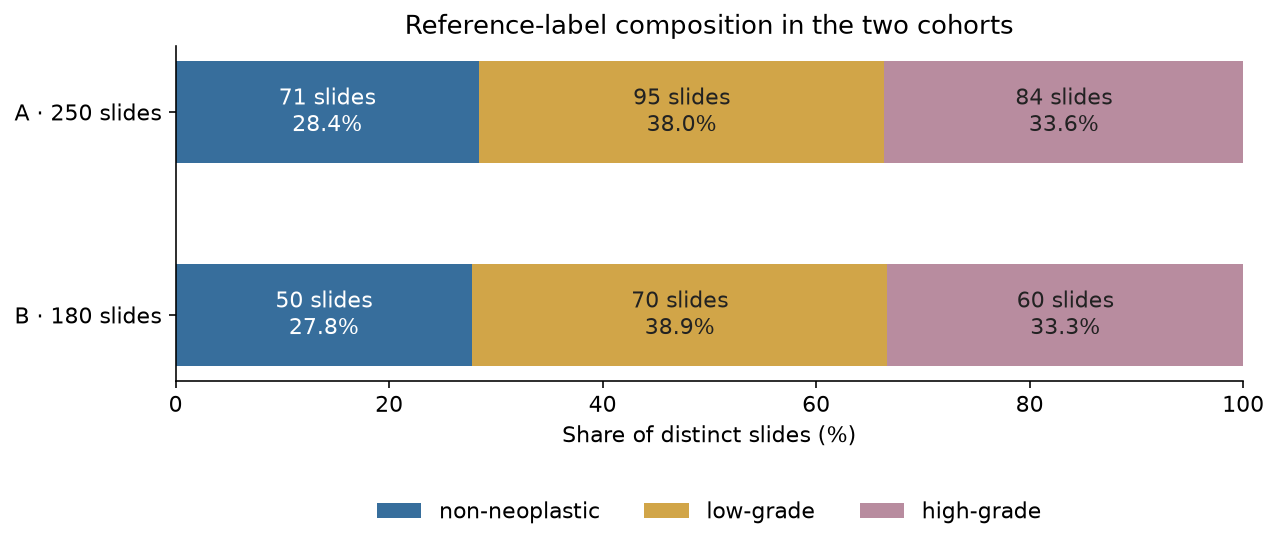

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 3.0))
for row,key in enumerate(["A", "B"]):
    counts = reference.loc[cohort_ids[key]].value_counts().reindex(CLASSES, fill_value=0)
    left = 0
    for cls, colour in zip(CLASSES, CLASS_COLOURS):
        n = int(counts[cls]); pct = 100 * n / len(cohort_ids[key])
        ax.barh(row, pct, left=left, color=colour, label=cls if row == 0 else None, height=0.5)
        ax.text(left+pct/2, row, f"{n} slides\n{pct:.1f}%", ha="center", va="center", color="white" if cls == "non-neoplastic" else "#222222", zorder=10)
        left += pct
ax.set(yticks=[0,1], yticklabels=["A · 250 slides", "B · 180 slides"], xlim=(0,100),
       xlabel="Share of distinct slides (%)", title="Reference-label composition in the two cohorts")
ax.invert_yaxis(); ax.legend(loc="upper center", bbox_to_anchor=(0.5,-0.30), ncol=3, frameon=False)
show_figure(fig)

### 0.4 Where do the slides and reference labels come from?

The [official IMP-CRS 2024 record](https://rdm.inesctec.pt/dataset/nis-2023-008) describes colorectal biopsy/polypectomy slides from IMP Diagnostics in Portugal. Its low-grade category represents low-grade dysplastic conventional adenomas; high-grade includes high-grade dysplasia and carcinomas. Therefore the binary grouping below is called **non-neoplastic versus low/high-grade**, rather than “cancer detection.” (Source checked September 22, 2026.)

[Neto et al., 2024, Methods—Datasets](https://www.nature.com/articles/s41698-024-00539-4) describes the parent dataset's label process: a pathologist reviewed each case and compared the classification with the original diagnostic report; disagreement received another pathologist's tie-break. This is published protocol-level evidence, not a per-slide adjudication audit of our selected 250. The paper also describes a separate later review of model-discordant **test** cases; we do not assume that review applies to this study subset.

The repository's `backend/src/seed-slide-list.ts` records **200 original slides plus 50 additional slides**. Its comment describes the extra 50 as easy cases, all six models correct, seed 123. The manifest verifies IDs, labels and group membership; the comment alone does not independently reproduce the model-based selection. The exact original-200 selection procedure and patient grouping remain unresolved here. These are selected study slides, not a verified random clinical sample.

The following embedded manifest snapshot makes the ID/label check portable. It was captured from that source on September 22. No database seeding script is executed.

In [7]:
SEED_SOURCE = "backend/src/seed-slide-list.ts"
SEED_SOURCE_SHA256 = '90808ad791317275020cdb6ea0ce3c459195b3b63b01ce6baa6449728e1c39ed'
SEED_SNAPSHOT = [{"slide_id":"CRC_0532","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_0580","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_0828","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_1515","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_1529","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2485","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2490","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2714","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2773","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3058","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3211","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3395","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3659","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3947","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_4312","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_4050","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_0114","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_3364","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_1233","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_0919","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_3857","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_0872","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_1119","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_0374","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_3699","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2611","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2125","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2310","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_1505","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3562","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_0554","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2460","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_0183","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3680","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_0632","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_0787","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_0675","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_3127","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_2291","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_3767","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_0489","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_2446","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_2768","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_1615","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_3245","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_2088","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_4013","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_0572","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_0925","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_0860","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2979","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_0448","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2525","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_3712","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_1095","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2715","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_4223","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_2126","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2368","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_1752","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2277","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2684","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2907","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2861","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_3423","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_1754","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_3610","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_3017","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_3979","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2014","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_4303","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2722","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2634","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2637","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3543","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3623","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2632","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_1524","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2024","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_1824","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3771","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2354","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_1042","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_3396","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_0391","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_3010","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_1531","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_2945","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_4427","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_2950","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3286","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_3168","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_0155","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_2181","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_3748","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_0457","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_3931","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3973","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3075","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_0427","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_1837","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_1742","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_3818","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_1659","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_1917","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2807","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_0740","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_2231","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_4268","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_0132","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_1468","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_1043","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_2450","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_2331","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3670","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_0844","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_1186","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_1416","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_1444","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_3918","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_0018","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_0652","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_1076","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2160","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2678","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_4011","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_4349","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2563","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_3601","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2238","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_4046","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2003","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_3351","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_3642","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3768","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3122","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2474","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3570","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_1513","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_1553","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_1130","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_2300","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_1906","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_0702","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_3445","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_4239","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_0547","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2105","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_3470","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2728","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_1330","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_0350","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_3534","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_0767","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_1192","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_3044","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_1555","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2617","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_4043","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2244","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_0123","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_1085","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_3789","reference":"high-grade","seed_group":"Original 200"},{"slide_id":"CRC_2750","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_0314","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2944","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2442","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2157","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_0731","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2183","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_1849","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_4357","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2301","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3386","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3200","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_3588","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_0937","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_1180","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_0069","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2472","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_2084","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_4318","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_0771","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_1699","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_4263","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_0135","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_0690","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_4245","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_4081","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_0671","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_2854","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_0824","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_1951","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_1003","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_0707","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_0885","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_3071","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_0308","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_0695","reference":"non-neoplastic","seed_group":"Original 200"},{"slide_id":"CRC_3014","reference":"low-grade","seed_group":"Original 200"},{"slide_id":"CRC_0005","reference":"non-neoplastic","seed_group":"Additional 50"},{"slide_id":"CRC_0100","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_0133","reference":"non-neoplastic","seed_group":"Additional 50"},{"slide_id":"CRC_0258","reference":"non-neoplastic","seed_group":"Additional 50"},{"slide_id":"CRC_0492","reference":"non-neoplastic","seed_group":"Additional 50"},{"slide_id":"CRC_0510","reference":"non-neoplastic","seed_group":"Additional 50"},{"slide_id":"CRC_0564","reference":"non-neoplastic","seed_group":"Additional 50"},{"slide_id":"CRC_0716","reference":"high-grade","seed_group":"Additional 50"},{"slide_id":"CRC_0720","reference":"high-grade","seed_group":"Additional 50"},{"slide_id":"CRC_0766","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_0891","reference":"high-grade","seed_group":"Additional 50"},{"slide_id":"CRC_1083","reference":"non-neoplastic","seed_group":"Additional 50"},{"slide_id":"CRC_1265","reference":"high-grade","seed_group":"Additional 50"},{"slide_id":"CRC_1270","reference":"non-neoplastic","seed_group":"Additional 50"},{"slide_id":"CRC_1308","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_1353","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_1568","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_1800","reference":"high-grade","seed_group":"Additional 50"},{"slide_id":"CRC_1979","reference":"high-grade","seed_group":"Additional 50"},{"slide_id":"CRC_1983","reference":"high-grade","seed_group":"Additional 50"},{"slide_id":"CRC_2068","reference":"non-neoplastic","seed_group":"Additional 50"},{"slide_id":"CRC_2091","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_2130","reference":"high-grade","seed_group":"Additional 50"},{"slide_id":"CRC_2218","reference":"high-grade","seed_group":"Additional 50"},{"slide_id":"CRC_2274","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_2293","reference":"high-grade","seed_group":"Additional 50"},{"slide_id":"CRC_2398","reference":"high-grade","seed_group":"Additional 50"},{"slide_id":"CRC_2518","reference":"non-neoplastic","seed_group":"Additional 50"},{"slide_id":"CRC_2530","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_2538","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_2629","reference":"high-grade","seed_group":"Additional 50"},{"slide_id":"CRC_2646","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_2721","reference":"high-grade","seed_group":"Additional 50"},{"slide_id":"CRC_2870","reference":"high-grade","seed_group":"Additional 50"},{"slide_id":"CRC_2935","reference":"non-neoplastic","seed_group":"Additional 50"},{"slide_id":"CRC_2963","reference":"non-neoplastic","seed_group":"Additional 50"},{"slide_id":"CRC_3039","reference":"high-grade","seed_group":"Additional 50"},{"slide_id":"CRC_3266","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_3289","reference":"non-neoplastic","seed_group":"Additional 50"},{"slide_id":"CRC_3322","reference":"non-neoplastic","seed_group":"Additional 50"},{"slide_id":"CRC_3478","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_3607","reference":"non-neoplastic","seed_group":"Additional 50"},{"slide_id":"CRC_3609","reference":"non-neoplastic","seed_group":"Additional 50"},{"slide_id":"CRC_3682","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_3815","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_4000","reference":"high-grade","seed_group":"Additional 50"},{"slide_id":"CRC_4048","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_4062","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_4186","reference":"low-grade","seed_group":"Additional 50"},{"slide_id":"CRC_4269","reference":"high-grade","seed_group":"Additional 50"}]
seed_frame = pd.DataFrame(SEED_SNAPSHOT)
assert seed_frame.slide_id.nunique() == len(seed_frame) == 250
seed_reference = seed_frame.set_index("slide_id").reference
assert set(seed_reference.index) == set(reference.index)
assert seed_reference.reindex(reference.index).eq(reference).all()
seed_groups = seed_frame.set_index("slide_id").seed_group
show_table(pd.DataFrame([{ "Cohort":GROUP_NAMES[k], **seed_groups.loc[ids].value_counts().to_dict()} for k,ids in cohort_ids.items()]))
print("Manifest source SHA-256:", SEED_SOURCE_SHA256)

Manifest source SHA-256: 90808ad791317275020cdb6ea0ce3c459195b3b63b01ce6baa6449728e1c39ed


Cohort,Original 200,Additional 50
A · Two readers / 250 slides,200,50
B · Three readers / 180 slides,143,37


### 0.5 Check limitations that could change an answer

Check exact duplicate-looking rows, missing viewport coordinates and the source of each retained diagnosis. Repeated rows are preserved: event IDs and subsecond timestamps are absent, so identical exported rows are not sufficient evidence that an upload should be deleted. Coordinate gaps do not invalidate an otherwise usable diagnosis, but matter for later spatial questions.

We also inventory long gaps within attempts. A gap is an interval between logged events, not a direct measure of active viewing or inattention. Active-time rules and coordinate/magnification validity will be settled when we reach those analyses.

In [8]:
duplicates = raw.duplicated(keep="first")
coordinate_fields = ["center_x0", "center_y0", "vbx0", "vby0", "vtx0", "vty0"]
quality_rows = []
for user in [*THREE, "alistair.heath", "admin"]:
    mask = raw.user_id.eq(user)
    d = diagnoses[diagnoses.user_id.eq(user)]
    quality_rows.append({"Reader":READER_NAMES[user], "Identical-row excess":int((duplicates & mask).sum()),
        "Rows missing viewport fields":int(raw.loc[mask, coordinate_fields].eq("").any(axis=1).sum()),
        "slide_next diagnoses":int(d.label_source.eq("slide_next").sum()),
        "Selection-only diagnoses":int(d.label_source.eq("label_select fallback").sum())})
quality = pd.DataFrame(quality_rows); show_table(quality)
duplicate_label_rows = int(raw.loc[duplicates, "event"].isin(["label_select", "slide_next"]).sum())
kept_rows = set((raw.index[~duplicates] + 2).tolist())
deduplicated_events = events[events.source_row.isin(kept_rows)]
deduplicated_labels = deduplicated_events[deduplicated_events.event.isin(["label_select", "slide_next"]) & deduplicated_events.label.ne("")]
deduplicated_labels = deduplicated_labels.drop_duplicates(["user_id", "slide_id"], keep="last")
duplicate_check = diagnoses.merge(deduplicated_labels[["user_id", "slide_id", "label"]], on=["user_id", "slide_id"], validate="one_to_one")
assert len(duplicate_check) == len(diagnoses) and duplicate_check.diagnosis.eq(duplicate_check.label).all()
gaps = events.sort_values(view_keys+["timestamp", "source_row"]).groupby(view_keys).timestamp.diff().dt.total_seconds()
print(f"All readers: {int(duplicates.sum())} identical-row excess copies preserved; {int(gaps.gt(60).sum())} within-attempt gaps over 60 seconds.")
print(f"Repeated label-event excess: {duplicate_label_rows}. A temporary exact-row deduplication sensitivity check changes zero extracted diagnoses; all original rows remain preserved.")

All readers: 444 identical-row excess copies preserved; 48 within-attempt gaps over 60 seconds.
Repeated label-event excess: 51. A temporary exact-row deduplication sensitivity check changes zero extracted diagnoses; all original rows remain preserved.


Reader,Identical-row excess,Rows missing viewport fields,slide_next diagnoses,Selection-only diagnoses
Muhammad Aslam,165,0,236,14
Ashish Bansal,79,10,222,28
Iftikhar Rana,200,6,166,14
Alistair Heath,0,0,6,1
Admin / test,0,0,0,1


In [9]:
first_diagnoses = labelled_views.drop_duplicates(["user_id", "slide_id"], keep="first")
repeat_check = first_diagnoses[["user_id", "slide_id", "diagnosis"]].merge(
    diagnoses[["user_id", "slide_id", "diagnosis"]], on=["user_id", "slide_id"], suffixes=("_first","_last"), validate="one_to_one")
primary_repeat = repeat_check[repeat_check.user_id.isin(THREE)]
changed = primary_repeat[primary_repeat.diagnosis_first.ne(primary_repeat.diagnosis_last)]
print(f"First versus latest labelled attempt: {len(changed)} changed diagnoses among {len(primary_repeat)} primary reader-slide records.")
print("Attempt-priority extraction versus last-labelled-event extraction: all diagnoses agree in this snapshot.")
same_second = events[events.event.isin(["label_select", "slide_next"]) & events.label.ne("")].groupby(
    ["user_id", "slide_id", "attempt", "timestamp"]).label.nunique()
print(f"Reader-slide-attempt timestamps containing different selected labels: {int(same_second.gt(1).sum())}; original CSV order breaks timestamp ties.")

ambiguous_keys = same_second[same_second.gt(1)].reset_index().iloc[:,:-1]
tie_resolutions=[]
for _, tie in ambiguous_keys.iterrows():
    later = events[events.user_id.eq(tie.user_id) & events.slide_id.eq(tie.slide_id)
                   & events.attempt.eq(tie.attempt) & events.event.eq("slide_next")
                   & events.label.ne("") & events.timestamp.gt(tie.timestamp)]
    tie_resolutions.append({"Reader":READER_NAMES.get(tie.user_id,tie.user_id),"Slide":tie.slide_id,
        "Later slide_next resolves final label": bool(len(later)),
        "Later committed label":later.iloc[-1].label if len(later) else "Unresolved; needs sensitivity check"})
show_table(pd.DataFrame(tie_resolutions))

First versus latest labelled attempt: 0 changed diagnoses among 680 primary reader-slide records.
Attempt-priority extraction versus last-labelled-event extraction: all diagnoses agree in this snapshot.
Reader-slide-attempt timestamps containing different selected labels: 1; original CSV order breaks timestamp ties.


Reader,Slide,Later slide_next resolves final label,Later committed label
Muhammad Aslam,CRC_1083,True,non-neoplastic


### Question 0 — interpretation and remaining limits

The two agreed populations are established from explicit slide-ID sets. Each Question 1 denominator is a count of labelled **slides per reader**, not events or attempts. Cohort B's reference-label composition resembles cohort A's, but that does not establish equal difficulty or random selection.

The checks support descriptive diagnostic-agreement calculations. They do not yet certify active-time estimates, physical distance/magnification calibration, tissue-normalised coverage, eye attention or patient independence. Those measurement choices remain visible prerequisites for later questions. Published reference-label procedures are informative, but we have not independently adjudicated the selected slides.

**Checkpoint for discussion:** explain why cohort B contains 180 slides but 540 reader–slide diagnoses, and why it would be misleading to treat those as 540 independent patients.

<a id="question-1"></a>

# Question 1 — How often does each diagnosis match the reference?

**Purpose.** Describe agreement with the recorded reference and identify the kinds of disagreement. “Correct”, “false positive” and “false negative” below mean **relative to that reference**, not an independent clinical judgement.

We answer two related questions:

1. **Exact three-class agreement:** does the selected label exactly match non-neoplastic, low-grade or high-grade?
2. **Combined-label agreement:** after combining low-grade and high-grade, does the reader distinguish that group from non-neoplastic?

A reference-high / reader-low diagnosis is a disagreement in the first calculation and a match in the second. The diagnosis does not change; the second question ignores that grade distinction.

### Method

Build a **confusion matrix** for each reader: rows are reference labels, columns are reader labels. The diagonal contains exact matches. Divide its sum by that reader's labelled-slide denominator. For the combined calculation, merge the low/high rows and columns and count matches again. The table and plots are computed separately for A and B.

In [10]:
def confusion_matrix(frame):
    return pd.crosstab(frame.reference, frame.diagnosis).reindex(index=CLASSES, columns=CLASSES, fill_value=0)

def agreement_statistics(frame):
    matrix = confusion_matrix(frame).to_numpy(dtype=int)
    n = int(matrix.sum()); exact = int(np.trace(matrix))
    tn = int(matrix[0,0]); fp = int(matrix[0,1:].sum())
    fn = int(matrix[1:,0].sum()); tp = int(matrix[1:,1:].sum())
    grade_only = int(matrix[1,2] + matrix[2,1])
    assert n == len(frame) == frame.slide_id.nunique()
    assert exact + grade_only + fp + fn == n
    assert exact + grade_only == tn + tp
    assert exact == int(frame.reference.eq(frame.diagnosis).sum())
    assert tn + tp == int(frame.reference.ne("non-neoplastic").eq(frame.diagnosis.ne("non-neoplastic")).sum())
    return {"n":n, "exact":exact, "binary":tn+tp, "grade_only":grade_only,
            "tp":tp, "tn":tn, "fp":fp, "fn":fn,
            "under":int(np.tril(matrix, -1).sum()), "over":int(np.triu(matrix, 1).sum())}

def ratio_text(numerator, denominator):
    return f"{numerator}/{denominator} ({100*numerator/denominator:.1f}%)" if denominator else "Not estimable (zero denominator)"

statistics = {}; matrices = {}
for key, cohort in cohorts.items():
    statistics[key] = {}; matrices[key] = {}
    for user in cohort_readers[key]:
        frame = cohort[cohort.user_id.eq(user)]
        statistics[key][user] = agreement_statistics(frame)
        matrices[key][user] = confusion_matrix(frame)

def summary_table(key):
    return pd.DataFrame([{"Reader":READER_NAMES[u], "Labelled slides":s["n"],
        "Exact three-class agreement":ratio_text(s["exact"],s["n"]),
        "Combined low/high agreement":ratio_text(s["binary"],s["n"])} for u,s in statistics[key].items()])

### Reading the figures

Each cell shows its **slide count** and its percentage of that **reference row**. For example, the high-grade row answers “of reference-high slides, how many were labelled non-neoplastic, low or high?” Each row totals 100%, allowing the same colour scale across readers. Overall exact agreement weights rows by how many slides they contain; it is not a simple average of the row percentages.

In [11]:
def plot_confusions(key):
    users = cohort_readers[key]
    fig, axes = plt.subplots(1, len(users), figsize=(4.1*len(users)+0.6, 4.9), squeeze=False)
    fig.subplots_adjust(left=0.10, right=0.89, top=0.80, bottom=0.20, wspace=0.55)
    tick_names = ["Non-\nneoplastic", "Low-grade", "High-grade"]
    for ax,user in zip(axes[0], users):
        values = matrices[key][user].to_numpy(dtype=int)
        totals = values.sum(axis=1)
        rates = np.divide(100*values, totals[:,None], out=np.zeros_like(values,dtype=float), where=totals[:,None]>0)
        im = ax.imshow(rates, vmin=0, vmax=100, cmap="Blues")
        for i in range(3):
            for j in range(3):
                ax.text(j,i,f"{values[i,j]}\n({rates[i,j]:.1f}%)",ha="center",va="center",
                        color="white" if rates[i,j] > 60 else "#202020",fontsize=10)
        ax.set(xticks=range(3), xticklabels=tick_names, yticks=range(3),
               yticklabels=[f"{t}\n(n={n})" for t,n in zip(tick_names,totals)],
               xlabel="Reader diagnosis", ylabel="Reference diagnosis", title=READER_NAMES[user])
        ax.tick_params(length=0, labelsize=9)
    cax=fig.add_axes([0.92,0.25,0.016,0.45]); fig.colorbar(im,cax=cax,label="Within reference class (%)")
    fig.suptitle(GROUP_NAMES[key]+" — three-class confusion",fontsize=14)
    show_figure(fig)

### 1A. Muhammad and Ashish on all 250 slides

Both readers face the same reference-label distribution. Read the exact-agreement column first, then inspect which off-diagonal cells contribute to disagreement.

Reader,Labelled slides,Exact three-class agreement,Combined low/high agreement
Muhammad Aslam,250,163/250 (65.2%),217/250 (86.8%)
Ashish Bansal,250,176/250 (70.4%),221/250 (88.4%)


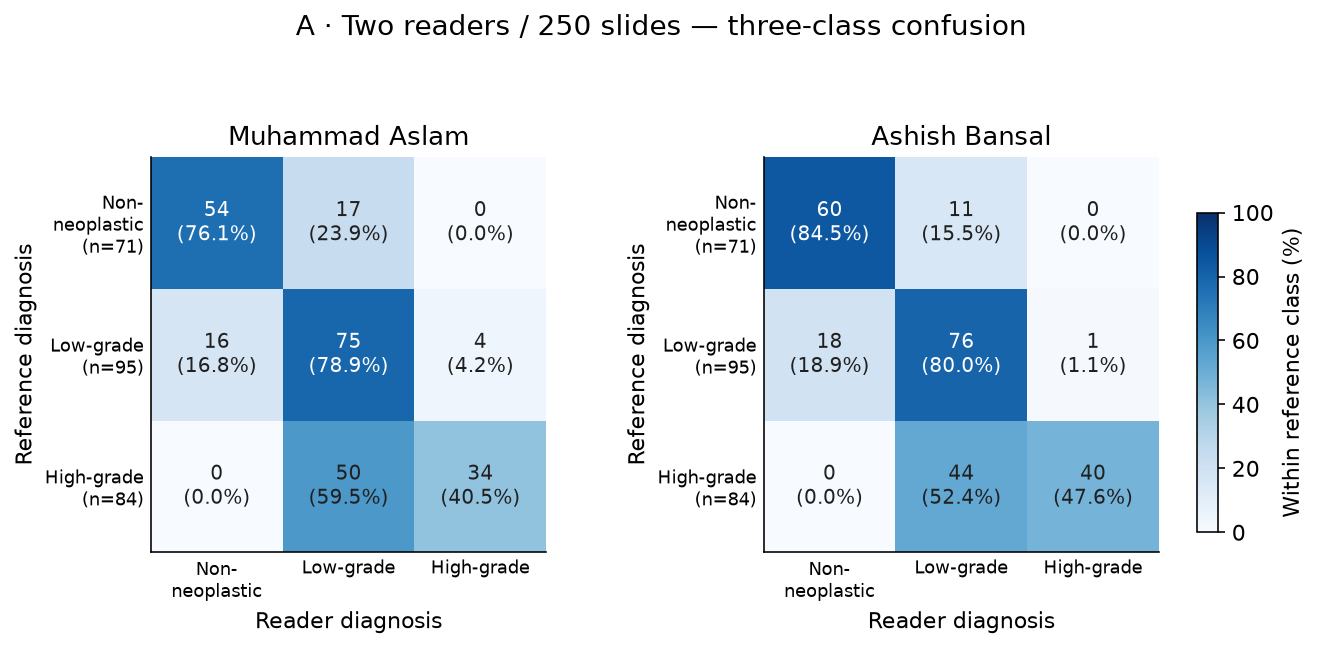

In [12]:
show_table(summary_table("A"))
plot_confusions("A")

In [13]:
lines=[]
for user in TWO:
    m=matrices["A"][user]; s=statistics["A"][user]
    lines.append(f"- **{READER_NAMES[user]}:** {ratio_text(s['exact'],s['n'])} exact agreement. "
                 f"Of {int(m.loc['high-grade'].sum())} reference-high slides, "
                 f"{int(m.loc['high-grade','low-grade'])} were called low-grade.")
display(Markdown("**Observed pattern:**\n\n"+"\n".join(lines)+
    "\n\nHigh-to-low disagreements account for a large part of the exact-label mismatch. "
    "That describes the direction of disagreement, not which judgement is clinically correct."))

**Observed pattern:**

- **Muhammad Aslam:** 163/250 (65.2%) exact agreement. Of 84 reference-high slides, 50 were called low-grade.
- **Ashish Bansal:** 176/250 (70.4%) exact agreement. Of 84 reference-high slides, 44 were called low-grade.

High-to-low disagreements account for a large part of the exact-label mismatch. That describes the direction of disagreement, not which judgement is clinically correct.

### 1B. All three readers on the same 180 slides

Muhammad and Ashish are recalculated on **Rana's exact slide set**. Their 250-slide percentages are not copied into this comparison. This removes differing slide membership as an explanation for differences within this table.

Reader,Labelled slides,Exact three-class agreement,Combined low/high agreement
Muhammad Aslam,180,123/180 (68.3%),156/180 (86.7%)
Ashish Bansal,180,128/180 (71.1%),158/180 (87.8%)
Iftikhar Rana,180,126/180 (70.0%),157/180 (87.2%)


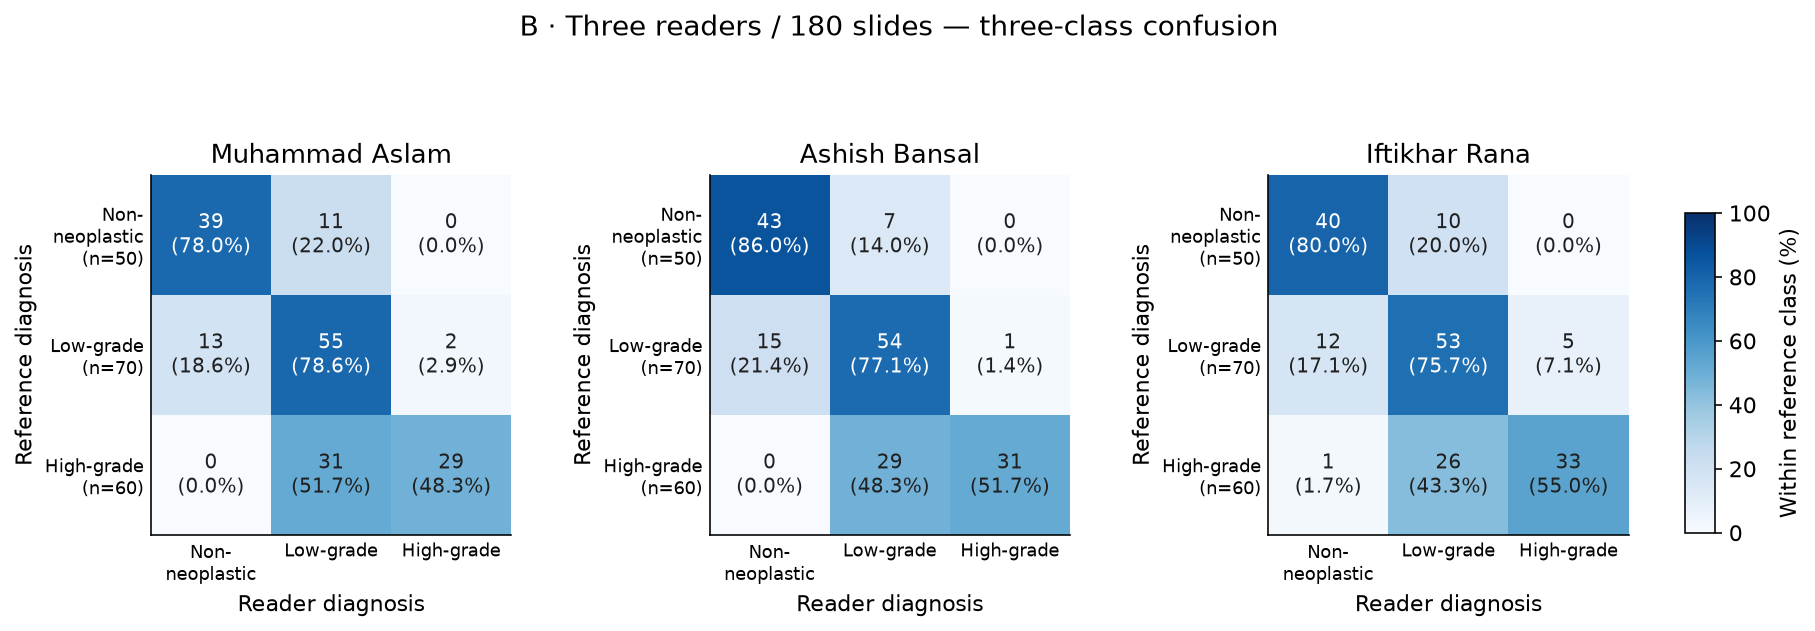

In [14]:
show_table(summary_table("B"))
plot_confusions("B")

In [15]:
display(Markdown("**Observed pattern:**\n\n"+"\n".join(
    f"- **{READER_NAMES[u]}:** {s['exact']} exact matches and {s['binary']} combined-label matches out of {s['n']}."
    for u,s in statistics["B"].items())+
    "\n\nThese are descriptive results on the same selected images. They do not establish a reliable "
    "ranking of readers, an effect of professional experience, or performance across all patients."))

**Observed pattern:**

- **Muhammad Aslam:** 123 exact matches and 156 combined-label matches out of 180.
- **Ashish Bansal:** 128 exact matches and 158 combined-label matches out of 180.
- **Iftikhar Rana:** 126 exact matches and 157 combined-label matches out of 180.

These are descriptive results on the same selected images. They do not establish a reliable ranking of readers, an effect of professional experience, or performance across all patients.

### 1.2 Which disagreements disappear when grades are combined?

Partition every reader's slides into four mutually exclusive groups: exact match; low-versus-high disagreement; reference non-neoplastic called low/high (binary false positive); and reference low/high called non-neoplastic (binary false negative). The four counts sum to the cohort denominator.

Only the second group changes from disagreement to agreement when we combine grades. This makes the difference between the two percentages visible without changing any diagnosis.

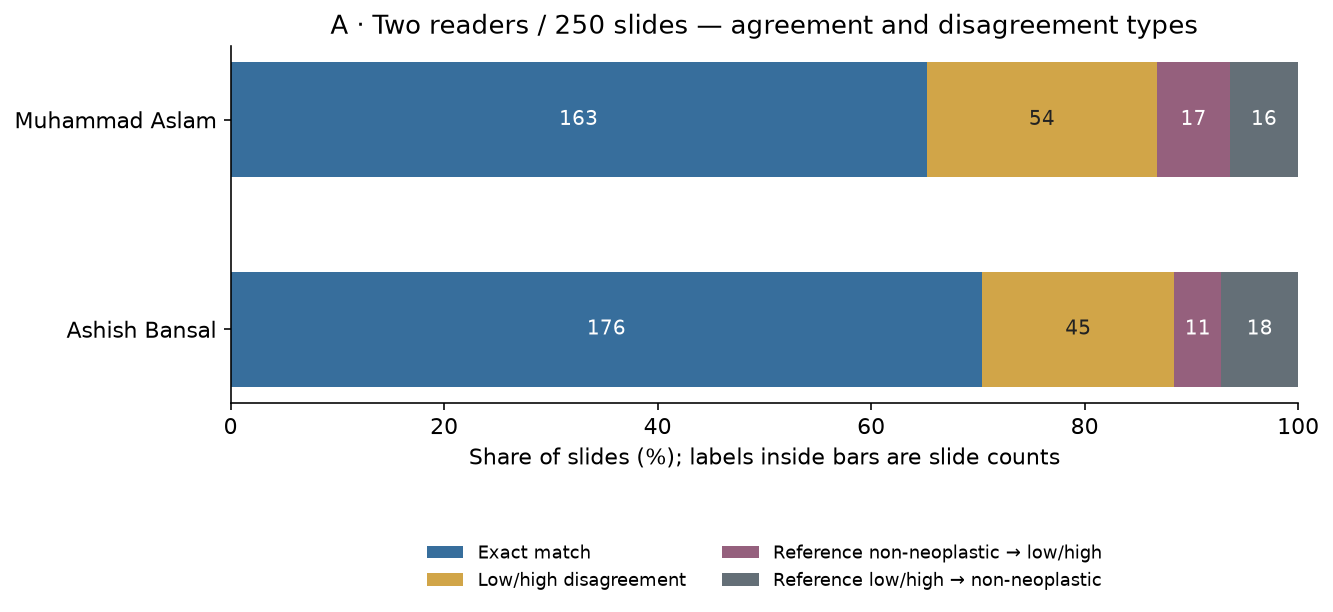

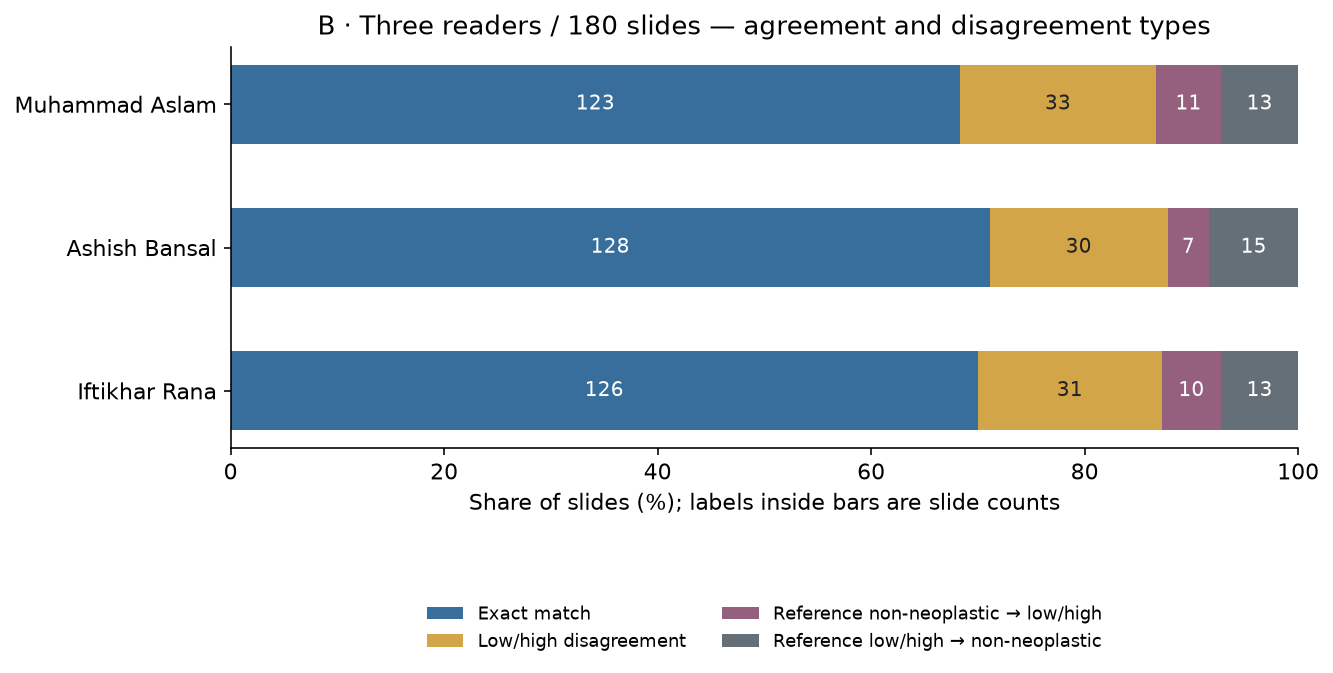

In [16]:
for key in ["A","B"]:
    fig, ax = plt.subplots(figsize=(9.5, 2.4+0.40*len(cohort_readers[key])))
    colours=["#376E9C", "#D1A548", "#95607D", "#646F77"]
    categories=[("exact","Exact match"),("grade_only","Low/high disagreement"),
                ("fp","Reference non-neoplastic → low/high"),("fn","Reference low/high → non-neoplastic")]
    for row,user in enumerate(cohort_readers[key]):
        left=0; s=statistics[key][user]
        for (field,label),colour in zip(categories,colours):
            count=s[field]; width=100*count/s["n"]
            ax.barh(row,width,left=left,height=0.55,color=colour,label=label if row==0 else None)
            if count: ax.text(left+width/2,row,str(count),ha="center",va="center",fontsize=10,
                             color="#222222" if field=="grade_only" else "white")
            left+=width
    ax.set(yticks=range(len(cohort_readers[key])), yticklabels=[READER_NAMES[u] for u in cohort_readers[key]],
           xlim=(0,100), xlabel="Share of slides (%); labels inside bars are slide counts",
           title=GROUP_NAMES[key]+" — agreement and disagreement types")
    ax.invert_yaxis(); ax.legend(loc="upper center",bbox_to_anchor=(0.5,-0.35),ncol=2,frameon=False,fontsize=9)
    show_figure(fig)

### 1.3 Work through Rana's calculation

Use the 180-slide confusion matrix above. The exact matches are the three diagonal cells. The combined calculation additionally accepts high-to-low and low-to-high calls. The following arithmetic uses the computed matrix, rather than manually typed result values.

In [17]:
matrix=matrices["B"]["iftikhar.rana"].to_numpy(dtype=int)
diagonal=np.diag(matrix).tolist(); high_to_low=int(matrix[2,1]); low_to_high=int(matrix[1,2])
s=statistics["B"]["iftikhar.rana"]
display(Markdown(f"**Exact:** {' + '.join(map(str,diagonal))} = **{s['exact']}** matches; "
    f"{ratio_text(s['exact'],s['n'])}.\n\n"
    f"**Combined:** {s['exact']} + {high_to_low} high-to-low + {low_to_high} low-to-high = "
    f"**{s['binary']}** matches; {ratio_text(s['binary'],s['n'])}.\n\n"
    f"The remaining **{s['fp']+s['fn']}** disagreements cross the non-neoplastic/low-high boundary: "
    f"**{s['fp']}** false positives and **{s['fn']}** false negatives relative to the reference."))

**Exact:** 40 + 53 + 33 = **126** matches; 126/180 (70.0%).

**Combined:** 126 + 26 high-to-low + 5 low-to-high = **157** matches; 157/180 (87.2%).

The remaining **23** disagreements cross the non-neoplastic/low-high boundary: **10** false positives and **13** false negatives relative to the reference.

### 1.4 What do sensitivity, specificity and precision add?

The combined-label agreement percentage is useful, but it mixes two directions of error. Here **positive** means low-grade or high-grade; **negative** means non-neoplastic.

| Measure | Question | Calculation |
|---|---|---|
| Sensitivity / recall | Of reference-positive slides, how many does the reader call positive? | TP / (TP + FN) |
| Specificity | Of reference-negative slides, how many does the reader call negative? | TN / (TN + FP) |
| Precision | Of the slides the reader calls positive, how many are reference-positive? | TP / (TP + FP) |
| False-positive rate | Of reference-negative slides, how many are called positive? | FP / (TN + FP) |
| False-negative rate | Of reference-positive slides, how many are called negative? | FN / (TP + FN) |

The denominators differ. A false-positive rate is not FP divided by all slides; precision depends on the reference-class composition of this selected cohort. These are reference-based measures, not validated clinical screening performance.

In [18]:
for key in ["A","B"]:
    display(Markdown("**"+GROUP_NAMES[key]+"**"))
    show_table(pd.DataFrame([{"Reader":READER_NAMES[u], "TP":s["tp"], "TN":s["tn"], "FP":s["fp"], "FN":s["fn"]}
                            for u,s in statistics[key].items()]))
    show_table(pd.DataFrame([{"Reader":READER_NAMES[u],
        "Sensitivity":ratio_text(s["tp"],s["tp"]+s["fn"]),
        "Specificity":ratio_text(s["tn"],s["tn"]+s["fp"]),
        "Precision":ratio_text(s["tp"],s["tp"]+s["fp"]),
        "FP rate":ratio_text(s["fp"],s["tn"]+s["fp"]),
        "FN rate":ratio_text(s["fn"],s["tp"]+s["fn"])} for u,s in statistics[key].items()]))

**A · Two readers / 250 slides**

Reader,TP,TN,FP,FN
Muhammad Aslam,163,54,17,16
Ashish Bansal,161,60,11,18


Reader,Sensitivity,Specificity,Precision,FP rate,FN rate
Muhammad Aslam,163/179 (91.1%),54/71 (76.1%),163/180 (90.6%),17/71 (23.9%),16/179 (8.9%)
Ashish Bansal,161/179 (89.9%),60/71 (84.5%),161/172 (93.6%),11/71 (15.5%),18/179 (10.1%)


**B · Three readers / 180 slides**

Reader,TP,TN,FP,FN
Muhammad Aslam,117,39,11,13
Ashish Bansal,115,43,7,15
Iftikhar Rana,117,40,10,13


Reader,Sensitivity,Specificity,Precision,FP rate,FN rate
Muhammad Aslam,117/130 (90.0%),39/50 (78.0%),117/128 (91.4%),11/50 (22.0%),13/130 (10.0%)
Ashish Bansal,115/130 (88.5%),43/50 (86.0%),115/122 (94.3%),7/50 (14.0%),15/130 (11.5%)
Iftikhar Rana,117/130 (90.0%),40/50 (80.0%),117/127 (92.1%),10/50 (20.0%),13/130 (10.0%)


### 1.5 Check class-specific agreement

The confusion matrix already shows class-specific **recall** in each diagonal cell's percentage. Class-specific **precision** uses the corresponding prediction column instead: among calls of that grade, how many match the reference?

The expandable tables expose both denominators for each grade. They help distinguish poor recognition of a reference class from overuse of a reader label. No additional statistical test is being introduced.

In [19]:
per_class_rows=[]
for key in ["A","B"]:
    rows=[]
    for user in cohort_readers[key]:
        m=matrices[key][user]
        for cls in CLASSES:
            match=int(m.loc[cls,cls]); support=int(m.loc[cls].sum()); called=int(m[cls].sum())
            row={"Reader":READER_NAMES[user],"Reference class":cls,"Reference slides":support,
                 "Reader calls":called,"Recall":ratio_text(match,support),"Precision":ratio_text(match,called)}
            rows.append(row); per_class_rows.append({"cohort":key,**row})
    display(HTML("<details><summary>Per-grade recall and precision — "+escape(GROUP_NAMES[key])+"</summary>"+
                 pd.DataFrame(rows).to_html(index=False,border=0)+"</details>"))

Reader,Reference class,Reference slides,Reader calls,Recall,Precision
Muhammad Aslam,non-neoplastic,71,70,54/71 (76.1%),54/70 (77.1%)
Muhammad Aslam,low-grade,95,142,75/95 (78.9%),75/142 (52.8%)
Muhammad Aslam,high-grade,84,38,34/84 (40.5%),34/38 (89.5%)
Ashish Bansal,non-neoplastic,71,78,60/71 (84.5%),60/78 (76.9%)
Ashish Bansal,low-grade,95,131,76/95 (80.0%),76/131 (58.0%)
Ashish Bansal,high-grade,84,41,40/84 (47.6%),40/41 (97.6%)


Reader,Reference class,Reference slides,Reader calls,Recall,Precision
Muhammad Aslam,non-neoplastic,50,52,39/50 (78.0%),39/52 (75.0%)
Muhammad Aslam,low-grade,70,97,55/70 (78.6%),55/97 (56.7%)
Muhammad Aslam,high-grade,60,31,29/60 (48.3%),29/31 (93.5%)
Ashish Bansal,non-neoplastic,50,58,43/50 (86.0%),43/58 (74.1%)
Ashish Bansal,low-grade,70,90,54/70 (77.1%),54/90 (60.0%)
Ashish Bansal,high-grade,60,32,31/60 (51.7%),31/32 (96.9%)
Iftikhar Rana,non-neoplastic,50,53,40/50 (80.0%),40/53 (75.5%)
Iftikhar Rana,low-grade,70,89,53/70 (75.7%),53/89 (59.6%)
Iftikhar Rana,high-grade,60,38,33/60 (55.0%),33/38 (86.8%)


### 1.6 Does using selection-only fallback labels drive the headline?

For a stricter sensitivity check, recover diagnoses from labelled `slide_next` events only. First show coverage lost within each agreed cohort. Then restrict **all readers together** to the strict labels' common slide intersection, so the sensitivity comparison remains matched.

This is a supplementary subset check. It does not replace the agreed 250/180 primary analyses, and a similar percentage cannot prove fallback labels are reliable: excluding fallback slides also changes membership. We also compare strict and primary diagnoses wherever both exist.

In [20]:
strict = events[events.event.eq("slide_next") & events.label.ne("")].drop_duplicates(["user_id","slide_id"],keep="last")
strict = strict.rename(columns={"label":"diagnosis", "ground_truth":"reference"})
strict = strict[["user_id","slide_id","diagnosis","reference"]]
for key in ["A","B"]:
    members=set(cohort_ids[key]); strict_sets={u:set(strict.loc[strict.user_id.eq(u),"slide_id"]) & members for u in cohort_readers[key]}
    common=set.intersection(*strict_sets.values())
    display(Markdown("**"+GROUP_NAMES[key]+f": strict common subset = {len(common)} slides.**"))
    rows=[]
    for user in cohort_readers[key]:
        d=strict[strict.user_id.eq(user)&strict.slide_id.isin(common)]
        s=agreement_statistics(d)
        primary=cohorts[key][cohorts[key].user_id.eq(user)]
        overlap=primary.merge(strict[strict.user_id.eq(user)],on=["user_id","slide_id"],suffixes=("_primary","_strict"))
        rows.append({"Reader":READER_NAMES[user],"Strict labels available":len(strict_sets[user]),
            "Excluded from primary N":len(members)-len(strict_sets[user]),
            "Strict common exact":ratio_text(s["exact"],s["n"]),
            "Strict common combined":ratio_text(s["binary"],s["n"]),
            "Changed labels where both exist":int(overlap.diagnosis_primary.ne(overlap.diagnosis_strict).sum())})
    show_table(pd.DataFrame(rows))

**A · Two readers / 250 slides: strict common subset = 209 slides.**

Reader,Strict labels available,Excluded from primary N,Strict common exact,Strict common combined,Changed labels where both exist
Muhammad Aslam,236,14,135/209 (64.6%),181/209 (86.6%),0
Ashish Bansal,222,28,150/209 (71.8%),187/209 (89.5%),0


**B · Three readers / 180 slides: strict common subset = 135 slides.**

Reader,Strict labels available,Excluded from primary N,Strict common exact,Strict common combined,Changed labels where both exist
Muhammad Aslam,168,12,94/135 (69.6%),117/135 (86.7%),0
Ashish Bansal,159,21,100/135 (74.1%),120/135 (88.9%),0
Iftikhar Rana,166,14,96/135 (71.1%),118/135 (87.4%),0


### Question 1 — what we can conclude

The results describe how these readers' final extracted diagnoses agree with the recorded reference on two explicit slide sets. Exact grading agreement and the combined-label measure answer different questions. The confusion matrices reveal the direction of mismatches; the low/high merge explains the increase in the combined percentage.

**Limits that change interpretation**

- The reference is an expert-derived dataset label, not an unquestionable clinical adjudication. A disagreement is not proof that either the reader or the reference is wrong.
- The slide selection, Rana's progress-dependent subset and only three main readers limit generalisation. This analysis makes no reliable reader-ranking claim.
- The same slides recur across readers and cohorts. No confidence intervals or significance claims based on independent reader-slide rows are made. Patient identities/grouping are unavailable in the export; no population-level uncertainty estimate is supplied.
- Duplicate-looking events are retained; diagnosis calculations count one reader–slide label. Fallback and repeat-attempt effects are explicitly checked. A future export must be re-audited.
- Counts alone cannot establish diagnostic-convention differences, reasons for disagreement, superiority of a model or clinical effectiveness.

**Checkpoint for discussion:** using Rana's matrix, explain why the combined percentage rises without changing any diagnosis, then explain why the specificity and precision denominators differ.

<a id="question-2"></a>

# Question 2 — Do readers make the same diagnostic decisions on the same slides?

**Purpose.** Question 1 compared each reader with the reference. Question 2 compares the readers **with each other**. The first part of this calculation does not use the reference at all.

We preserve the two agreed populations:

- **A:** Muhammad and Ashish, paired on all 250 slides.
- **B:** Muhammad, Ashish and Rana, restricted to the same 180 slides. We examine each of the three reader pairs and then all-three unanimity.

There are two label definitions, as in Question 1: exact three-class labels, and non-neoplastic versus combined low/high-grade. We start with the concrete number of matching slide labels, explain chance-adjusted agreement afterwards, and finally bring the reference back to distinguish shared matches from shared disagreements.

**The question is consistency, not who is right.** If two readers both call a reference-high slide low-grade, they agree with each other but both disagree with the reference.

### 2.1 Put each slide's diagnoses on the same row

Join by **slide ID** within each cohort, using the one-label-per-reader-and-slide table established in Question 0. Do not join by event position or assume the readers viewed slides in the same order. A row is one image with the corresponding diagnoses alongside it.

The small preview below is sorted by slide ID; it is a deterministic illustration, not a selected collection of successes or disagreements.

In [21]:
from itertools import combinations

q2_wide = {}
for group_key in ["A", "B"]:
    paired = cohorts[group_key].pivot(index="slide_id", columns="user_id", values="diagnosis")
    paired = paired.reindex(index=cohort_ids[group_key], columns=cohort_readers[group_key])
    assert not paired.isna().any().any()
    assert len(paired) == len(cohort_ids[group_key])
    paired["reference"] = reference.reindex(paired.index)
    assert not paired.reference.isna().any()
    q2_wide[group_key] = paired

preview = q2_wide["B"].head(5).reset_index().rename(columns={"slide_id":"Slide", "reference":"Reference", **READER_NAMES})
show_table(preview)

user_id,Slide,Muhammad Aslam,Ashish Bansal,Iftikhar Rana,Reference
,CRC_0018,low-grade,low-grade,low-grade,high-grade
,CRC_0069,low-grade,low-grade,low-grade,low-grade
,CRC_0100,low-grade,low-grade,low-grade,low-grade
,CRC_0114,low-grade,low-grade,low-grade,high-grade
,CRC_0123,high-grade,low-grade,high-grade,high-grade


### 2.2 Count pairwise agreement

For each pair, count slides where the two labels match and divide by the shared-slide denominator. Repeat after merging low/high-grade. Neither calculation requires a reference diagnosis.

The cross-tabulation figures place one reader on the rows and the other on the columns. A diagonal cell means the **readers agree**, not that the diagnosis is correct. Off-diagonal cells show the direction of disagreement between those two readers. Cell numbers are slide counts.

In [22]:
def q2_cross_table(first, second, levels):
    return pd.crosstab(pd.Series(list(first), name="first"),
                       pd.Series(list(second), name="second")).reindex(index=levels, columns=levels, fill_value=0)

def q2_combined(values):
    return pd.Series(list(values)).map({"non-neoplastic":0, "low-grade":1, "high-grade":1})

def q2_pair_counts(paired, first, second):
    first_labels, second_labels = paired[first], paired[second]
    matrix = q2_cross_table(first_labels, second_labels, CLASSES)
    combined_matrix = q2_cross_table(q2_combined(first_labels), q2_combined(second_labels), [0,1])
    n = len(paired); same = int(first_labels.eq(second_labels).sum())
    combined_same = int(q2_combined(first_labels).eq(q2_combined(second_labels)).sum())
    assert int(matrix.to_numpy().sum()) == int(combined_matrix.to_numpy().sum()) == n
    assert int(np.trace(matrix.to_numpy())) == same
    assert int(np.trace(combined_matrix.to_numpy())) == combined_same
    return {"first":first, "second":second, "n":n, "exact":same, "combined":combined_same,
            "matrix":matrix, "combined_matrix":combined_matrix}

q2_pairs = {group_key:[q2_pair_counts(q2_wide[group_key], first, second)
                       for first,second in combinations(cohort_readers[group_key],2)]
            for group_key in ["A","B"]}
FIRST_NAMES = {"muhammad.aslam":"Muhammad", "ashish.bansal":"Ashish", "iftikhar.rana":"Rana"}

def q2_pair_name(pair):
    return FIRST_NAMES[pair["first"]] + " / " + FIRST_NAMES[pair["second"]]

def q2_raw_table(group_key):
    return pd.DataFrame([{"Reader pair":q2_pair_name(p), "Shared slides":p["n"],
        "Exact three-class agreement":ratio_text(p["exact"],p["n"]),
        "Combined low/high agreement":ratio_text(p["combined"],p["n"])}
        for p in q2_pairs[group_key]])

In [23]:
def q2_plot_pairs(group_key):
    pairs = q2_pairs[group_key]; count = len(pairs)
    fig, axs = plt.subplots(1, count, figsize=(4.2*count+0.8, 4.6), squeeze=False)
    fig.subplots_adjust(left=0.14 if count==1 else 0.075, right=0.85 if count==1 else 0.91,
                        bottom=0.21, top=0.78, wspace=0.6)
    scale_max = max(int(p["matrix"].to_numpy().max()) for p in pairs)
    ticks = ["Non-\nneoplastic","Low-grade","High-grade"]
    for ax,pair in zip(axs[0],pairs):
        values=pair["matrix"].to_numpy(dtype=int)
        im=ax.imshow(values,vmin=0,vmax=scale_max,cmap="Blues")
        for row in range(3):
            for column in range(3):
                ax.text(column,row,str(values[row,column]),ha="center",va="center",fontsize=12,
                        color="white" if values[row,column]>0.60*scale_max else "#202020",zorder=10)
        ax.set(xticks=range(3),xticklabels=ticks,yticks=range(3),yticklabels=ticks,
               xlabel=FIRST_NAMES[pair["second"]]+"'s diagnosis",
               ylabel=FIRST_NAMES[pair["first"]]+"'s diagnosis",title=q2_pair_name(pair))
        ax.tick_params(length=0,labelsize=9)
    cax=fig.add_axes([0.89 if count==1 else 0.94,0.25,0.024 if count==1 else 0.012,0.45])
    fig.colorbar(im,cax=cax,label="Slide count")
    fig.suptitle(GROUP_NAMES[group_key]+"\nReader–reader label cross-tabulations",fontsize=13)
    show_figure(fig)

### 2A. Muhammad and Ashish on all 250 slides

Read the matching-label counts first. The difference between the exact and combined counts comes from slides where one reader selected low-grade and the other selected high-grade.

Reader pair,Shared slides,Exact three-class agreement,Combined low/high agreement
Muhammad / Ashish,250,221/250 (88.4%),240/250 (96.0%)


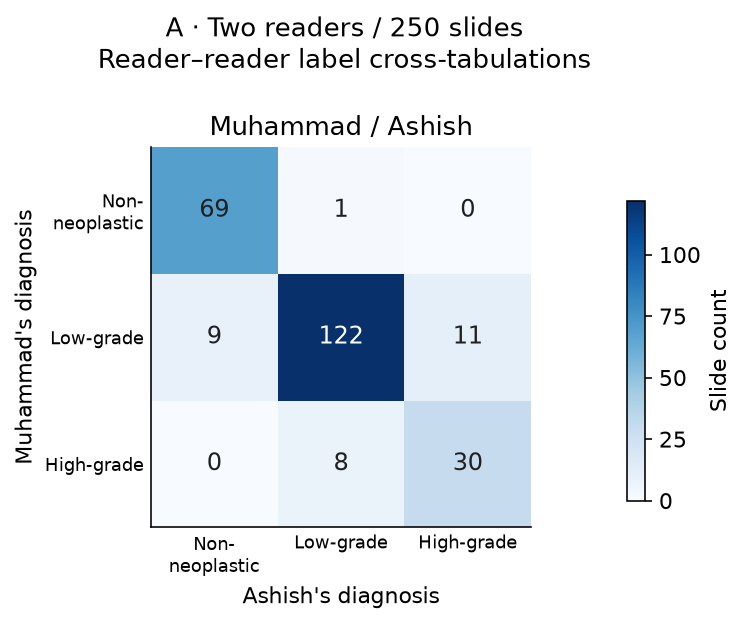

**Worked count:** 69 + 122 + 30 = **221** same-label slides out of 250. Combining grades adds **19** low/high disagreements to the agreement count; **10** slides still cross the non-neoplastic/low-high boundary.

In [24]:
show_table(q2_raw_table("A"))
q2_plot_pairs("A")
pair=q2_pairs["A"][0]
diagonal=np.diag(pair["matrix"].to_numpy()).tolist()
display(Markdown(f"**Worked count:** {' + '.join(map(str,diagonal))} = **{pair['exact']}** same-label slides "
    f"out of {pair['n']}. Combining grades adds **{pair['combined']-pair['exact']}** low/high disagreements "
    f"to the agreement count; **{pair['n']-pair['combined']}** slides still cross the non-neoplastic/low-high boundary."))

### 2B. Each reader pair on the same 180 slides

All three rows below use identical slide membership. In particular, Muhammad/Ashish is recomputed on the 180-slide subset; its 250-slide value is not reused. Pairwise results show which readers give similar labels, not which reader is more accurate.

Reader pair,Shared slides,Exact three-class agreement,Combined low/high agreement
Muhammad / Ashish,180,161/180 (89.4%),174/180 (96.7%)
Muhammad / Rana,180,146/180 (81.1%),167/180 (92.8%)
Ashish / Rana,180,153/180 (85.0%),169/180 (93.9%)


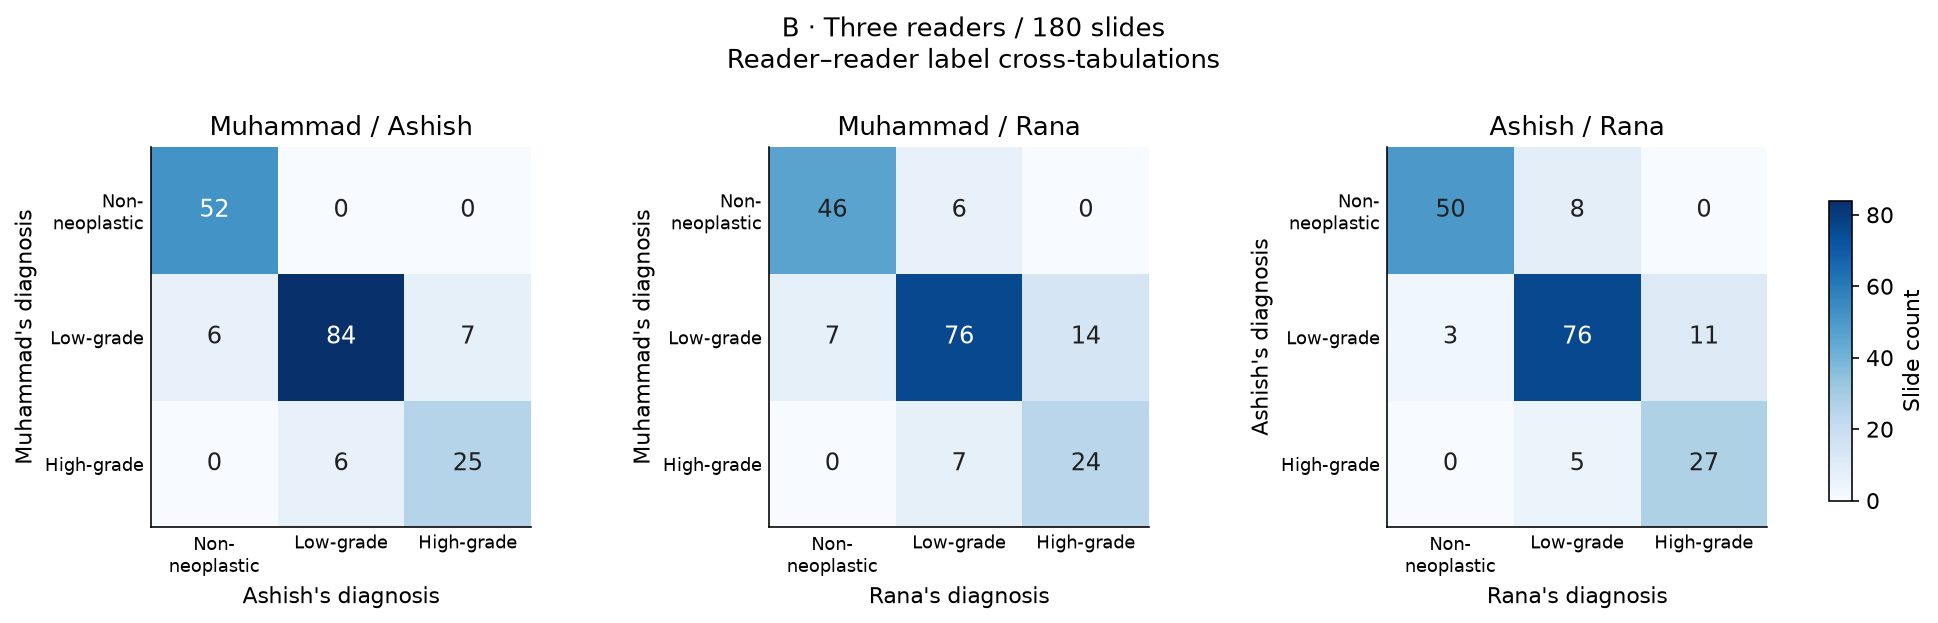

In [25]:
show_table(q2_raw_table("B"))
q2_plot_pairs("B")

### 2.3 How often do all three agree?

Pairwise agreement and three-reader unanimity have different numerators. One slide can contain a two-to-one split: one pair agrees while the other two pairs disagree. That slide contributes one agreeing pair, but **does not** count as unanimous.

Count the number of distinct reader labels on each slide: one means unanimous, two means a two-to-one split, and three means all give different labels. With the combined two-category definition, three different labels are impossible. We report unanimity directly; Cohen's kappa is a two-label-source coefficient and is not applied to all three readers as though they were one pair.

Label definition,All three agree,Two-to-one split,All different
Exact three-class,140/180 (77.8%),40/180 (22.2%),0/180 (0.0%)
Combined low/high,165/180 (91.7%),15/180 (8.3%),0/180 (0.0%)


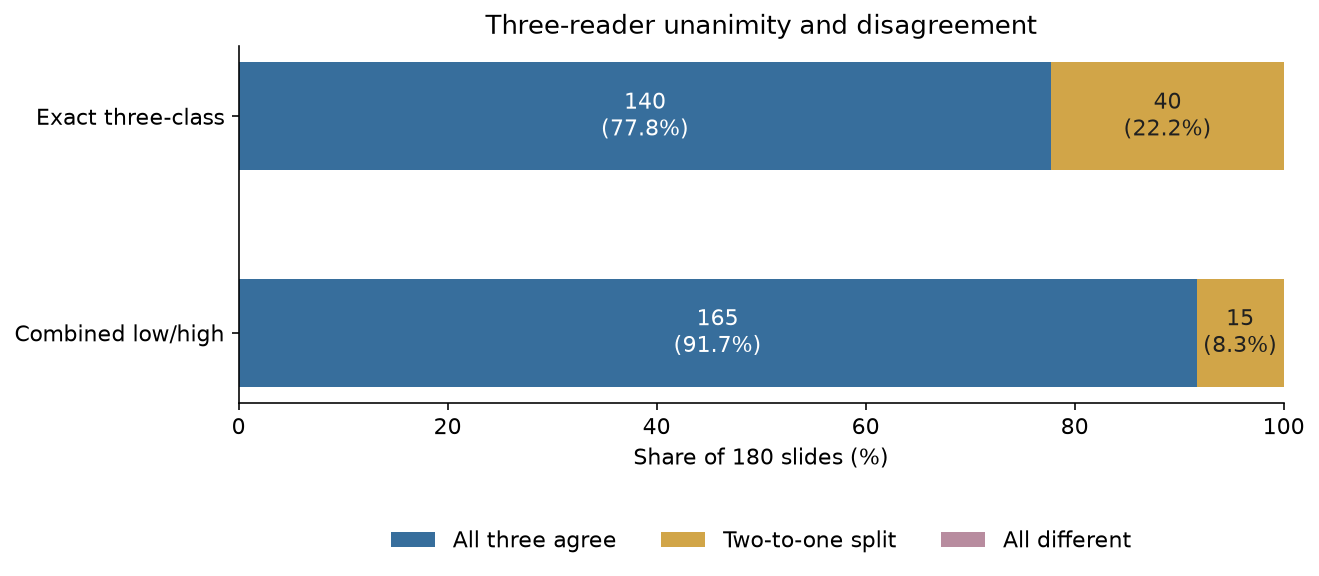

In [26]:
q2_group_results = {}
q2_unique_by_definition = {}
q2_group_reference_matches = {}
for definition,binary in [("Exact three-class",False),("Combined low/high",True)]:
    reader_labels = q2_wide["B"][THREE].copy()
    reference_labels = q2_wide["B"].reference.copy()
    if binary:
        reader_labels = reader_labels.ne("non-neoplastic").astype(int)
        reference_labels = reference_labels.ne("non-neoplastic").astype(int)
    unique = reader_labels.nunique(axis=1)
    reference_matches = reader_labels.eq(reference_labels,axis=0).sum(axis=1)
    q2_unique_by_definition[definition] = unique
    q2_group_reference_matches[definition] = reference_matches
    q2_group_results[definition] = {"n":len(unique), "unanimous":int(unique.eq(1).sum()),
        "two_to_one":int(unique.eq(2).sum()), "all_different":int(unique.eq(3).sum()),
        "all_match_reference":int(reference_matches.eq(3).sum()),
        "same_disagreement":int((unique.eq(1)&reference_matches.eq(0)).sum())}
    assert sum(q2_group_results[definition][v] for v in ["unanimous","two_to_one","all_different"]) == len(unique)

show_table(pd.DataFrame([{"Label definition":name, "All three agree":ratio_text(x["unanimous"],x["n"]),
    "Two-to-one split":ratio_text(x["two_to_one"],x["n"]), "All different":ratio_text(x["all_different"],x["n"])}
    for name,x in q2_group_results.items()]))
fig,ax=plt.subplots(figsize=(9.3,3.2))
q2_patterns=[("unanimous","All three agree","#376E9C"),("two_to_one","Two-to-one split","#D1A548"),
             ("all_different","All different","#B88C9F")]
for row,(name,x) in enumerate(q2_group_results.items()):
    left=0
    for field,label,colour in q2_patterns:
        value=x[field]; width=100*value/x["n"]
        ax.barh(row,width,left=left,height=0.5,color=colour,label=label if row==0 else None)
        if value:
            ax.text(left+width/2,row,f"{value}\n({width:.1f}%)",ha="center",va="center",
                    color="white" if field=="unanimous" else "#202020",zorder=10)
        left+=width
ax.set(yticks=[0,1],yticklabels=list(q2_group_results),xlim=(0,100),xlabel="Share of 180 slides (%)",
       title="Three-reader unanimity and disagreement")
ax.invert_yaxis();ax.legend(loc="upper center",bbox_to_anchor=(0.5,-0.30),ncol=3,frameon=False)
show_figure(fig)

### 2.4 What does chance-adjusted agreement add?

If both readers use one label frequently, some matching labels are expected even under an independence baseline. **Cohen's kappa** compares observed agreement with that baseline:

\[
\kappa = \frac{p_o-p_e}{1-p_e},\qquad
p_e=\sum_c p_{1c}p_{2c}.
\]

Here \(p_o\) is the observed matching fraction and \(p_{1c},p_{2c}\) are the two readers' observed label proportions. The baseline represents independent label draws preserving those proportions; it does not assert that the pathologists guessed. Kappa is not a percentage accuracy, and its value depends on the label distributions. We show the raw counts alongside it and avoid automatic verbal cutoffs.

We use **unweighted kappa** for exact three-class labels and for the combined binary labels. As a supplementary ordinal view, **linear-weighted kappa** assigns a one-step disagreement half the penalty of a two-step disagreement using the order non-neoplastic → low-grade → high-grade. This is a statistical weighting convention, not a claim that clinical consequences have that ratio.

The older report's three-class kappa around 0.83 was **linear-weighted**; it must not be confused with the unweighted coefficient. [Formula and coefficient definition](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.cohen_kappa_score.html).

In [27]:
def q2_kappa_components(matrix, linear=False):
    counts=np.asarray(matrix,dtype=float); n=counts.sum()
    if n==0:return {"kappa":np.nan,"observed_agreement":np.nan,"expected_agreement":np.nan}
    expected=np.outer(counts.sum(axis=1)/n,counts.sum(axis=0)/n)
    classes=counts.shape[0]
    penalty=np.abs(np.arange(classes)[:,None]-np.arange(classes)[None,:])/(classes-1) if linear else 1-np.eye(classes)
    observed_disagreement=float((counts/n*penalty).sum())
    expected_disagreement=float((expected*penalty).sum())
    kappa=np.nan if np.isclose(expected_disagreement,0) else 1-observed_disagreement/expected_disagreement
    return {"kappa":float(kappa),"observed_agreement":1-observed_disagreement,
            "expected_agreement":1-expected_disagreement}

for group_key in ["A","B"]:
    for pair in q2_pairs[group_key]:
        pair["kappa"] = q2_kappa_components(pair["matrix"])["kappa"]
        pair["linear_kappa"] = q2_kappa_components(pair["matrix"],linear=True)["kappa"]
        pair["combined_kappa"] = q2_kappa_components(pair["combined_matrix"])["kappa"]

for group_key in ["A","B"]:
    display(Markdown("**"+GROUP_NAMES[group_key]+"**"))
    show_table(pd.DataFrame([{"Reader pair":q2_pair_name(p),
        "Three-class unweighted κ":f"{p['kappa']:.3f}",
        "Three-class linear-weighted κ":f"{p['linear_kappa']:.3f}",
        "Combined-label κ":f"{p['combined_kappa']:.3f}"} for p in q2_pairs[group_key]]))

**A · Two readers / 250 slides**

Reader pair,Three-class unweighted κ,Three-class linear-weighted κ,Combined-label κ
Muhammad / Ashish,0.803,0.830,0.904


**B · Three readers / 180 slides**

Reader pair,Three-class unweighted κ,Three-class linear-weighted κ,Combined-label κ
Muhammad / Ashish,0.826,0.852,0.922
Muhammad / Rana,0.691,0.739,0.825
Ashish / Rana,0.758,0.797,0.857


In [28]:
q2_example=q2_pairs["A"][0]
q2_components=q2_kappa_components(q2_example["matrix"])
q2_margins=q2_example["matrix"].to_numpy(dtype=int)
show_table(pd.DataFrame({"Label":CLASSES,"Muhammad's calls":q2_margins.sum(axis=1),"Ashish's calls":q2_margins.sum(axis=0)}))
q2_products=[f"({a}/{q2_example['n']} × {b}/{q2_example['n']})" for a,b in zip(q2_margins.sum(axis=1),q2_margins.sum(axis=0))]
display(Markdown("**Worked example — Muhammad/Ashish, 250 slides:**\n\n"
    f"- Observed exact agreement: **{q2_example['exact']}/{q2_example['n']} = {q2_components['observed_agreement']:.4f}**.\n"
    f"- Independence-baseline agreement: {' + '.join(q2_products)} = **{q2_components['expected_agreement']:.5f}**.\n"
    f"- Unweighted κ = ({q2_components['observed_agreement']:.4f} − {q2_components['expected_agreement']:.5f}) / "
    f"(1 − {q2_components['expected_agreement']:.5f}) = **{q2_components['kappa']:.3f}**.\n\n"
    "The reference labels do not enter this calculation."))

Label,Muhammad's calls,Ashish's calls
non-neoplastic,70,78
low-grade,142,131
high-grade,38,41


**Worked example — Muhammad/Ashish, 250 slides:**

- Observed exact agreement: **221/250 = 0.8840**.
- Independence-baseline agreement: (70/250 × 78/250) + (142/250 × 131/250) + (38/250 × 41/250) = **0.40992**.
- Unweighted κ = (0.8840 − 0.40992) / (1 − 0.40992) = **0.803**.

The reference labels do not enter this calculation.

### 2.5 Bring back the reference: agreement is not correctness

Partition the slides for each pair into four mutually exclusive groups:

1. Both readers match the reference.
2. Both give the **same** diagnosis that differs from the reference.
3. Readers differ, and exactly one matches the reference.
4. Readers differ, and **neither** matches the reference.

The fourth possibility matters with three labels; do not assume every disagreement between readers means one is correct. The categories sum to the pair's denominator, and the first two together equal the reader–reader agreement count.

In [29]:
q2_partition_labels={"both_match":"Both match reference","same_disagreement":"Same non-reference diagnosis",
    "one_matches":"Readers differ; one matches","different_neither_matches":"Readers differ; neither matches"}
for group_key in ["A","B"]:
    rows=[]
    for pair in q2_pairs[group_key]:
        paired=q2_wide[group_key]; first=paired[pair["first"]]; second=paired[pair["second"]]; truth=paired.reference
        same=first.eq(second); first_match=first.eq(truth); second_match=second.eq(truth)
        masks={"both_match":first_match&second_match,"same_disagreement":same&~first_match,
               "one_matches":first_match^second_match,"different_neither_matches":~same&~first_match&~second_match}
        partition={name:int(mask.sum()) for name,mask in masks.items()}
        assert sum(partition.values())==pair["n"]
        assert partition["both_match"]+partition["same_disagreement"]==pair["exact"]
        pair["reference_partition"]=partition
        rows.append({"Reader pair":q2_pair_name(pair),**{q2_partition_labels[k]:v for k,v in partition.items()}})
    display(Markdown("**"+GROUP_NAMES[group_key]+" — exact labels**"));show_table(pd.DataFrame(rows))

q2_three_reference=[]
for definition,info in q2_group_results.items():
    unique=q2_unique_by_definition[definition]; matches=q2_group_reference_matches[definition]
    q2_three_reference.append({"Label definition":definition,
        "All three match reference":int(matches.eq(3).sum()),
        "All agree; differ from reference":int((unique.eq(1)&matches.eq(0)).sum()),
        "Not unanimous; 2 match reference":int(matches.eq(2).sum()),
        "Not unanimous; 1 matches reference":int(matches.eq(1).sum()),
        "Not unanimous; none match":int((unique.ne(1)&matches.eq(0)).sum())})
q2_three_reference_table=pd.DataFrame(q2_three_reference).set_index("Label definition").T
q2_three_reference_table.index.name="Relationship to reference"
show_table(q2_three_reference_table.reset_index())
exact_group=q2_group_results["Exact three-class"]; binary_group=q2_group_results["Combined low/high"]
display(Markdown(f"**Three-reader interpretation:** the **{exact_group['unanimous']}** unanimous exact-label slides split into "
    f"**{exact_group['all_match_reference']}** where everyone matches the reference and "
    f"**{exact_group['same_disagreement']}** where everyone gives the same different diagnosis. "
    f"For combined labels, the corresponding split is **{binary_group['all_match_reference']} + "
    f"{binary_group['same_disagreement']} = {binary_group['unanimous']}**. "
    "Unanimity alone does not establish that the reference is wrong."))

**A · Two readers / 250 slides — exact labels**

Reader pair,Both match reference,Same non-reference diagnosis,Readers differ; one matches,Readers differ; neither matches
Muhammad / Ashish,155,66,29,0


**B · Three readers / 180 slides — exact labels**

Reader pair,Both match reference,Same non-reference diagnosis,Readers differ; one matches,Readers differ; neither matches
Muhammad / Ashish,116,45,19,0
Muhammad / Rana,108,38,33,1
Ashish / Rana,114,39,26,1


Label definition,Relationship to reference,Exact three-class,Combined low/high
,All three match reference,104,148
,All agree; differ from reference,36,17
,Not unanimous; 2 match reference,26,12
,Not unanimous; 1 matches reference,13,3
,Not unanimous; none match,1,0


**Three-reader interpretation:** the **140** unanimous exact-label slides split into **104** where everyone matches the reference and **36** where everyone gives the same different diagnosis. For combined labels, the corresponding split is **148 + 17 = 165**. Unanimity alone does not establish that the reference is wrong.

### 2.6 Which shared disagreements could be reviewed later?

The table identifies unanimous disagreements with the reference using the **exact labels**: two-reader unanimity in A and three-reader unanimity in B. Expandable records retain slide IDs and diagnoses for a future expert review. They are candidate review cases, not corrected labels.

We also count unanimous combined-label false positives and false negatives. These are a different grouping from exact-grade unanimity: readers can agree that a slide is low/high-grade while differing on the grade itself. No majority vote replaces the reference.

In [30]:
q2_shared_review={}; q2_shared_binary={}
for group_key in ["A","B"]:
    paired=q2_wide[group_key]; users=cohort_readers[group_key]
    unanimous=paired[users].nunique(axis=1).eq(1)
    shared_wrong=unanimous&paired[users[0]].ne(paired.reference)
    candidates=paired.loc[shared_wrong].reset_index()
    q2_shared_review[group_key]=candidates
    display(Markdown("**"+GROUP_NAMES[group_key]+f" — {len(candidates)} unanimous exact-label disagreements**"))
    grouped=candidates.groupby(["reference",users[0]]).size().reset_index(name="Slides").rename(
        columns={"reference":"Reference",users[0]:"Unanimous reader label"})
    show_table(grouped)
    labelled=candidates.rename(columns={"slide_id":"Slide","reference":"Reference",**READER_NAMES})
    display(HTML("<details><summary>Inspect the exact review-candidate slide IDs and labels</summary>"+
                 labelled.to_html(index=False,border=0)+"</details>"))
    is_positive=paired[users].ne("non-neoplastic"); truth_positive=paired.reference.ne("non-neoplastic")
    shared_fp=is_positive.all(axis=1)&~truth_positive
    shared_fn=(~is_positive).all(axis=1)&truth_positive
    q2_shared_binary[group_key]={"fp":list(paired.index[shared_fp]),"fn":list(paired.index[shared_fn])}
    show_table(pd.DataFrame([{"Definition":"All cohort readers", "Shared binary FP":int(shared_fp.sum()),
                             "Shared binary FN":int(shared_fn.sum()),"Distinct slides":len(paired)}]))

**A · Two readers / 250 slides — 66 unanimous exact-label disagreements**

Reference,Unanimous reader label,Slides
high-grade,low-grade,40
low-grade,non-neoplastic,15
non-neoplastic,low-grade,11


user_id,Slide,Muhammad Aslam,Ashish Bansal,Reference
,CRC_0018,low-grade,low-grade,high-grade
,CRC_0114,low-grade,low-grade,high-grade
,CRC_0374,low-grade,low-grade,high-grade
,CRC_0448,low-grade,low-grade,high-grade
,CRC_0489,low-grade,low-grade,non-neoplastic
,CRC_0532,non-neoplastic,non-neoplastic,low-grade
,CRC_0572,low-grade,low-grade,high-grade
,CRC_0580,non-neoplastic,non-neoplastic,low-grade
,CRC_0652,low-grade,low-grade,high-grade
,CRC_0675,low-grade,low-grade,non-neoplastic


Definition,Shared binary FP,Shared binary FN,Distinct slides
All cohort readers,11,15,250


**B · Three readers / 180 slides — 36 unanimous exact-label disagreements**

Reference,Unanimous reader label,Slides
high-grade,low-grade,19
low-grade,non-neoplastic,11
non-neoplastic,low-grade,6


user_id,Slide,Muhammad Aslam,Ashish Bansal,Iftikhar Rana,Reference
,CRC_0018,low-grade,low-grade,low-grade,high-grade
,CRC_0114,low-grade,low-grade,low-grade,high-grade
,CRC_0374,low-grade,low-grade,low-grade,high-grade
,CRC_0580,non-neoplastic,non-neoplastic,non-neoplastic,low-grade
,CRC_0652,low-grade,low-grade,low-grade,high-grade
,CRC_0675,low-grade,low-grade,low-grade,non-neoplastic
,CRC_0828,non-neoplastic,non-neoplastic,non-neoplastic,low-grade
,CRC_0872,low-grade,low-grade,low-grade,high-grade
,CRC_0919,low-grade,low-grade,low-grade,high-grade
,CRC_0925,low-grade,low-grade,low-grade,high-grade


Definition,Shared binary FP,Shared binary FN,Distinct slides
All cohort readers,6,11,180


### 2.7 Are reader–reader labels more similar than reader–reference labels?

Question 1 supplies raw reader–reference agreement. Here we add the **same coefficient definitions** to that comparison. Treat the reference as another recorded label source; kappa against it does not establish clinical accuracy or adjudicate disputed cases.

Compare like with like: unweighted with unweighted, linear-weighted with linear-weighted, and combined-label with combined-label. Label frequencies affect kappa, so retain raw percentages too. There is no hypothesis test of the differences in this table.

In [31]:
q2_reference_rows=[]
for group_key in ["A","B"]:
    rows=[]
    for user in cohort_readers[group_key]:
        paired=q2_wide[group_key]
        mat=q2_cross_table(paired[user],paired.reference,CLASSES)
        combined_mat=q2_cross_table(q2_combined(paired[user]),q2_combined(paired.reference),[0,1])
        row={"Reader":READER_NAMES[user],
            "Exact vs reference":ratio_text(int(paired[user].eq(paired.reference).sum()),len(paired)),
            "Unweighted κ":f"{q2_kappa_components(mat)['kappa']:.3f}",
            "Linear-weighted κ":f"{q2_kappa_components(mat,linear=True)['kappa']:.3f}",
            "Combined-label κ":f"{q2_kappa_components(combined_mat)['kappa']:.3f}"}
        rows.append(row); q2_reference_rows.append({"Cohort":group_key,**row})
    display(Markdown("**"+GROUP_NAMES[group_key]+" — each reader versus reference**"));show_table(pd.DataFrame(rows))

**A · Two readers / 250 slides — each reader versus reference**

Reader,Exact vs reference,Unweighted κ,Linear-weighted κ,Combined-label κ
Muhammad Aslam,163/250 (65.2%),0.468,0.560,0.674
Ashish Bansal,176/250 (70.4%),0.550,0.634,0.723


**B · Three readers / 180 slides — each reader versus reference**

Reader,Exact vs reference,Unweighted κ,Linear-weighted κ,Combined-label κ
Muhammad Aslam,123/180 (68.3%),0.515,0.603,0.672
Ashish Bansal,128/180 (71.1%),0.560,0.645,0.710
Iftikhar Rana,126/180 (70.0%),0.542,0.624,0.687


### 2.8 Check whether fallback labels drive the agreement result

Use Question 1's strict **slide_next-only** diagnosis table. Within A, restrict both readers to its common strict subset; within B, restrict all three together. Report pairwise agreement and three-reader unanimity on those smaller matched sets. This does not replace the primary 250/180 analyses or prove that selected-only labels are reliable: excluding fallback records changes membership.

In [32]:
q2_sensitivity_rows=[]
for group_key in ["A","B"]:
    readers=cohort_readers[group_key]
    strict_sets=[set(strict.loc[strict.user_id.eq(user),"slide_id"])&set(cohort_ids[group_key]) for user in readers]
    common=sorted(set.intersection(*strict_sets))
    strict_wide=strict[strict.user_id.isin(readers)&strict.slide_id.isin(common)].pivot(
        index="slide_id",columns="user_id",values="diagnosis").reindex(index=common,columns=readers)
    assert not strict_wide.isna().any().any()
    rows=[]
    for first,second in combinations(readers,2):
        pair=q2_pair_counts(strict_wide,first,second)
        row={"Reader pair":q2_pair_name(pair),"Strict common slides":len(common),
             "Exact agreement":ratio_text(pair["exact"],len(common)),
             "Combined agreement":ratio_text(pair["combined"],len(common))}
        rows.append(row);q2_sensitivity_rows.append({"cohort":group_key,**row})
    display(Markdown("**"+GROUP_NAMES[group_key]+" — strict-label sensitivity**"));show_table(pd.DataFrame(rows))
    if group_key=="B":
        strict_unanimous=int(strict_wide.nunique(axis=1).eq(1).sum())
        strict_binary_unanimous=int(strict_wide.ne("non-neoplastic").nunique(axis=1).eq(1).sum())
        display(Markdown(f"All-three unanimity on this strict subset: **{ratio_text(strict_unanimous,len(common))}** exact, "
                         f"**{ratio_text(strict_binary_unanimous,len(common))}** combined."))

**A · Two readers / 250 slides — strict-label sensitivity**

Reader pair,Strict common slides,Exact agreement,Combined agreement
Muhammad / Ashish,209,186/209 (89.0%),203/209 (97.1%)


**B · Three readers / 180 slides — strict-label sensitivity**

Reader pair,Strict common slides,Exact agreement,Combined agreement
Muhammad / Ashish,135,121/135 (89.6%),132/135 (97.8%)
Muhammad / Rana,135,106/135 (78.5%),124/135 (91.9%)
Ashish / Rana,135,112/135 (83.0%),127/135 (94.1%)


All-three unanimity on this strict subset: **102/135 (75.6%)** exact, **124/135 (91.9%)** combined.

### Question 2 — checks and limits

The checks below reconcile matching counts, cross-tabulation diagonals, unanimity, partitions against the reference and the marginal-based kappa formula. During authoring, a separate standard-library CSV/date extraction rebuilt pairings and counts; coefficients were checked with scikit-learn. Historical results are not computation inputs.

- Three named readers on selected slides do not establish reliability across the wider population of pathologists or patients.
- Cohorts A and B overlap; pairs in B share readers and slides. They are not independent replications.
- The reference may be imperfect. Concordant disagreement is a reason for expert review, not proof of reference error or geographical diagnostic conventions.
- Kappa depends on label frequencies and the declared weighting. No population confidence intervals, reader ranking or significance claims are made.
- Diagnostic agreement does not establish spatial overlap or common viewing strategies; those are later questions.

**Understanding checkpoint:** explain how all three can agree while none matches the reference. Then explain why a two-to-one split contributes some pairwise agreement but not unanimity.

In [33]:
for group_key in ["A","B"]:
    for pair in q2_pairs[group_key]:
        matrix=pair["matrix"].to_numpy()
        observed=pair["exact"]/pair["n"]
        expected=float(np.dot(matrix.sum(axis=1),matrix.sum(axis=0))/pair["n"]**2)
        assert np.isclose(pair["kappa"],(observed-expected)/(1-expected))
        assert np.isclose(pair["linear_kappa"],q2_kappa_components(matrix.T,linear=True)["kappa"])
        assert pair["reference_partition"]["both_match"]+pair["reference_partition"]["same_disagreement"]==pair["exact"]
        assert pair["combined"]>=pair["exact"]
for definition,result in q2_group_results.items():
    pair_matches=sum(p["combined" if definition=="Combined low/high" else "exact"] for p in q2_pairs["B"])
    assert pair_matches==3*result["unanimous"]+result["two_to_one"]
    assert result["unanimous"]==result["all_match_reference"]+result["same_disagreement"]
assert q2_group_results["Combined low/high"]["all_different"]==0
assert np.isnan(q2_kappa_components(np.diag([0,5,0]))["kappa"])
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()==input_sha256
print("PASS: Q2 pairings; matching counts; kappa formula and symmetry; reference partitions; unanimity identities; unchanged input.")
display(Markdown("**Question 2 recap — consistency is distinct from reference agreement.**"))
for group_key in ["A","B"]:
    display(Markdown("**"+GROUP_NAMES[group_key]+"**"));show_table(q2_raw_table(group_key))
display(Markdown(f"Across all three on 180 slides: **{ratio_text(exact_group['unanimous'],exact_group['n'])}** "
    f"exact unanimity and **{ratio_text(binary_group['unanimous'],binary_group['n'])}** combined-label unanimity. "
    f"The exact unanimous cases include **{exact_group['same_disagreement']}** shared disagreements with the reference."))

PASS: Q2 pairings; matching counts; kappa formula and symmetry; reference partitions; unanimity identities; unchanged input.


**Question 2 recap — consistency is distinct from reference agreement.**

**A · Two readers / 250 slides**

Reader pair,Shared slides,Exact three-class agreement,Combined low/high agreement
Muhammad / Ashish,250,221/250 (88.4%),240/250 (96.0%)


**B · Three readers / 180 slides**

Reader pair,Shared slides,Exact three-class agreement,Combined low/high agreement
Muhammad / Ashish,180,161/180 (89.4%),174/180 (96.7%)
Muhammad / Rana,180,146/180 (81.1%),167/180 (92.8%)
Ashish / Rana,180,153/180 (85.0%),169/180 (93.9%)


Across all three on 180 slides: **140/180 (77.8%)** exact unanimity and **165/180 (91.7%)** combined-label unanimity. The exact unanimous cases include **36** shared disagreements with the reference.

<a id="question-3"></a>

# Question 3 — At which magnifications do readers examine slides and record diagnoses?

**Purpose.** Describe the resolution used for each image, separating the highest observed magnification from the magnification at the final recorded label. A reader may inspect deeply and then return to a lower level before labelling.

We retain **A: Muhammad/Ashish on 250 slides** and **B: all three on the same 180 slides**. The primary unit for Questions 3–5 is one reader–slide examination: the **attempt associated with the diagnosis retained in Question 0**, truncated at that diagnosis's event row. This keeps each image counted once per reader. Unlabelled openings, other attempts and post-label events remain in the raw export but do not enter this examination summary. Re-reading is a later question.

The previous behavioural report used all attempts, sometimes including unlabelled openings. These new denominators and timing rules therefore need not reproduce its behavioural headlines; Questions 0–2 are unchanged.

### Measurement rules shared by Questions 3–5

| Logged quantity | Meaning and analysis rule |
|---|---|
| Magnification | An equivalent derived from the viewer's rounded DZI pyramid level. Use the positive logged values; 0 or missing is unknown. Values below 2.5× are **below the first zoom rung**, not proof of fit-only viewing. |
| Low resolution | Primary threshold: positive logged magnification **≤5×**. A ≤2.5× sensitivity is also reported. The threshold is a declared analysis choice. For click fractions this is the pre-click magnification: a click from 5× into 10× counts as a low-resolution-origin click. |
| Click | A **cell_click** records the target and pre-navigation viewport, before recentring/zooming. Its generated zoom_step is not another independent click. |
| Pan/back/reset | Count their own logged commands separately. Zoom_step mixes generated zoom-ins and pre-action zoom-outs, so exact right-click or total physical-action counts are not identifiable from this CSV. |
| Time | Use chronological intervals within the selected attempt. Exclude intervals into another load/app-start and intervals marked idle. Cap retained intervals at 30 s, with 15/60 s sensitivity. Call the result **estimated non-idle logged duration**, not active reading time. |
| Magnification-time allocation | Attribute each retained interval to its first record's magnification. Keep unknown-magnification seconds visible. Transition timing is approximate: timestamps retain whole seconds, and zoom-out records describe the state before movement. |
| Movement | Primary spatial action measure: distance from the pre-click viewport centre to its click target, divided by that viewport's diagonal. Physical microns and eye movements are not measured. |
| Successive target jump | Secondary: distance between successive click targets divided by the preceding click's viewport diagonal. Break chains at loads/app-starts, event gaps >60 s, or invalid click geometry. Jumps may span intervening pans, back steps or resets; they are not individual navigation steps. |
| Repeated rows | Preserve all raw rows for the primary calculation and compare exact-row deduplication as sensitivity. Missing IDs/subseconds prevent proving that identical rows are redundant. |

The app polls every 2 s, declares idle after 30 s without qualifying interaction and stops polling while hidden. A pathologist can be reading stationary tissue while labelled idle. Window geometry and interface rules can influence these measures. Current source semantics were inspected, but the constant app-version string cannot identify every deployed revision.

In [34]:
BH_RUNG_NAMES = ["<2.5", "2.5", "5", "10", "20", "40", "Unknown"]
BH_CAPS = [15, 30, 60]
BH_PRIMARY_CAP = 30
BH_GAP_BREAK = 60
BH_LOW_ZOOM = 5
BH_LOAD_EVENTS = {"slide_load", "app_start"}
BH_READER_COLOURS = {"muhammad.aslam":"#376E9C", "ashish.bansal":"#BF7C28", "iftikhar.rana":"#658467"}

def bh_zoom_group(value):
    if not np.isfinite(value) or value <= 0:
        return "Unknown"
    if value < 2.5:
        return "<2.5"
    for rung in [2.5, 5, 10, 20, 40]:
        if np.isclose(value, rung):
            return str(rung)
    raise ValueError(f"Unexpected positive logged magnification: {value}")

def bh_median(values):
    return float(np.median(values)) if len(values) else np.nan

# Work on a copy. The Question 0-2 event and diagnosis tables stay unchanged.
bh_diagnosis_keys = ["user_id", "slide_id", "session_id", "attempt"]
bh_selected = events.merge(diagnoses.loc[diagnoses.user_id.isin(THREE),
    bh_diagnosis_keys + ["label_row"]], on=bh_diagnosis_keys, validate="many_to_one")
bh_selected = bh_selected.loc[bh_selected.source_row.le(bh_selected.label_row)].copy()
bh_selected = bh_selected.sort_values(["timestamp","source_row"], kind="stable")
bh_selected["duplicate_copy"] = bh_selected.duplicated(subset=source_columns, keep="first")
bh_numeric_columns = ["zoom_level", "click_x0", "click_y0", "center_x0", "center_y0",
                     "vbx0", "vby0", "vtx0", "vty0", "container_w", "container_h"]
for field in bh_numeric_columns:
    bh_selected[field] = pd.to_numeric(bh_selected[field].replace("", np.nan), errors="coerce")
    assert not np.isinf(bh_selected[field].to_numpy(dtype=float)).any()
assert bh_selected.groupby(["user_id","slide_id"]).attempt.nunique().eq(1).all()
assert bh_selected[["user_id","slide_id"]].drop_duplicates().shape[0] == 680

def bh_features_for_view(group):
    group = group.sort_values(["timestamp","source_row"], kind="stable")
    records = group.to_dict("records")
    head, tail = records[0], records[-1]
    positive_zooms = [r["zoom_level"] for r in records if np.isfinite(r["zoom_level"]) and r["zoom_level"] > 0]
    assert positive_zooms
    counts = group.event.value_counts()
    result = {"user_id":head["user_id"],"slide_id":head["slide_id"],
              "attempt":int(head["attempt"]), "label_row":int(tail["source_row"]),
              "n_events":len(group), "raw_span_s":(tail["timestamp"]-head["timestamp"]).total_seconds(),
              "max_zoom":max(positive_zooms), "label_zoom":tail["zoom_level"],
              "max_rung":bh_zoom_group(max(positive_zooms)),
              "label_rung":bh_zoom_group(tail["zoom_level"]),
              "unknown_zoom_rows":sum(bh_zoom_group(r["zoom_level"])=="Unknown" for r in records),
              "n_loads":int(counts.get("slide_load",0)),
              "duplicates":int(group.duplicate_copy.sum())}
    for name in ["cell_click","arrow_pan","back_step","reset","zoom_step"]:
        result["n_"+name] = int(counts.get(name,0))

    time_by_cap = {cap:{rung:0.0 for rung in BH_RUNG_NAMES} for cap in BH_CAPS}
    idle = False
    idle_s = load_gap_s = uncapped_s = transition_interval_s = 0.0
    repeated_idle_start = orphan_idle_end = 0
    long_gaps = 0
    largest_gap = 0.0
    previous_zoom = None
    upward = downward = 0
    previous_click = None
    offsets, jumps, jump_pixels = [], [], []
    click_zooms = []
    valid_clicks = invalid_click_geometry = 0
    clicks_outside_viewport = 0
    previous_target = None
    seen_targets = set()
    returns = 0
    segments = 0

    for i, row in enumerate(records):
        gap = 0.0 if i==0 else (row["timestamp"]-records[i-1]["timestamp"]).total_seconds()
        assert gap >= 0
        if gap > BH_GAP_BREAK:
            long_gaps += 1
        if i==0 or row["event"] in BH_LOAD_EVENTS or gap > BH_GAP_BREAK:
            previous_zoom = None
            previous_click = None
            previous_target = None
            seen_targets = set()
            segments += 1
        if row["event"] in BH_LOAD_EVENTS:
            idle = False
        elif row["event"]=="idle_start":
            repeated_idle_start += int(idle)
            idle = True
        elif row["event"]=="idle_end":
            orphan_idle_end += int(not idle)
            idle = False

        mag = row["zoom_level"]
        if bh_zoom_group(mag) == "Unknown":
            previous_zoom = None
        else:
            if previous_zoom is not None:
                upward += int(mag > previous_zoom)
                downward += int(mag < previous_zoom)
            previous_zoom = mag

        if row["event"]=="cell_click":
            if np.isfinite(mag) and mag > 0:
                click_zooms.append(mag)
            fields = ["click_x0","click_y0","center_x0","center_y0","vbx0","vby0","vtx0","vty0"]
            geometry_valid = all(np.isfinite(row[field]) for field in fields)
            width = abs(row["vtx0"]-row["vbx0"])
            height = abs(row["vby0"]-row["vty0"])
            geometry_valid = geometry_valid and width > 0 and height > 0
            if geometry_valid:
                diagonal = float(np.hypot(width,height))
                point = np.array([row["click_x0"],row["click_y0"]],dtype=float)
                center = np.array([row["center_x0"],row["center_y0"]],dtype=float)
                offsets.append(float(np.linalg.norm(point-center)/diagonal))
                valid_clicks += 1
                inside = (min(row["vbx0"],row["vtx0"]) <= point[0] <= max(row["vbx0"],row["vtx0"])
                          and min(row["vby0"],row["vty0"]) <= point[1] <= max(row["vby0"],row["vty0"]))
                clicks_outside_viewport += int(not inside)
                if previous_click is not None:
                    distance = float(np.linalg.norm(point-previous_click[0]))
                    jump_pixels.append(distance)
                    jumps.append(distance/previous_click[1])
                previous_click = (point,diagonal)
                target = tuple(np.rint(point).astype(int))
                if target != previous_target:
                    returns += int(target in seen_targets)
                    seen_targets.add(target)
                previous_target = target
            else:
                invalid_click_geometry += 1
                previous_click = None
                previous_target = None
                seen_targets = set()

        if i+1 < len(records):
            following = records[i+1]
            dt = (following["timestamp"]-row["timestamp"]).total_seconds()
            largest_gap = max(largest_gap,dt)
            if following["event"] in BH_LOAD_EVENTS:
                load_gap_s += dt
            elif idle:
                idle_s += dt
            else:
                uncapped_s += dt
                rung = bh_zoom_group(mag)
                for cap in BH_CAPS:
                    time_by_cap[cap][rung] += min(dt,cap)
                next_mag = following["zoom_level"]
                if rung!="Unknown" and bh_zoom_group(next_mag)!="Unknown" and not np.isclose(mag,next_mag):
                    transition_interval_s += min(dt,BH_PRIMARY_CAP)

    assert np.isclose(result["raw_span_s"],load_gap_s+idle_s+uncapped_s)
    result.update({"reload_gap_s":load_gap_s,"idle_s":idle_s,"nonidle_uncapped_s":uncapped_s,
        "repeated_idle_start":repeated_idle_start,"orphan_idle_end":orphan_idle_end,
        "trailing_idle":int(idle),"long_gaps":long_gaps,"largest_gap_s":largest_gap,
        "segments":segments,"upward_changes":upward,"downward_changes":downward,
        "n_click_known_zoom":len(click_zooms),"n_click_unknown_zoom":result["n_cell_click"]-len(click_zooms),
        "low_click_fraction":float(np.mean(np.array(click_zooms)<=BH_LOW_ZOOM)) if click_zooms else np.nan,
        "low_click_fraction_2_5":float(np.mean(np.array(click_zooms)<=2.5)) if click_zooms else np.nan,
        "valid_click_geometry":valid_clicks,"invalid_click_geometry":invalid_click_geometry,
        "outside_clicks":clicks_outside_viewport,"median_click_offset":bh_median(offsets),
        "median_target_jump":bh_median(jumps),"median_target_jump_pixels":bh_median(jump_pixels),
        "n_target_jumps":len(jumps),"exact_target_returns":returns,
        "transition_interval_s":transition_interval_s})
    for cap in BH_CAPS:
        allocated = time_by_cap[cap]
        known_s = sum(value for rung,value in allocated.items() if rung!="Unknown")
        kept_s = sum(allocated.values())
        result[f"nonidle_s_{cap}"] = kept_s
        result[f"known_zoom_s_{cap}"] = known_s
        result[f"unknown_zoom_s_{cap}"] = allocated["Unknown"]
        result[f"capped_away_s_{cap}"] = uncapped_s-kept_s
        low_s = sum(allocated[rung] for rung in ["<2.5","2.5","5"])
        result[f"low_time_fraction_{cap}"] = low_s/known_s if known_s>0 else np.nan
        for j,rung in enumerate(BH_RUNG_NAMES):
            result[f"time_rung_{j}_{cap}"] = allocated[rung]
        assert 0 <= kept_s <= result["raw_span_s"]+1e-6
        assert np.isclose(known_s+allocated["Unknown"],kept_s)
    return result

def bh_build_features(selected):
    records = [bh_features_for_view(group) for _,group in selected.groupby(["user_id","slide_id"],sort=True)]
    features = pd.DataFrame(records)
    assert not features.duplicated(["user_id","slide_id"]).any()
    return features

bh_features = bh_build_features(bh_selected)
bh_dedup_features = bh_build_features(bh_selected.loc[~bh_selected.duplicate_copy])
bh_cohorts = {key:bh_features.loc[bh_features.user_id.isin(cohort_readers[key])
    & bh_features.slide_id.isin(cohort_ids[key])].copy() for key in ["A","B"]}
for key,frame in bh_cohorts.items():
    assert len(frame)==len(cohort_ids[key])*len(cohort_readers[key])
    assert frame.groupby("user_id").slide_id.nunique().eq(len(cohort_ids[key])).all()
assert bh_features.outside_clicks.sum()==0

def bh_summary(values, decimals=1):
    x=pd.to_numeric(pd.Series(values),errors="coerce").dropna()
    if not len(x):
        return "Not measurable"
    q=x.quantile([.25,.5,.75])
    return f"{q.loc[.5]:.{decimals}f} [{q.loc[.25]:.{decimals}f}, {q.loc[.75]:.{decimals}f}]"

def bh_reader_frame(key,user):
    return bh_cohorts[key].loc[bh_cohorts[key].user_id.eq(user)]

def bh_spearman(x,y):
    xr=pd.Series(np.asarray(x,dtype=float)).rank(method="average")
    yr=pd.Series(np.asarray(y,dtype=float)).rank(method="average")
    if len(xr)<2 or xr.nunique()<2 or yr.nunique()<2:
        return np.nan
    return float(np.corrcoef(xr,yr)[0,1])

def bh_metric_wide(key,metric,feature_frame=None):
    source=bh_features if feature_frame is None else feature_frame
    source=source.loc[source.user_id.isin(cohort_readers[key])&source.slide_id.isin(cohort_ids[key])]
    wide=source.pivot(index="slide_id",columns="user_id",values=metric)
    wide=wide.reindex(index=cohort_ids[key],columns=cohort_readers[key]).replace([np.inf,-np.inf],np.nan)
    # Every reader pair in B uses the same valid-slide intersection for this metric.
    return wide.dropna(how="any")

In [35]:
bh_inventory=[]
for bh_key in ["A","B"]:
    for bh_user in cohort_readers[bh_key]:
        bh_d=bh_reader_frame(bh_key,bh_user)
        bh_inventory.append({"Cohort":bh_key,"Reader":READER_NAMES[bh_user],"Selected examinations":len(bh_d),
            "Retained events":int(bh_d.n_events.sum()),"Unknown zoom rows":int(bh_d.unknown_zoom_rows.sum()),
            "Duplicate-looking excess":int(bh_d.duplicates.sum()),
            "Examinations with >60 s gaps":int(bh_d.long_gaps.gt(0).sum()),
            "Examinations with repeated loads":int(bh_d.n_loads.gt(1).sum())})
show_table(pd.DataFrame(bh_inventory))

Cohort,Reader,Selected examinations,Retained events,Unknown zoom rows,Duplicate-looking excess,Examinations with >60 s gaps,Examinations with repeated loads
A,Muhammad Aslam,250,8272,25,165,18,2
A,Ashish Bansal,250,9651,32,79,12,1
B,Muhammad Aslam,180,5687,11,105,14,1
B,Ashish Bansal,180,7215,32,58,7,1
B,Iftikhar Rana,180,9280,20,193,11,1


### 3.1 Maximum magnification and magnification at the recorded label

For each examination, take the maximum positive logged value and the value on the retained label event. A label-selection fallback has the same weaker commitment evidence described in Question 0. Neither timestamp identifies the unobserved moment of cognitive decision.

The bar charts show percentages of a reader's examinations. The tables retain counts and denominators. The final-label chart should not be used to infer that higher magnifications were unnecessary: the reader may already have inspected them.

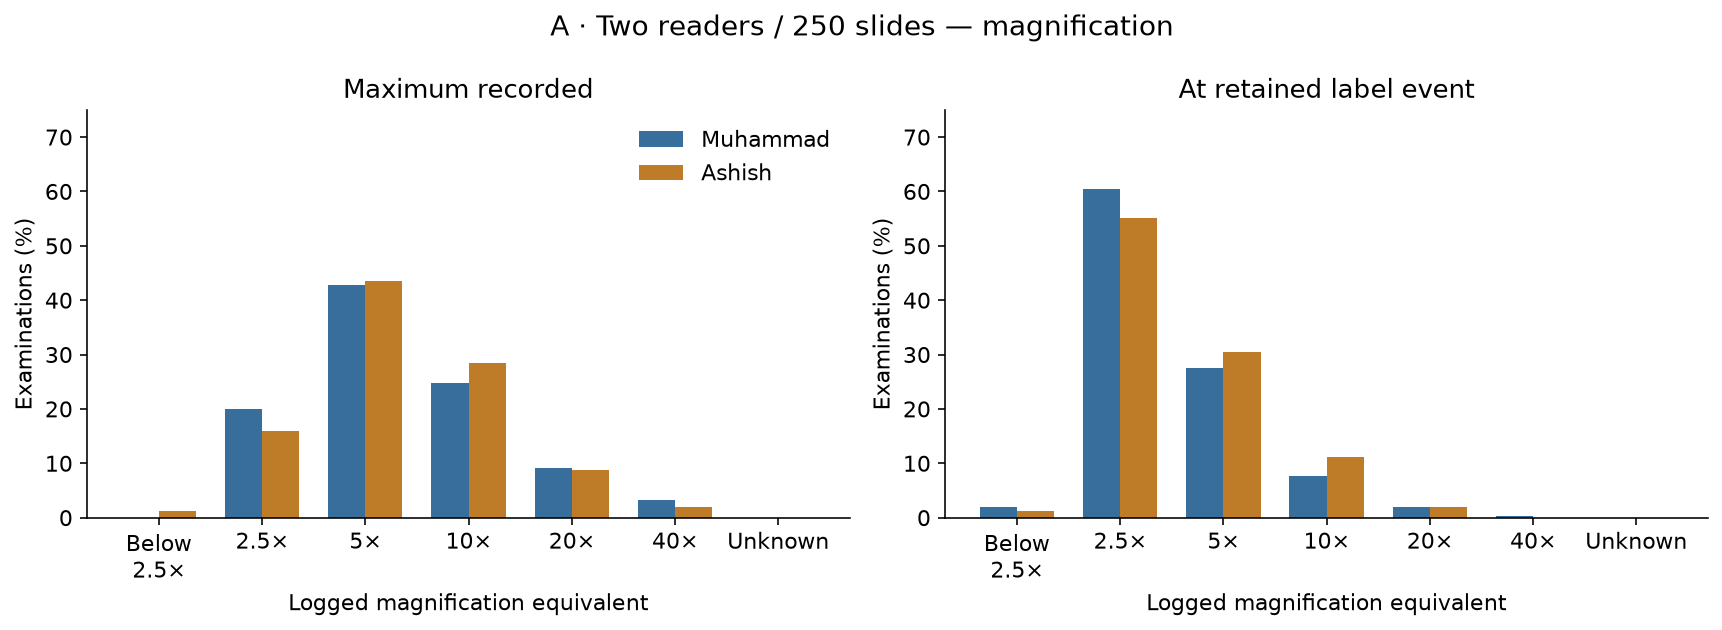

Reader,Maximum ≤5×,Reached ≥10×,Reached ≥20×,Reached 40×,Label at ≤5×
Muhammad Aslam,157/250 (62.8%),93/250 (37.2%),31/250 (12.4%),8/250 (3.2%),225/250 (90.0%)
Ashish Bansal,152/250 (60.8%),98/250 (39.2%),27/250 (10.8%),5/250 (2.0%),217/250 (86.8%)


Reader,<2.5,2.5,5,10,20,40,Unknown
Muhammad Aslam,0,50,107,62,23,8,0
Ashish Bansal,3,40,109,71,22,5,0


Reader,<2.5,2.5,5,10,20,40,Unknown
Muhammad Aslam,5,151,69,19,5,1,0
Ashish Bansal,3,138,76,28,5,0,0


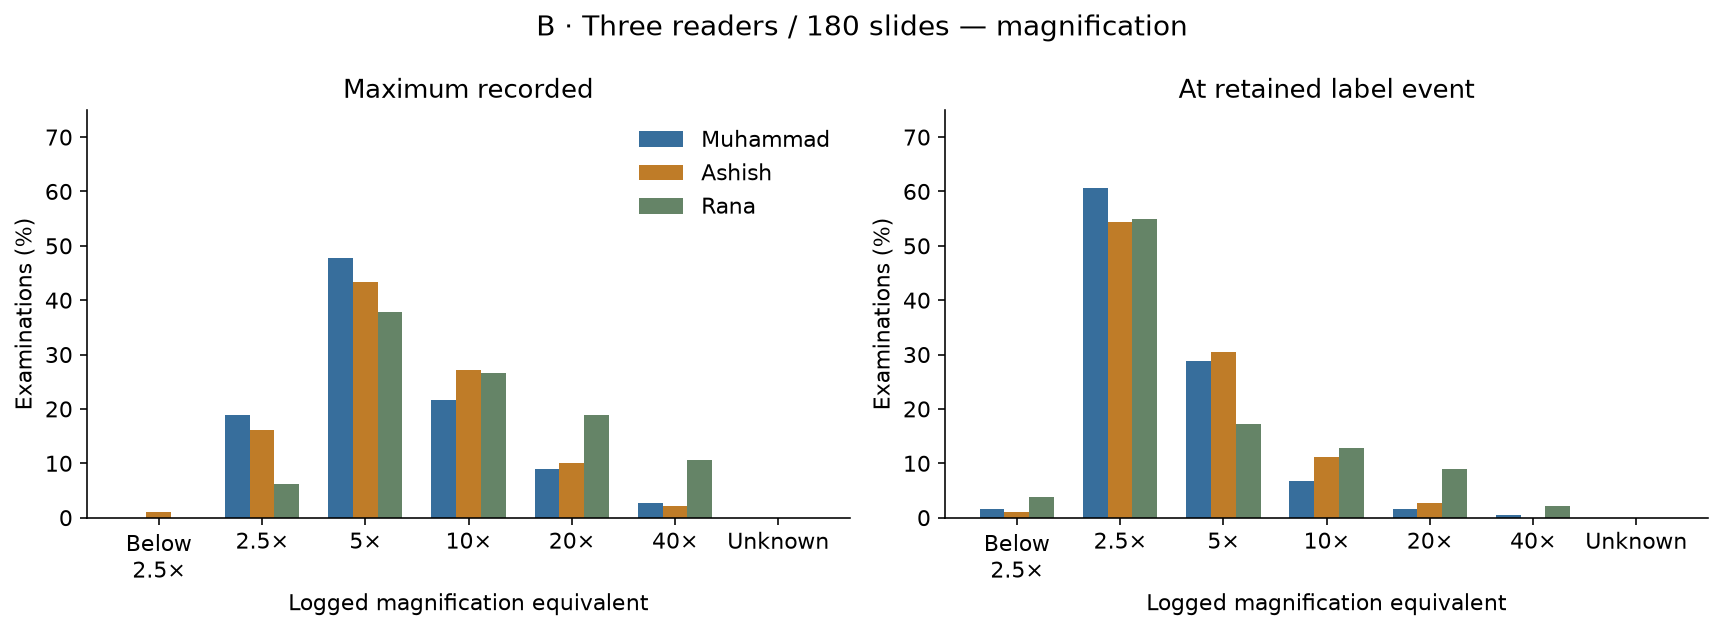

Reader,Maximum ≤5×,Reached ≥10×,Reached ≥20×,Reached 40×,Label at ≤5×
Muhammad Aslam,120/180 (66.7%),60/180 (33.3%),21/180 (11.7%),5/180 (2.8%),164/180 (91.1%)
Ashish Bansal,109/180 (60.6%),71/180 (39.4%),22/180 (12.2%),4/180 (2.2%),155/180 (86.1%)
Iftikhar Rana,79/180 (43.9%),101/180 (56.1%),53/180 (29.4%),19/180 (10.6%),137/180 (76.1%)


Reader,<2.5,2.5,5,10,20,40,Unknown
Muhammad Aslam,0,34,86,39,16,5,0
Ashish Bansal,2,29,78,49,18,4,0
Iftikhar Rana,0,11,68,48,34,19,0


Reader,<2.5,2.5,5,10,20,40,Unknown
Muhammad Aslam,3,109,52,12,3,1,0
Ashish Bansal,2,98,55,20,5,0,0
Iftikhar Rana,7,99,31,23,16,4,0


In [36]:
bh_q3_depth_rows=[]
for bh_key in ["A","B"]:
    bh_readers=cohort_readers[bh_key]
    fig,axes=plt.subplots(1,2,figsize=(12,4.4))
    bh_x=np.arange(len(BH_RUNG_NAMES)); bh_width=.72/len(bh_readers)
    for bh_j,bh_user in enumerate(bh_readers):
        bh_d=bh_reader_frame(bh_key,bh_user)
        for ax,bh_field,bh_title in zip(axes,["max_rung","label_rung"],["Maximum recorded","At retained label event"]):
            bh_counts=bh_d[bh_field].value_counts().reindex(BH_RUNG_NAMES,fill_value=0)
            ax.bar(bh_x+(bh_j-(len(bh_readers)-1)/2)*bh_width,100*bh_counts/len(bh_d),
                   width=bh_width,color=BH_READER_COLOURS[bh_user],label=FIRST_NAMES[bh_user])
            ax.set(xticks=bh_x,xticklabels=["Below\n2.5×","2.5×","5×","10×","20×","40×","Unknown"],
                   xlabel="Logged magnification equivalent",ylabel="Examinations (%)",title=bh_title,ylim=(0,75))
        bh_valid_label=bh_d.label_zoom.gt(0)&bh_d.label_zoom.notna()
        bh_q3_depth_rows.append({"Cohort":bh_key,"Reader":READER_NAMES[bh_user],
            "Maximum ≤5×":ratio_text(int(bh_d.max_zoom.le(5).sum()),len(bh_d)),
            "Reached ≥10×":ratio_text(int(bh_d.max_zoom.ge(10).sum()),len(bh_d)),
            "Reached ≥20×":ratio_text(int(bh_d.max_zoom.ge(20).sum()),len(bh_d)),
            "Reached 40×":ratio_text(int(bh_d.max_zoom.eq(40).sum()),len(bh_d)),
            "Label at ≤5×":ratio_text(int((bh_valid_label&bh_d.label_zoom.le(5)).sum()),int(bh_valid_label.sum()))})
    fig.suptitle(GROUP_NAMES[bh_key]+" — magnification",fontsize=14)
    axes[0].legend(frameon=False)
    fig.tight_layout()
    show_figure(fig)
    show_table(pd.DataFrame([r for r in bh_q3_depth_rows if r["Cohort"]==bh_key]).drop(columns="Cohort"))
    for bh_field,bh_summary_label in [("max_rung","Maximum magnification"),("label_rung","Magnification at label event")]:
        bh_exact_counts=pd.DataFrame([{"Reader":READER_NAMES[u],
            **bh_reader_frame(bh_key,u)[bh_field].value_counts().reindex(BH_RUNG_NAMES,fill_value=0).to_dict()}
            for u in bh_readers])
        display(HTML("<details><summary>Exact slide counts — "+bh_summary_label+"</summary>"+
                     bh_exact_counts.to_html(index=False,border=0)+"</details>"))

### 3.2 How is logged time distributed across magnifications?

Sum retained non-idle intervals at each observed magnification. For the main allocation plot, calculate a percentage **within each examination**, using its known-magnification time, and then average those percentages across slides. Every valid examination receives equal weight.

The supplementary pooled percentage divides all low-resolution seconds by all known-magnification seconds; it gives longer examinations more weight. These answer different questions. Unknown-magnification seconds are excluded from both fractions but are reported separately, not silently called low resolution.

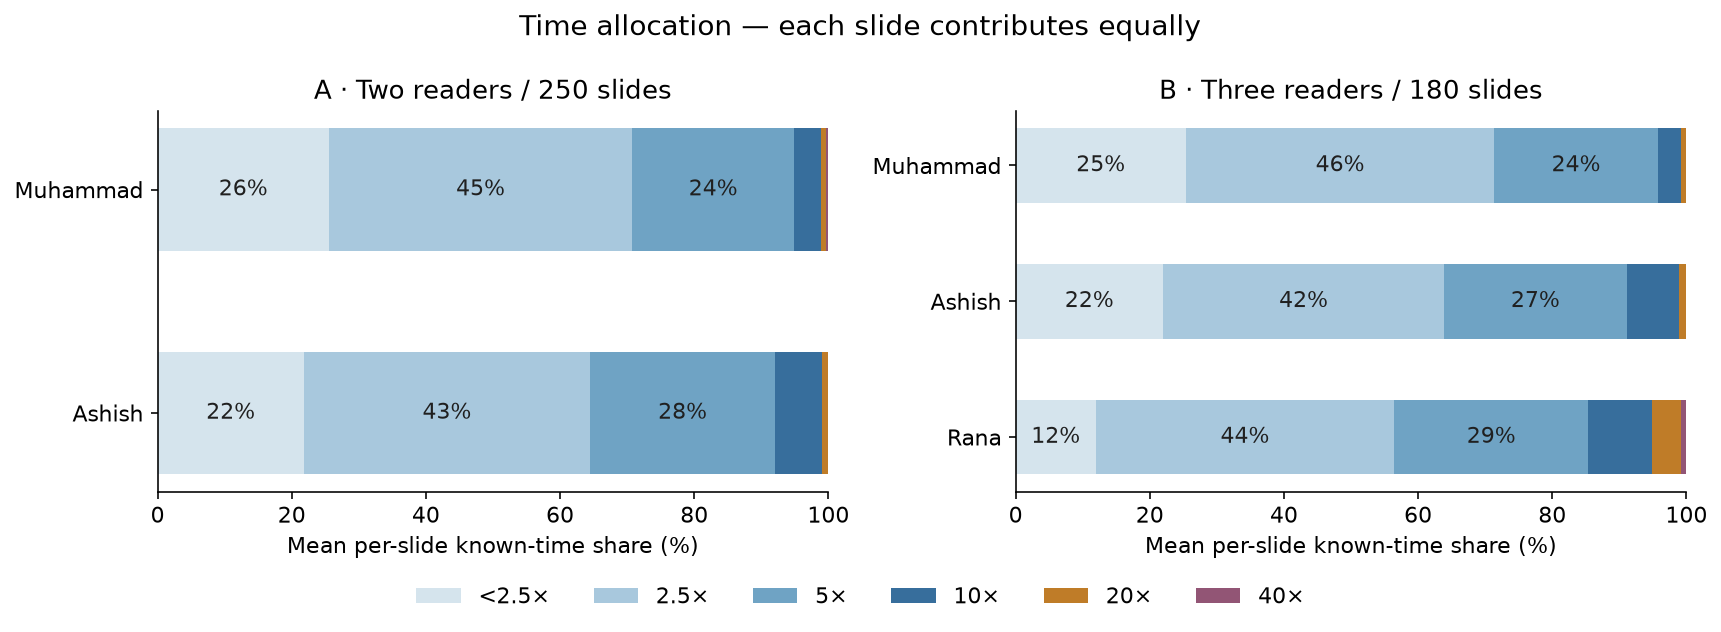

Reader,Valid time fractions,Mean slide fraction ≤5× (%),Median slide fraction ≤5× (%),Pooled seconds ≤5× (%),Unknown zoom seconds
Muhammad Aslam,250,94.9,100.0,90.9,42.0
Ashish Bansal,250,92.1,100.0,88.1,45.0


Reader,Valid time fractions,Mean slide fraction ≤5× (%),Median slide fraction ≤5× (%),Pooled seconds ≤5× (%),Unknown zoom seconds
Muhammad Aslam,180,95.7,100.0,93.0,18.0
Ashish Bansal,180,91.1,100.0,86.2,45.0
Iftikhar Rana,180,85.4,96.3,84.1,30.0


In [37]:
bh_time_rows=[]
bh_rung_colours=["#D5E4ED","#A8C8DD","#6FA3C4","#376E9C","#BF7C28","#925575"]
fig,axes=plt.subplots(1,2,figsize=(12,4.0))
for ax,bh_key in zip(axes,["A","B"]):
    for bh_row,bh_user in enumerate(cohort_readers[bh_key]):
        bh_d=bh_reader_frame(bh_key,bh_user)
        bh_valid=bh_d.known_zoom_s_30.gt(0)
        bh_alloc=np.array([(bh_d.loc[bh_valid,f"time_rung_{j}_30"]/bh_d.loc[bh_valid,"known_zoom_s_30"]).mean()
                           for j in range(6)],dtype=float)
        assert np.isclose(bh_alloc.sum(),1)
        bh_left=0.
        for bh_j,(bh_fraction,bh_colour) in enumerate(zip(bh_alloc,bh_rung_colours)):
            bh_pct=100*bh_fraction
            ax.barh(bh_row,bh_pct,left=bh_left,color=bh_colour,height=.55,
                    label=BH_RUNG_NAMES[bh_j]+"×" if bh_row==0 else None)
            if bh_pct>=10:
                ax.text(bh_left+bh_pct/2,bh_row,f"{bh_pct:.0f}%",ha="center",va="center",
                        color="white" if bh_j in [3,5] else "#202020",zorder=10)
            bh_left+=bh_pct
        bh_known=float(bh_d.known_zoom_s_30.sum())
        bh_low=sum(float(bh_d[f"time_rung_{j}_30"].sum()) for j in [0,1,2])
        bh_time_rows.append({"Cohort":bh_key,"Reader":READER_NAMES[bh_user],"Valid time fractions":int(bh_valid.sum()),
            "Mean slide fraction ≤5× (%)":round(100*bh_d.low_time_fraction_30.mean(),1),
            "Median slide fraction ≤5× (%)":round(100*bh_d.low_time_fraction_30.median(),1),
            "Pooled seconds ≤5× (%)":round(100*bh_low/bh_known,1),
            "Unknown zoom seconds":round(float(bh_d.unknown_zoom_s_30.sum()),1)})
    ax.set(yticks=range(len(cohort_readers[bh_key])),
           yticklabels=[FIRST_NAMES[u] for u in cohort_readers[bh_key]],xlim=(0,100),
           xlabel="Mean per-slide known-time share (%)",title=GROUP_NAMES[bh_key])
    ax.invert_yaxis()
handles,labels=axes[0].get_legend_handles_labels()
fig.legend(handles,labels,loc="lower center",ncol=6,frameon=False,bbox_to_anchor=(.5,-.08))
fig.suptitle("Time allocation — each slide contributes equally",fontsize=14)
fig.tight_layout()
show_figure(fig)
for bh_key in ["A","B"]:
    show_table(pd.DataFrame([r for r in bh_time_rows if r["Cohort"]==bh_key]).drop(columns="Cohort"))

In [38]:
bh_time_quality=[]
for bh_key in ["A","B"]:
    for bh_user in cohort_readers[bh_key]:
        bh_d=bh_reader_frame(bh_key,bh_user)
        bh_time_quality.append({"Cohort":bh_key,"Reader":READER_NAMES[bh_user],
            "Elapsed span sum (s)":int(bh_d.raw_span_s.sum()),
            "Excluded reload gaps (s)":int(bh_d.reload_gap_s.sum()),
            "Logged idle excluded (s)":int(bh_d.idle_s.sum()),
            "Cap removed, 15/30/60 s":"/".join(str(int(bh_d[f"capped_away_s_{c}"].sum())) for c in BH_CAPS),
            "Retained at 30 s cap (s)":int(bh_d.nonidle_s_30.sum()),
            "Zoom-changing intervals (%)":round(100*bh_d.transition_interval_s.sum()/bh_d.nonidle_s_30.sum(),1)})
show_table(pd.DataFrame(bh_time_quality))
print("Idle-marker anomalies (orphan ends / repeated starts / trailing idle):",
      [int(bh_features[c].sum()) for c in ["orphan_idle_end","repeated_idle_start","trailing_idle"]])

Idle-marker anomalies (orphan ends / repeated starts / trailing idle): [0, 0, 0]


Cohort,Reader,Elapsed span sum (s),Excluded reload gaps (s),Logged idle excluded (s),"Cap removed, 15/30/60 s",Retained at 30 s cap (s),Zoom-changing intervals (%)
A,Muhammad Aslam,29099,14,22711,57/0/0,6374,8.3
A,Ashish Bansal,18953,0,10117,75/0/0,8836,5.3
B,Muhammad Aslam,23608,5,19310,9/0/0,4293,8.7
B,Ashish Bansal,15951,0,9388,43/0/0,6563,5.3
B,Iftikhar Rana,9892,3,3386,12/0/0,6503,8.7


In [39]:
bh_lines=[]
for bh_key in ["A","B"]:
    bh_parts=[]
    for bh_user in cohort_readers[bh_key]:
        bh_d=bh_reader_frame(bh_key,bh_user)
        bh_parts.append(f"{FIRST_NAMES[bh_user]} reached at least 20× on "
                       f"{ratio_text(int(bh_d.max_zoom.ge(20).sum()),len(bh_d))}")
    bh_lines.append("**"+GROUP_NAMES[bh_key]+":** "+"; ".join(bh_parts)+".")
display(Markdown("**Observed magnification pattern.**\n\n"+"\n\n".join(bh_lines)+
    "\n\nOn the shared 180 slides, Rana's selected examinations reach the higher rungs more often. "
    "This is a difference in recorded resolution use, not a demonstrated difference in diagnostic quality."))
bh_lower_parts=[]
for bh_user in THREE:
    bh_d=bh_reader_frame("B",bh_user)
    bh_known=bh_d.label_zoom.gt(0)&bh_d.label_zoom.notna()
    bh_lower_parts.append(FIRST_NAMES[bh_user]+": "+ratio_text(int((bh_known&bh_d.label_zoom.lt(bh_d.max_zoom)).sum()),int(bh_known.sum())))
display(Markdown("The label is recorded below **that same examination's own maximum** on: "+
                 "; ".join(bh_lower_parts)+". Lower magnification at labelling does not imply that higher resolution was unused."))

**Observed magnification pattern.**

**A · Two readers / 250 slides:** Muhammad reached at least 20× on 31/250 (12.4%); Ashish reached at least 20× on 27/250 (10.8%).

**B · Three readers / 180 slides:** Muhammad reached at least 20× on 21/180 (11.7%); Ashish reached at least 20× on 22/180 (12.2%); Rana reached at least 20× on 53/180 (29.4%).

On the shared 180 slides, Rana's selected examinations reach the higher rungs more often. This is a difference in recorded resolution use, not a demonstrated difference in diagnostic quality.

The label is recorded below **that same examination's own maximum** on: Muhammad: 96/180 (53.3%); Ashish: 97/180 (53.9%); Rana: 126/180 (70.0%). Lower magnification at labelling does not imply that higher resolution was unused.

### Question 3 — interpretation

Compare readers **within** each cohort. The maximum-magnification distribution answers how deeply the selected examinations went; the label-event distribution answers where the viewport was when the retained label was logged. Time fractions add a duration view but remain dependent on the logging and idle assumptions.

The cap-sensitivity table reports the actual effect rather than assuming that long wall-clock gaps distort retained time. Many long gaps are already excluded by the idle state. Even a stable estimate across caps is not validation of active attention: the app can mark stationary reading idle.

**Discussion checkpoint:** a slide may reach 20× but be labelled at 2.5×. Explain why that is consistent, and why 0 in the log is not treated as overview.

<a id="question-4"></a>

# Question 4 — How do readers navigate, and how much effort do they expend?

**Purpose.** Describe logged navigation and duration, using the same selected examinations and two matched cohorts. Effort is represented by several observable quantities; we do not invent a single score or equate interaction count with cognitive effort.

Report target clicks, pan commands and back/reset commands separately. A left click generates an additional zoom record; summing both would double-count it. Right-click zoom-outs cannot be separated reliably from all generated zoom records here, so these are not complete counts of physical actions.

In [40]:
bh_q4_action_rows=[]
for bh_key in ["A","B"]:
    for bh_user in cohort_readers[bh_key]:
        bh_d=bh_reader_frame(bh_key,bh_user)
        bh_q4_action_rows.append({"Cohort":bh_key,"Reader":READER_NAMES[bh_user],"N":len(bh_d),
            "Clicks: median [P25,P75]":bh_summary(bh_d.n_cell_click),
            "Clicks: mean (SD)":f"{bh_d.n_cell_click.mean():.2f} ({bh_d.n_cell_click.std(ddof=1):.2f})",
            "Click-count variance":round(float(bh_d.n_cell_click.var(ddof=1)),2),
            "Clicks: range":f"{bh_d.n_cell_click.min()}–{bh_d.n_cell_click.max()}",
            "Any pan":ratio_text(int(bh_d.n_arrow_pan.gt(0).sum()),len(bh_d))})
    display(Markdown("**"+GROUP_NAMES[bh_key]+"**"))
    show_table(pd.DataFrame([r for r in bh_q4_action_rows if r["Cohort"]==bh_key]).drop(columns="Cohort"))
    show_table(pd.DataFrame([{"Reader":READER_NAMES[u],
        **{label:int(bh_reader_frame(bh_key,u)[field].sum()) for field,label in [
          ("n_cell_click","Clicks"),("n_arrow_pan","Pan commands"),("n_back_step","Back commands"),
          ("n_reset","Reset commands"),("n_zoom_step","Zoom records (not unique actions)")]}}
        for u in cohort_readers[bh_key]]))

**A · Two readers / 250 slides**

Reader,N,"Clicks: median [P25,P75]",Clicks: mean (SD),Click-count variance,Clicks: range,Any pan
Muhammad Aslam,250,"5.0 [3.0, 7.0]",5.56 (3.64),13.24,1–26,23/250 (9.2%)
Ashish Bansal,250,"5.0 [3.0, 8.0]",5.90 (4.13),17.08,0–33,20/250 (8.0%)


Reader,Clicks,Pan commands,Back commands,Reset commands,Zoom records (not unique actions)
Muhammad Aslam,1391,183,2,0,2871
Ashish Bansal,1476,117,18,2,3012


**B · Three readers / 180 slides**

Reader,N,"Clicks: median [P25,P75]",Clicks: mean (SD),Click-count variance,Clicks: range,Any pan
Muhammad Aslam,180,"5.0 [3.0, 7.0]",5.34 (3.42),11.67,1–20,16/180 (8.9%)
Ashish Bansal,180,"5.0 [3.0, 8.0]",6.19 (4.45),19.83,0–33,14/180 (7.8%)
Iftikhar Rana,180,"8.0 [5.0, 12.0]",9.17 (6.34),40.23,1–40,40/180 (22.2%)


Reader,Clicks,Pan commands,Back commands,Reset commands,Zoom records (not unique actions)
Muhammad Aslam,961,94,0,0,1998
Ashish Bansal,1115,89,18,2,2264
Iftikhar Rana,1651,444,8,4,3429


### 4.1 Duration and action distributions

Median and interquartile range describe the middle of the slide distribution; mean, standard deviation and range expose skew and outliers. Brackets show the 25th and 75th percentiles (P25/P75). In the plots, points are medians and bars span the middle 50% of **slide values**. They are not confidence intervals for the reader.

The elapsed span includes all time between first and retained-label record. The estimated non-idle logged duration removes recorded idle/load gaps and caps unexplained retained intervals as specified above. Click and duration plots use all cohort examinations; valid click-offset counts are listed in the next subsection.

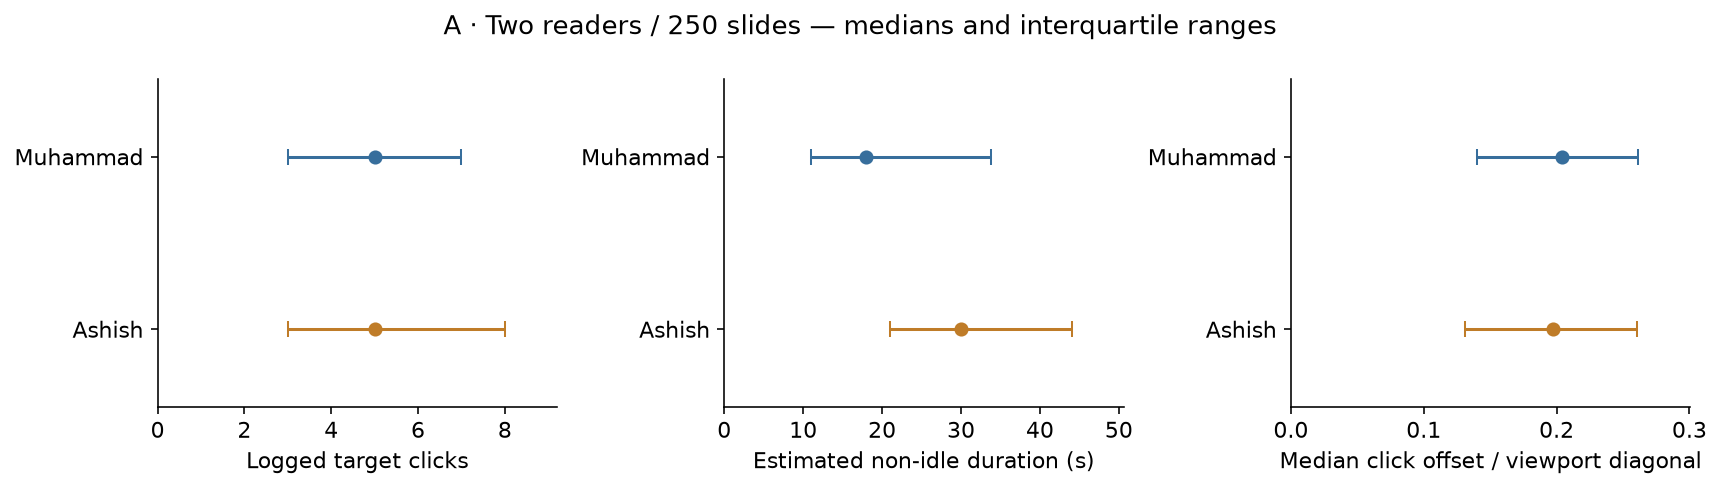

Reader,"Elapsed: median [P25,P75] s","Non-idle: median [P25,P75] s",Non-idle: mean (SD) s,Longest elapsed span (s)
Muhammad Aslam,"18.0 [11.0, 34.0]","18.0 [11.0, 33.8]",25.5 (22.8),13363
Ashish Bansal,"30.0 [21.0, 46.8]","30.0 [21.0, 44.0]",35.3 (22.9),8287


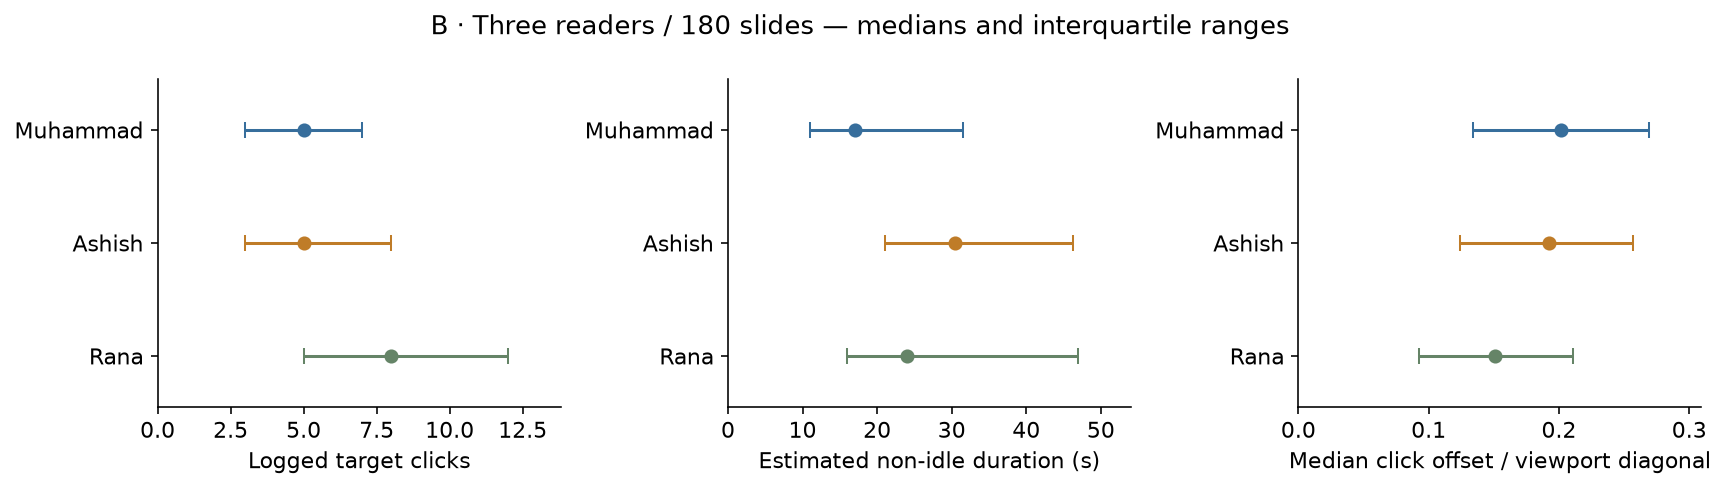

Reader,"Elapsed: median [P25,P75] s","Non-idle: median [P25,P75] s",Non-idle: mean (SD) s,Longest elapsed span (s)
Muhammad Aslam,"17.0 [11.0, 31.8]","17.0 [11.0, 31.5]",23.9 (18.1),13363
Ashish Bansal,"30.5 [21.0, 47.0]","30.5 [21.0, 46.2]",36.5 (25.0),8287
Iftikhar Rana,"24.0 [16.0, 47.0]","24.0 [16.0, 47.0]",36.1 (34.6),604


In [41]:
bh_q4_time_rows=[]
for bh_key in ["A","B"]:
    fig,axes=plt.subplots(1,3,figsize=(12,3.4))
    for ax,bh_metric,bh_label in zip(axes,["n_cell_click","nonidle_s_30","median_click_offset"],
        ["Logged target clicks","Estimated non-idle duration (s)","Median click offset / viewport diagonal"]):
        for bh_row,bh_user in enumerate(cohort_readers[bh_key]):
            bh_values=bh_reader_frame(bh_key,bh_user)[bh_metric].dropna()
            q=bh_values.quantile([.25,.5,.75])
            ax.errorbar(q.loc[.5],bh_row,xerr=[[q.loc[.5]-q.loc[.25]],[q.loc[.75]-q.loc[.5]]],
                        fmt="o",color=BH_READER_COLOURS[bh_user],capsize=4)
        ax.set(yticks=range(len(cohort_readers[bh_key])),
               yticklabels=[FIRST_NAMES[u] for u in cohort_readers[bh_key]],xlabel=bh_label)
        bh_extent=max(float(bh_reader_frame(bh_key,u)[bh_metric].quantile(.75)) for u in cohort_readers[bh_key])
        ax.set_xlim(0,max(bh_extent*1.15,0.01))
        ax.set_ylim(-.45,len(cohort_readers[bh_key])-.55);ax.invert_yaxis()
    fig.suptitle(GROUP_NAMES[bh_key]+" — medians and interquartile ranges",fontsize=13)
    fig.tight_layout();show_figure(fig)
    for bh_user in cohort_readers[bh_key]:
        bh_d=bh_reader_frame(bh_key,bh_user)
        bh_q4_time_rows.append({"Cohort":bh_key,"Reader":READER_NAMES[bh_user],
            "Elapsed: median [P25,P75] s":bh_summary(bh_d.raw_span_s),
            "Non-idle: median [P25,P75] s":bh_summary(bh_d.nonidle_s_30),
            "Non-idle: mean (SD) s":f"{bh_d.nonidle_s_30.mean():.1f} ({bh_d.nonidle_s_30.std(ddof=1):.1f})",
            "Longest elapsed span (s)":int(bh_d.raw_span_s.max())})
    show_table(pd.DataFrame([r for r in bh_q4_time_rows if r["Cohort"]==bh_key]).drop(columns="Cohort"))

### 4.2 Define movement before counting it

**Click offset** measures how far the chosen target is from the currently displayed viewport centre. Divide by that viewport's diagonal so a given value has the same field-of-view interpretation at different scales. It is conditional on at least one geometrically valid click.

**Successive-target jump** measures how far the next selected target is from the previous selected target, divided by the previous click's viewport diagonal. This needs at least two valid consecutive targets within an observed segment. Intervening pans, back steps and resets can affect it; it is not an individual movement command. Fewer targets produce a missing value, not zero.

For a narrow repeat measure, count nonconsecutive returns to the **same click target rounded to one full-resolution pixel**, within a segment. Nearby tissue revisits will be missed. This is not a count of fixations, independent tissue regions or gaze returns.

In [42]:
for bh_key in ["A","B"]:
    display(Markdown("**"+GROUP_NAMES[bh_key]+"**"))
    show_table(pd.DataFrame([{"Reader":READER_NAMES[u],
        "Click offset: median [P25,P75]":bh_summary(bh_reader_frame(bh_key,u).median_click_offset,3),
        "Offset-valid slides":int(bh_reader_frame(bh_key,u).median_click_offset.notna().sum()),
        "Target jump: median [P25,P75]":bh_summary(bh_reader_frame(bh_key,u).median_target_jump,3),
        "Jump-valid slides":int(bh_reader_frame(bh_key,u).median_target_jump.notna().sum()),
        "Slides with exact target return":int(bh_reader_frame(bh_key,u).exact_target_returns.gt(0).sum())}
        for u in cohort_readers[bh_key]]))
    show_table(pd.DataFrame([{"Reader":READER_NAMES[u],
        "Upward observed changes":bh_summary(bh_reader_frame(bh_key,u).upward_changes),
        "Downward observed changes":bh_summary(bh_reader_frame(bh_key,u).downward_changes),
        "Slides with back/reset":int((bh_reader_frame(bh_key,u).n_back_step+bh_reader_frame(bh_key,u).n_reset).gt(0).sum())}
        for u in cohort_readers[bh_key]]))
print("All selected click targets have finite, positive viewport geometry and fall within their recorded viewport.")

All selected click targets have finite, positive viewport geometry and fall within their recorded viewport.


**A · Two readers / 250 slides**

Reader,"Click offset: median [P25,P75]",Offset-valid slides,"Target jump: median [P25,P75]",Jump-valid slides,Slides with exact target return
Muhammad Aslam,"0.204 [0.140, 0.261]",250,"0.154 [0.088, 0.278]",229,0
Ashish Bansal,"0.198 [0.131, 0.260]",247,"0.144 [0.074, 0.281]",227,0


Reader,Upward observed changes,Downward observed changes,Slides with back/reset
Muhammad Aslam,"3.0 [2.0, 6.0]","2.0 [1.0, 5.0]",1
Ashish Bansal,"4.0 [2.0, 5.0]","2.0 [1.0, 5.0]",2


**B · Three readers / 180 slides**

Reader,"Click offset: median [P25,P75]",Offset-valid slides,"Target jump: median [P25,P75]",Jump-valid slides,Slides with exact target return
Muhammad Aslam,"0.202 [0.134, 0.269]",180,"0.154 [0.092, 0.272]",160,0
Ashish Bansal,"0.192 [0.124, 0.257]",178,"0.138 [0.066, 0.261]",164,0
Iftikhar Rana,"0.151 [0.093, 0.211]",180,"0.083 [0.040, 0.149]",175,0


Reader,Upward observed changes,Downward observed changes,Slides with back/reset
Muhammad Aslam,"3.0 [2.0, 5.0]","2.0 [1.0, 5.0]",0
Ashish Bansal,"4.0 [2.0, 6.0]","2.0 [1.0, 5.0]",2
Iftikhar Rana,"6.0 [3.0, 9.0]","4.0 [2.0, 8.2]",3


### 4.3 Follow one shared slide

The example below is chosen mechanically: among shared slides where all three have at least two clicks with known click magnification, no repeated load, no >60 s event gap and an elapsed span at most 180 s, take the slide closest to the median total click count. Ties are resolved by slide ID. This is an illustration of the logging, not proof that its trajectory is typical.

The step trace shows the logged magnification state over elapsed seconds; dots mark pre-navigation click states. Whole-second timestamps and asymmetric zoom logging make transition timing approximate.

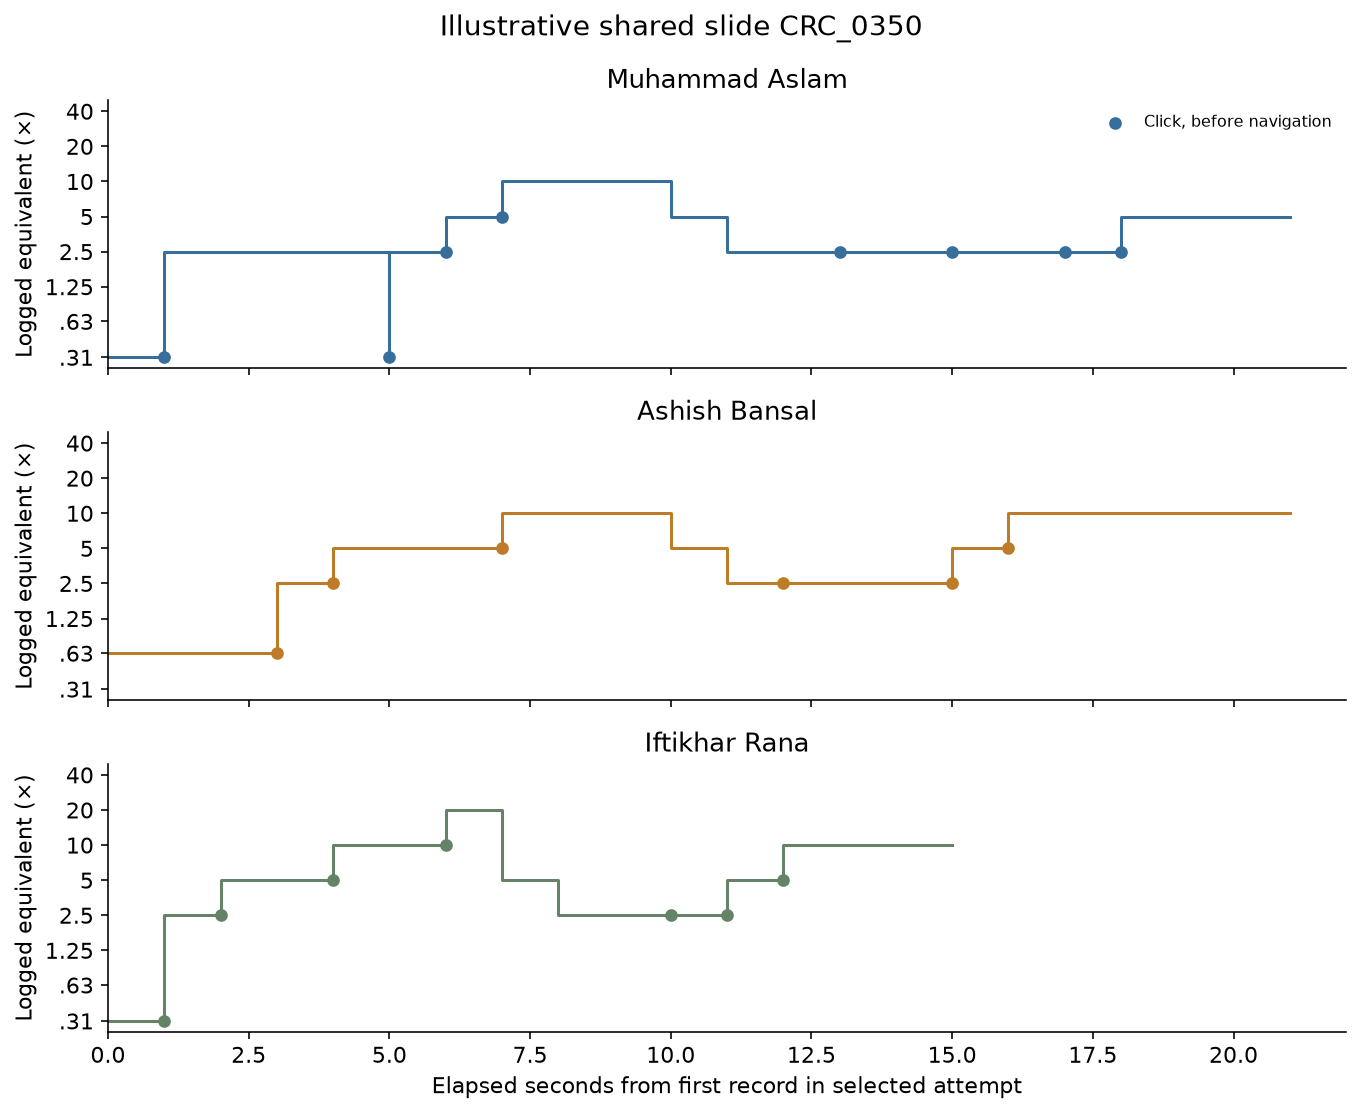

Reader,Slide,Retained label,Click count,Elapsed span (s)
Muhammad Aslam,CRC_0350,high-grade,8,21.0
Ashish Bansal,CRC_0350,high-grade,6,21.0
Iftikhar Rana,CRC_0350,high-grade,7,15.0


In [43]:
bh_b=bh_cohorts["B"]
bh_example_flags=(bh_b.n_cell_click.ge(2)&bh_b.n_click_unknown_zoom.eq(0)&bh_b.n_loads.eq(1)&bh_b.long_gaps.eq(0)&bh_b.raw_span_s.le(180))
bh_eligible=bh_b.assign(eligible=bh_example_flags).groupby("slide_id").eligible.all()
bh_candidates=sorted(bh_eligible[bh_eligible].index)
assert bh_candidates
bh_click_totals=bh_b[bh_b.slide_id.isin(bh_candidates)].groupby("slide_id").n_cell_click.sum().sort_index()
bh_example_slide=(bh_click_totals-bh_click_totals.median()).abs().sort_values(kind="stable").index[0]
fig,axes=plt.subplots(3,1,figsize=(9.5,7.8),sharex=True,sharey=True)
bh_example_table=[]
bh_example_xmax=0.
for ax,bh_user in zip(axes,THREE):
    bh_g=bh_selected[bh_selected.user_id.eq(bh_user)&bh_selected.slide_id.eq(bh_example_slide)].sort_values(["timestamp","source_row"])
    bh_t=(bh_g.timestamp-bh_g.timestamp.iloc[0]).dt.total_seconds()
    bh_z=bh_g.zoom_level.where(bh_g.zoom_level.gt(0))
    ax.step(bh_t,bh_z,where="post",color=BH_READER_COLOURS[bh_user],linewidth=1.5)
    bh_click=bh_g.event.eq("cell_click")&bh_z.notna()
    ax.scatter(bh_t[bh_click],bh_z[bh_click],color=BH_READER_COLOURS[bh_user],s=28,zorder=4,label="Click, before navigation")
    ax.set_yscale("log",base=2)
    ax.set(yticks=[.31,.63,1.25,2.5,5,10,20,40],yticklabels=[".31",".63","1.25","2.5","5","10","20","40"],
           ylabel="Logged equivalent (×)",title=READER_NAMES[bh_user],ylim=(.25,50))
    bh_example_xmax=max(bh_example_xmax,float(bh_t.max()))
    bh_example_table.append({"Reader":READER_NAMES[bh_user],"Slide":bh_example_slide,
        "Retained label":cohorts["B"].loc[cohorts["B"].user_id.eq(bh_user)&cohorts["B"].slide_id.eq(bh_example_slide),"diagnosis"].iloc[0],
        "Click count":int(bh_click.sum()),"Elapsed span (s)":float(bh_t.max())})
axes[-1].set(xlabel="Elapsed seconds from first record in selected attempt",xlim=(0,bh_example_xmax+1))
axes[0].legend(frameon=False,loc="upper right",fontsize=8)
fig.suptitle("Illustrative shared slide "+bh_example_slide,fontsize=14)
fig.tight_layout();show_figure(fig)
show_table(pd.DataFrame(bh_example_table))

### 4.4 Check repeated rows and timing choices

The primary analysis retains all events. Rebuild the features after temporarily retaining only one exact copy of each exported row, then show which slide-level measures change. This is a sensitivity analysis, not an assertion that the removed copies were invalid.

The app constrains navigation: a click recentres and zooms, a pan moves a fixed fraction of the viewport, and polling generates observations without user actions. Observed transition patterns therefore combine human choices and interface design. We do not reuse the older “fixation” clusters or infer a model-design benefit from regular sequences.

In [44]:
bh_diff=bh_features.merge(bh_dedup_features,on=["user_id","slide_id"],suffixes=("_raw","_dedup"),validate="one_to_one")
bh_sensitivity_metrics=["max_zoom","label_zoom","n_cell_click","n_arrow_pan","nonidle_s_30",
    "low_click_fraction","median_click_offset","median_target_jump","exact_target_returns"]
bh_sensitivity_changes=[]
for bh_metric in bh_sensitivity_metrics:
    bh_x=bh_diff[bh_metric+"_raw"].to_numpy(dtype=float);bh_y=bh_diff[bh_metric+"_dedup"].to_numpy(dtype=float)
    bh_changed=~np.isclose(bh_x,bh_y,equal_nan=True,atol=1e-12,rtol=1e-12)
    bh_sensitivity_changes.append({"Measure":bh_metric,"Changed reader-slide records":int(bh_changed.sum())})
show_table(pd.DataFrame(bh_sensitivity_changes))
show_table(pd.DataFrame([{"Reader":READER_NAMES[u],
    **{f"Median non-idle at {cap}s cap":float(bh_features.loc[bh_features.user_id.eq(u),f"nonidle_s_{cap}"].median()) for cap in BH_CAPS}}
    for u in THREE]))

Measure,Changed reader-slide records
max_zoom,0
label_zoom,0
n_cell_click,1
n_arrow_pan,0
nonidle_s_30,0
low_click_fraction,1
median_click_offset,1
median_target_jump,1
exact_target_returns,0


Reader,Median non-idle at 15s cap,Median non-idle at 30s cap,Median non-idle at 60s cap
Muhammad Aslam,18.0,18.0,18.0
Ashish Bansal,30.0,30.0,30.0
Iftikhar Rana,24.0,24.0,24.0


In [45]:
bh_lines=[]
for bh_key in ["A","B"]:
    bh_parts=[]
    for bh_user in cohort_readers[bh_key]:
        bh_d=bh_reader_frame(bh_key,bh_user)
        bh_parts.append(f"{FIRST_NAMES[bh_user]}: median {bh_d.n_cell_click.median():g} clicks and "
                       f"{bh_d.nonidle_s_30.median():g} s estimated non-idle logged duration")
    bh_lines.append("**"+GROUP_NAMES[bh_key]+":** "+"; ".join(bh_parts)+".")
display(Markdown("**Observed effort pattern.**\n\n"+"\n\n".join(bh_lines)+
    "\n\nRana uses more target clicks on the shared cohort, while his median logged duration lies between "
    "Muhammad's and Ashish's. Action count, zoom depth and duration therefore should not be treated as interchangeable effort measures."))

**Observed effort pattern.**

**A · Two readers / 250 slides:** Muhammad: median 5 clicks and 18 s estimated non-idle logged duration; Ashish: median 5 clicks and 30 s estimated non-idle logged duration.

**B · Three readers / 180 slides:** Muhammad: median 5 clicks and 17 s estimated non-idle logged duration; Ashish: median 5 clicks and 30.5 s estimated non-idle logged duration; Rana: median 8 clicks and 24 s estimated non-idle logged duration.

Rana uses more target clicks on the shared cohort, while his median logged duration lies between Muhammad's and Ashish's. Action count, zoom depth and duration therefore should not be treated as interchangeable effort measures.

### Question 4 — interpretation

Compare the per-reader distributions within A and B, keeping click counts, pan use, recorded duration and normalized movement distinct. More clicks or deeper magnification do not necessarily imply longer duration, more cognitive effort, more accurate diagnosis or a superior strategy.

The same-row click offset is the main spatial action measure; the successive-target measure is supplementary. Exact target returns are a deliberately narrow lower-bound description of repeated coordinates. Displayed-region overlap is examined in Question 7; these counts do not establish tissue attention.

<a id="question-5"></a>

# Question 5 — Do the same slides elicit similar behaviour across readers?

**Purpose.** Question 3–4 can show different overall habits. This question asks whether an image that receives relatively more clicks, higher-resolution viewing, longer logged duration or larger target offsets from one reader also tends to receive more from another.

Use one feature value per reader and slide. For **each metric**, take the valid-slide intersection across **all readers in that cohort**, then calculate each pair on that same intersection. Cohort B pairs therefore share the same denominator within a metric. Missing click/jump fractions are excluded explicitly, not replaced with zero. Different metrics can have different valid sets.

### 5.1 Rank consistency and absolute differences answer different questions

We use **Spearman's rank correlation**: rank each reader's slide values (tied values get their average rank), then correlate those ranks. Positive values mean relatively high values tend to occur on the same slides. A coefficient near zero need not mean the overall habits differ; a ceiling such as many 100%-low-resolution examinations can leave little rank variation. A constant input has undefined correlation.

Correlation does not measure equality. A reader could systematically make more clicks on every slide and still have perfect rank correlation. We therefore also show **paired differences: second reader minus first reader**, and their interquartile ranges. For fractions, differences are in percentage points.

All correlations are exploratory descriptive summaries. We do not report asymptotic p-values, population confidence intervals or interpret small differences between correlations as proven effects. [Spearman definition and limitations](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html).

The low-resolution click fraction describes the magnification **before** each click. It is not the fraction of tissue viewed at low resolution or the fraction of clicks that end at low resolution.

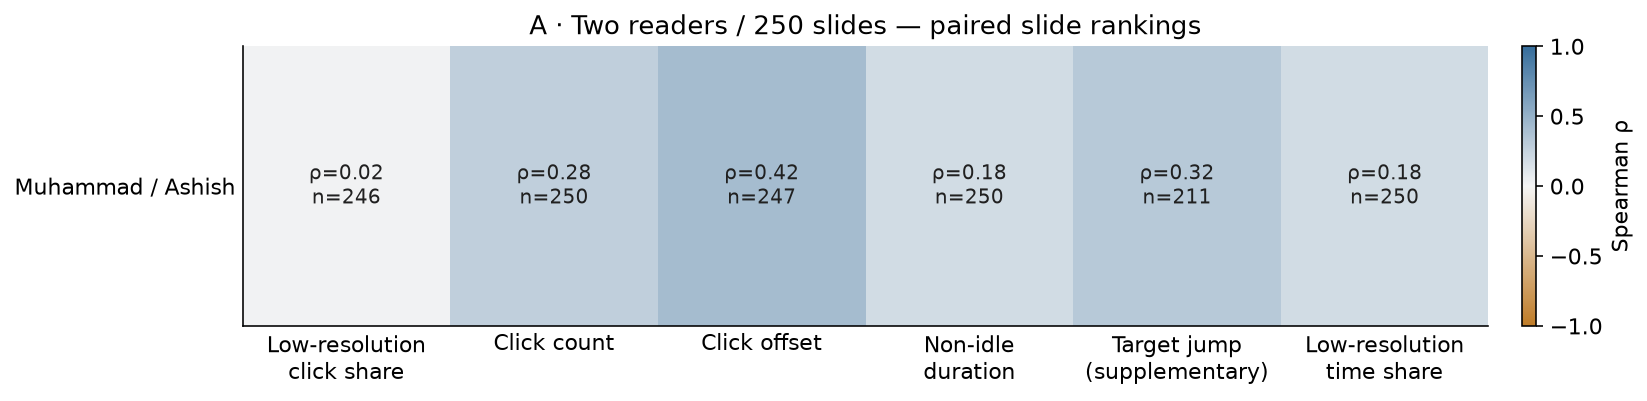

Measure,pair,n,excluded,ρ,"Paired difference: median [P25,P75]",unit
Low-resolution click share,Muhammad / Ashish,246,4,0.018,"0.000 [0.000, 0.000]",percentage points
Click count,Muhammad / Ashish,250,0,0.279,"0.000 [-2.750, 3.000]",clicks
Click offset,Muhammad / Ashish,247,3,0.417,"-0.006 [-0.052, 0.034]",viewport diagonals
Non-idle duration,Muhammad / Ashish,250,0,0.183,"9.500 [-3.000, 23.750]",seconds
Target jump (supplementary),Muhammad / Ashish,211,39,0.321,"0.000 [-0.086, 0.097]",preceding viewport diagonals
Low-resolution time share,Muhammad / Ashish,250,0,0.183,"0.000 [-5.816, 0.000]",percentage points


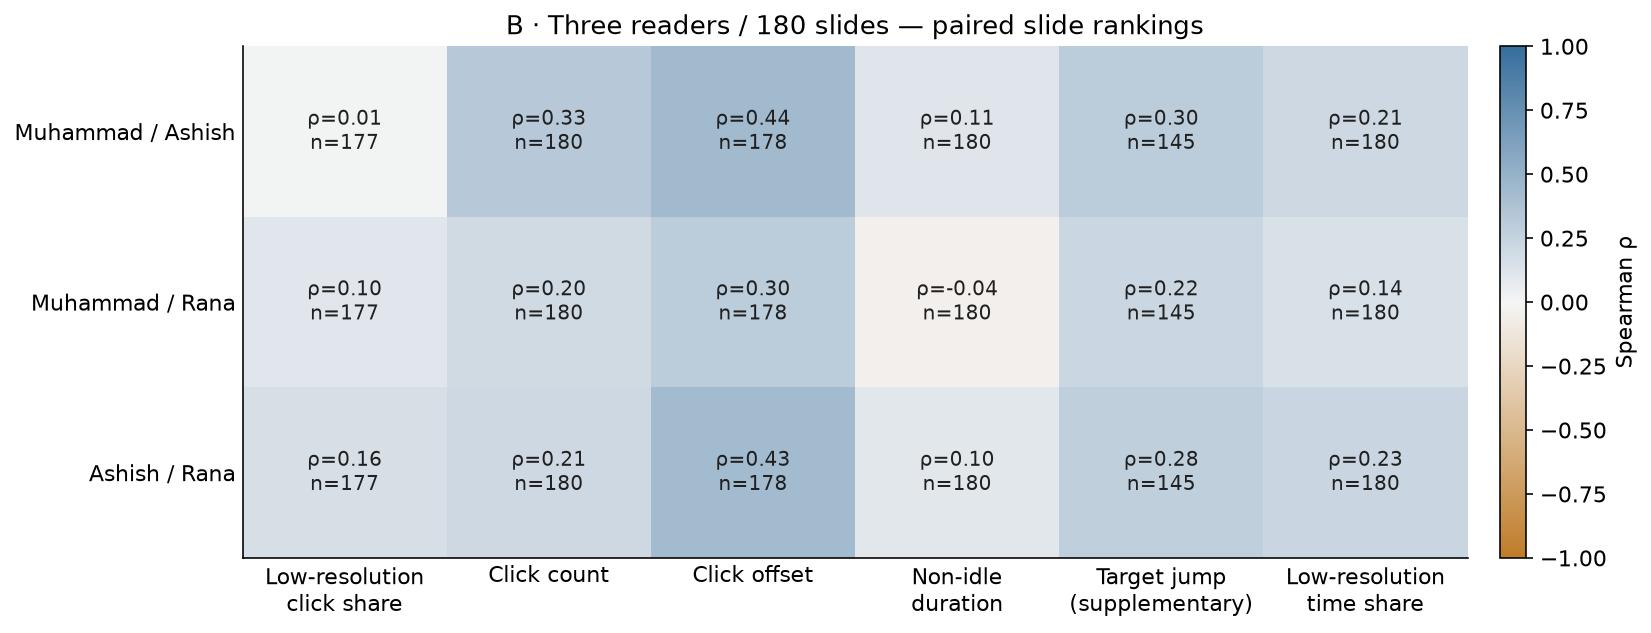

Measure,pair,n,excluded,ρ,"Paired difference: median [P25,P75]",unit
Low-resolution click share,Muhammad / Ashish,177,3,0.014,"0.000 [0.000, 0.000]",percentage points
Low-resolution click share,Muhammad / Rana,177,3,0.103,"0.000 [-6.250, 0.000]",percentage points
Low-resolution click share,Ashish / Rana,177,3,0.157,"0.000 [-7.143, 0.000]",percentage points
Click count,Muhammad / Ashish,180,0,0.326,"0.000 [-2.000, 4.000]",clicks
Click count,Muhammad / Rana,180,0,0.203,"3.000 [-1.000, 7.000]",clicks
Click count,Ashish / Rana,180,0,0.207,"2.000 [-1.000, 7.000]",clicks
Click offset,Muhammad / Ashish,178,2,0.436,"-0.009 [-0.058, 0.027]",viewport diagonals
Click offset,Muhammad / Rana,178,2,0.299,"-0.030 [-0.099, 0.013]",viewport diagonals
Click offset,Ashish / Rana,178,2,0.428,"-0.021 [-0.079, 0.017]",viewport diagonals
Non-idle duration,Muhammad / Ashish,180,0,0.113,"11.000 [-2.000, 25.250]",seconds


In [46]:
BH_Q5_METRICS={
    "low_click_fraction":("Low-resolution\nclick share","percentage points",100.),
    "n_cell_click":("Click count","clicks",1.),
    "median_click_offset":("Click offset","viewport diagonals",1.),
    "nonidle_s_30":("Non-idle\nduration","seconds",1.),
    "median_target_jump":("Target jump\n(supplementary)","preceding viewport diagonals",1.),
    "low_time_fraction_30":("Low-resolution\ntime share","percentage points",100.)}
bh_q5_rows=[]
bh_q5_wides={}
for bh_key in ["A","B"]:
    for bh_metric,(bh_label,bh_unit,bh_scale) in BH_Q5_METRICS.items():
        bh_w=bh_metric_wide(bh_key,bh_metric)
        bh_q5_wides[(bh_key,bh_metric)]=bh_w
        for bh_first,bh_second in combinations(cohort_readers[bh_key],2):
            bh_delta=(bh_w[bh_second]-bh_w[bh_first])*bh_scale
            bh_q5_rows.append({"cohort":bh_key,"metric":bh_metric,"pair":FIRST_NAMES[bh_first]+" / "+FIRST_NAMES[bh_second],
                "first":bh_first,"second":bh_second,"n":len(bh_w),"excluded":len(cohort_ids[bh_key])-len(bh_w),
                "rho":bh_spearman(bh_w[bh_first],bh_w[bh_second]),
                "median_delta":float(bh_delta.median()),"q25_delta":float(bh_delta.quantile(.25)),
                "q75_delta":float(bh_delta.quantile(.75)),"mean_absolute_delta":float(bh_delta.abs().mean()),"unit":bh_unit})
bh_q5=pd.DataFrame(bh_q5_rows)
from matplotlib.colors import LinearSegmentedColormap
bh_rho_cmap=LinearSegmentedColormap.from_list("behaviour-rho",["#BF7C28","#F5F5F5","#376E9C"])
for bh_key in ["A","B"]:
    bh_pairs=list(dict.fromkeys(bh_q5.loc[bh_q5.cohort.eq(bh_key),"pair"]))
    bh_rho=bh_q5[bh_q5.cohort.eq(bh_key)].pivot(index="pair",columns="metric",values="rho").reindex(index=bh_pairs,columns=list(BH_Q5_METRICS))
    bh_ns=bh_q5[bh_q5.cohort.eq(bh_key)].pivot(index="pair",columns="metric",values="n").reindex(index=bh_pairs,columns=list(BH_Q5_METRICS))
    fig,ax=plt.subplots(figsize=(11.5,2.9 if bh_key=="A" else 4.5))
    im=ax.imshow(bh_rho.to_numpy(),vmin=-1,vmax=1,cmap=bh_rho_cmap,aspect="auto")
    for i in range(len(bh_pairs)):
        for j in range(len(BH_Q5_METRICS)):
            value=bh_rho.iloc[i,j]
            label=f"ρ={value:.2f}\nn={int(bh_ns.iloc[i,j])}" if np.isfinite(value) else f"Undefined\nn={int(bh_ns.iloc[i,j])}"
            ax.text(j,i,label,ha="center",va="center",fontsize=10,color="#202020",zorder=10)
    ax.set(xticks=range(len(BH_Q5_METRICS)),xticklabels=[x[0] for x in BH_Q5_METRICS.values()],
           yticks=range(len(bh_pairs)),yticklabels=bh_pairs,title=GROUP_NAMES[bh_key]+" — paired slide rankings")
    ax.tick_params(length=0)
    fig.colorbar(im,ax=ax,label="Spearman ρ",fraction=.035,pad=.025)
    fig.tight_layout();show_figure(fig)
    bh_table=bh_q5[bh_q5.cohort.eq(bh_key)].copy()
    bh_table["Measure"]=bh_table.metric.map(lambda x:BH_Q5_METRICS[x][0].replace("\n"," "))
    bh_table["ρ"]=bh_table.rho.round(3)
    bh_table["Paired difference: median [P25,P75]"]=bh_table.apply(lambda r:f"{r.median_delta:.3f} [{r.q25_delta:.3f}, {r.q75_delta:.3f}]",axis=1)
    display(HTML("<details><summary>Inspect paired differences, units and excluded counts — "+escape(GROUP_NAMES[bh_key])+"</summary>"+
        bh_table[["Measure","pair","n","excluded","ρ","Paired difference: median [P25,P75]","unit"]].to_html(index=False,border=0)+"</details>"))

### 5.2 Inspect the relationship rather than only the coefficient

For a concrete view, plot Muhammad against Ashish on the common three-reader subset for each displayed measure. The diagonal indicates equal values. We use two measures with different behaviour: low-resolution click proportion and click offset. Overlapping identical points are not jittered; an annotation records large piles of identical observations.

This illustration uses the original reader pair chosen in advance, rather than selecting whichever pair has the strongest correlation. All pairs remain in the full table above.

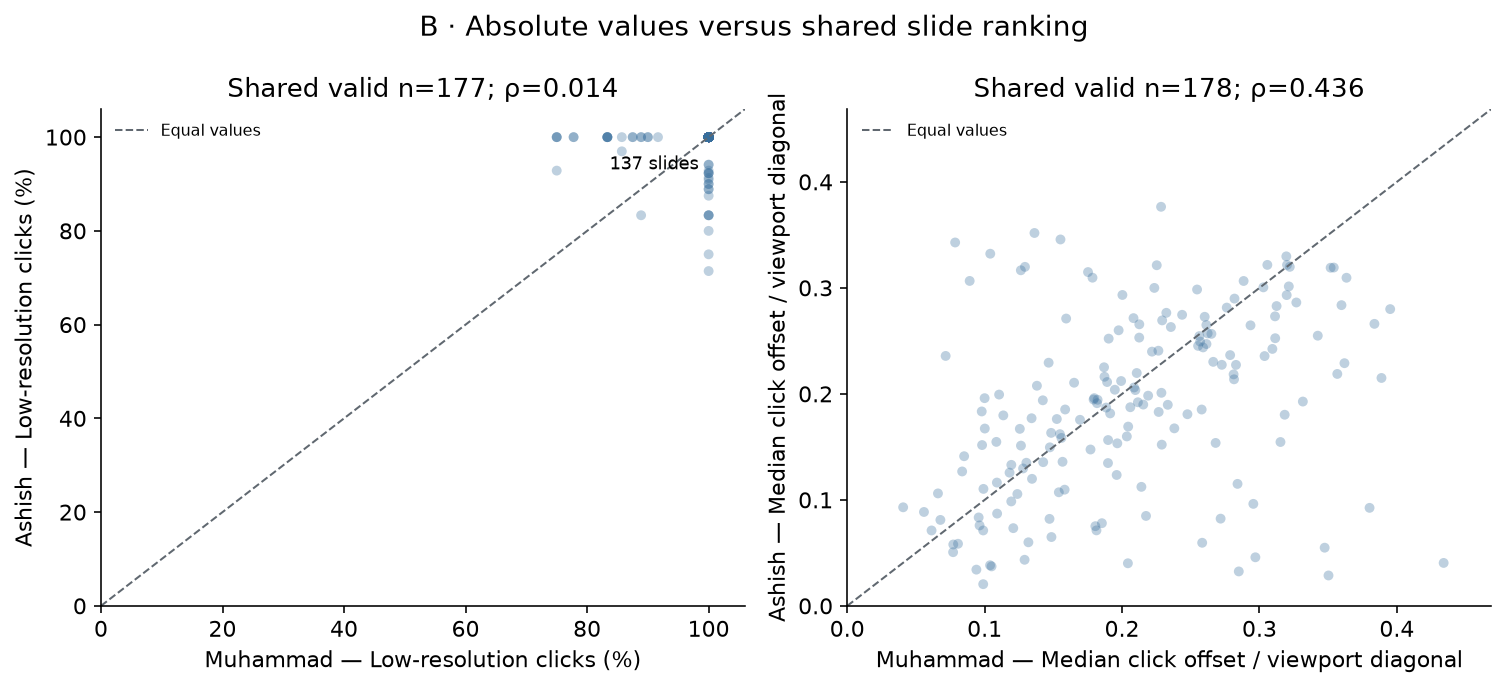

Cohort,Pair,Both use only ≤5× clicks,Mean absolute difference (pp)
A,Muhammad / Ashish,192/246 (78.0%),3.3
B,Muhammad / Ashish,137/177 (77.4%),3.2
B,Muhammad / Rana,112/177 (63.3%),6.3
B,Ashish / Rana,112/177 (63.3%),5.9


In [47]:
fig,axes=plt.subplots(1,2,figsize=(10.5,4.8))
for ax,bh_metric,bh_scale,bh_label in zip(axes,["low_click_fraction","median_click_offset"],[100,1],
    ["Low-resolution clicks (%)","Median click offset / viewport diagonal"]):
    bh_w=bh_q5_wides[("B",bh_metric)]
    bh_x=bh_w[TWO[0]]*bh_scale;bh_y=bh_w[TWO[1]]*bh_scale
    ax.scatter(bh_x,bh_y,s=24,alpha=.32,color="#376E9C",edgecolors="none")
    bh_upper=max(float(bh_x.max()),float(bh_y.max()))*1.08
    if bh_metric=="low_click_fraction":bh_upper=106
    ax.plot([0,bh_upper],[0,bh_upper],color="#606870",linestyle="--",linewidth=1,label="Equal values")
    ax.set(xlim=(0,bh_upper),ylim=(0,bh_upper),xlabel="Muhammad — "+bh_label,
           ylabel="Ashish — "+bh_label,
           title=f"Shared valid n={len(bh_w)}; ρ={bh_spearman(bh_x,bh_y):.3f}")
    bh_piles=pd.DataFrame({"x":bh_x,"y":bh_y}).value_counts().reset_index(name="count")
    for _,r in bh_piles[bh_piles["count"].ge(10)].iterrows():
        ax.annotate(f"{int(r['count'])} slides",(r.x,r.y),xytext=(-5,-16),textcoords="offset points",ha="right",fontsize=9)
    ax.legend(frameon=False,loc="upper left",fontsize=8)
fig.suptitle("B · Absolute values versus shared slide ranking",fontsize=14)
fig.tight_layout();show_figure(fig)
bh_ceiling=[]
for bh_key in ["A","B"]:
    bh_w=bh_q5_wides[(bh_key,"low_click_fraction")]
    for bh_a,bh_b_user in combinations(cohort_readers[bh_key],2):
        bh_ceiling.append({"Cohort":bh_key,"Pair":FIRST_NAMES[bh_a]+" / "+FIRST_NAMES[bh_b_user],
            "Both use only ≤5× clicks":ratio_text(int((bh_w[bh_a].eq(1)&bh_w[bh_b_user].eq(1)).sum()),len(bh_w)),
            "Mean absolute difference (pp)":round(float((bh_w[bh_b_user]-bh_w[bh_a]).abs().mean()*100),1)})
show_table(pd.DataFrame(bh_ceiling))

### 5.3 Does the conclusion depend on the measurement choice?

Compare low-resolution click ranks using thresholds ≤5× and ≤2.5× on the same valid-slide sets. These thresholds pose different questions, so report both without choosing the more favourable coefficient after seeing it.

Also recompute duration/time-share correlations under the 15/30/60 s caps, and compare exact-row deduplication using the common complete observations shared by both versions. Stable values support robustness to that specific processing choice, not validity of gaze or active-time interpretations.

In [48]:
bh_threshold_rows=[];bh_cap_rows=[];bh_dedup_rows=[]
for bh_key in ["A","B"]:
    bh_low5=bh_metric_wide(bh_key,"low_click_fraction")
    bh_low25=bh_metric_wide(bh_key,"low_click_fraction_2_5").reindex(bh_low5.index)
    assert not bh_low25.isna().any().any()
    for bh_a,bh_b_user in combinations(cohort_readers[bh_key],2):
        bh_pair=FIRST_NAMES[bh_a]+" / "+FIRST_NAMES[bh_b_user]
        bh_threshold_rows.append({"Cohort":bh_key,"Pair":bh_pair,"n":len(bh_low5),
            "ρ at ≤5×":round(bh_spearman(bh_low5[bh_a],bh_low5[bh_b_user]),3),
            "ρ at ≤2.5×":round(bh_spearman(bh_low25[bh_a],bh_low25[bh_b_user]),3)})
        for bh_family,bh_name in [("nonidle_s_","Duration"),("low_time_fraction_","Low-resolution time share")]:
            bh_wides={c:bh_metric_wide(bh_key,bh_family+str(c)) for c in BH_CAPS}
            bh_ids=sorted(set.intersection(*(set(w.index) for w in bh_wides.values())))
            bh_cap_rows.append({"Cohort":bh_key,"Pair":bh_pair,"Measure":bh_name,"n":len(bh_ids),
                **{f"ρ cap {c}s":round(bh_spearman(w.loc[bh_ids,bh_a],w.loc[bh_ids,bh_b_user]),3) for c,w in bh_wides.items()}})
    for bh_metric in BH_Q5_METRICS:
        bh_primary=bh_metric_wide(bh_key,bh_metric)
        bh_sens=bh_metric_wide(bh_key,bh_metric,bh_dedup_features)
        bh_ids=sorted(set(bh_primary.index)&set(bh_sens.index))
        for bh_a,bh_b_user in combinations(cohort_readers[bh_key],2):
            bh_r1=bh_spearman(bh_primary.loc[bh_ids,bh_a],bh_primary.loc[bh_ids,bh_b_user])
            bh_r2=bh_spearman(bh_sens.loc[bh_ids,bh_a],bh_sens.loc[bh_ids,bh_b_user])
            bh_dedup_rows.append({"cohort":bh_key,"metric":bh_metric,"pair":FIRST_NAMES[bh_a]+" / "+FIRST_NAMES[bh_b_user],
                                 "n":len(bh_ids),"primary_rho":bh_r1,"dedup_rho":bh_r2,"delta_rho":bh_r2-bh_r1})
show_table(pd.DataFrame(bh_threshold_rows))
show_table(pd.DataFrame(bh_cap_rows))
bh_dedup_summary=pd.DataFrame(bh_dedup_rows).groupby("cohort").delta_rho.agg(
    maximum_absolute_change=lambda x:float(x.abs().max())).reset_index()
show_table(bh_dedup_summary)

Cohort,Pair,n,ρ at ≤5×,ρ at ≤2.5×
A,Muhammad / Ashish,246,0.018,0.169
B,Muhammad / Ashish,177,0.014,0.162
B,Muhammad / Rana,177,0.103,0.091
B,Ashish / Rana,177,0.157,0.213


Cohort,Pair,Measure,n,ρ cap 15s,ρ cap 30s,ρ cap 60s
A,Muhammad / Ashish,Duration,250,0.185,0.183,0.183
A,Muhammad / Ashish,Low-resolution time share,250,0.183,0.183,0.183
B,Muhammad / Ashish,Duration,180,0.109,0.113,0.113
B,Muhammad / Ashish,Low-resolution time share,180,0.205,0.206,0.206
B,Muhammad / Rana,Duration,180,-0.041,-0.041,-0.041
B,Muhammad / Rana,Low-resolution time share,180,0.144,0.143,0.143
B,Ashish / Rana,Duration,180,0.101,0.100,0.100
B,Ashish / Rana,Low-resolution time share,180,0.231,0.232,0.232


cohort,maximum_absolute_change
A,0.000000
B,0.001433


In [49]:
bh_a_offset=bh_q5.loc[(bh_q5.cohort=="A")&(bh_q5.metric=="median_click_offset"),"rho"].iloc[0]
bh_b_offset=bh_q5.loc[(bh_q5.cohort=="B")&(bh_q5.metric=="median_click_offset"),"rho"]
bh_b_clicks=bh_q5.loc[(bh_q5.cohort=="B")&(bh_q5.metric=="n_cell_click"),"rho"]
bh_b_times=bh_q5.loc[(bh_q5.cohort=="B")&(bh_q5.metric=="nonidle_s_30"),"rho"]
bh_low_example=bh_q5_wides[("B","low_click_fraction")]
bh_both_low=int((bh_low_example[TWO[0]].eq(1)&bh_low_example[TWO[1]].eq(1)).sum())
bh_low_rho=bh_spearman(bh_low_example[TWO[0]],bh_low_example[TWO[1]])
display(Markdown(f"**Observed slide-ranking pattern.** Muhammad/Ashish click-offset correlation is "
    f"**ρ={bh_a_offset:.3f}** in A. Across the three pairs in B, click-offset correlations range from "
    f"**{bh_b_offset.min():.3f} to {bh_b_offset.max():.3f}**, and click-count correlations from "
    f"**{bh_b_clicks.min():.3f} to {bh_b_clicks.max():.3f}**. There is some shared ordering of slides under these measures.\n\n"
    f"B's duration correlations range from **{bh_b_times.min():.3f} to {bh_b_times.max():.3f}**, providing little "
    "evidence of similar duration rankings in this cohort.\n\n"
    f"For Muhammad/Ashish, **{bh_both_low}/{len(bh_low_example)}** common valid slides have all clicks at ≤5× for both, "
    f"yet low-resolution-share rank correlation is **ρ={bh_low_rho:.3f}**. The ceiling leaves little rank variation: "
    "similar overall low-resolution use does not entail matching slide-by-slide rankings."))

**Observed slide-ranking pattern.** Muhammad/Ashish click-offset correlation is **ρ=0.417** in A. Across the three pairs in B, click-offset correlations range from **0.299 to 0.436**, and click-count correlations from **0.203 to 0.326**. There is some shared ordering of slides under these measures.

B's duration correlations range from **-0.041 to 0.113**, providing little evidence of similar duration rankings in this cohort.

For Muhammad/Ashish, **137/177** common valid slides have all clicks at ≤5× for both, yet low-resolution-share rank correlation is **ρ=0.014**. The ceiling leaves little rank variation: similar overall low-resolution use does not entail matching slide-by-slide rankings.

### Question 5 — interpretation and limits

Read the result as a pattern across slides, not a reader-ranking exercise. Positive click-offset or click-count correlations indicate some shared ordering of images under those measures. They do not mean identical movements or effort. Low-resolution fractions can share a high ceiling and identical medians while showing little slide-ranking correlation.

Available observations differ by metric. For example, an examination with no clicks cannot provide a click proportion; one click can provide an offset but no successive-target jump. These are missing measurements, not zero effort or zero movement. The common-set rule keeps each cohort's pairs comparable within that metric.

Image geometry, viewer controls, case selection and measurement error can contribute to correlations. Patient grouping remains unavailable. The analyses are exploratory and do not establish causes, population reliability, spatial overlap or benefit to a trained model.

**Discussion checkpoint:** explain how Rana can make more clicks overall while still showing positive click-count correlation with another reader, and why near-zero low-resolution rank correlation is compatible with both often using low resolution.

In [50]:
for bh_key in ["A","B"]:
    for bh_metric in BH_Q5_METRICS:
        bh_rows=bh_q5[(bh_q5.cohort==bh_key)&(bh_q5.metric==bh_metric)]
        assert bh_rows.n.nunique()==1
        assert int(bh_rows.n.iloc[0])==len(bh_q5_wides[(bh_key,bh_metric)])
        assert bh_rows.rho.dropna().between(-1,1).all()
for cap in BH_CAPS:
    assert np.allclose(bh_features[f"nonidle_s_{cap}"],bh_features[f"known_zoom_s_{cap}"]+bh_features[f"unknown_zoom_s_{cap}"])
    assert bh_features[f"nonidle_s_{cap}"].le(bh_features.raw_span_s+1e-8).all()
assert np.allclose(bh_features.raw_span_s,bh_features.reload_gap_s+bh_features.idle_s+bh_features.nonidle_uncapped_s)
assert bh_features.loc[bh_features.n_target_jumps.eq(0),"median_target_jump"].isna().all()
assert bh_features.loc[bh_features.n_click_known_zoom.eq(0),"low_click_fraction"].isna().all()
assert bh_features.loc[bh_features.valid_click_geometry.eq(0),"median_click_offset"].isna().all()
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()==input_sha256
print("PASS: fixed cohorts; event-to-diagnosis bounds; metric-specific missingness; timing partitions; common-slide correlations; raw input unchanged.")
display(Markdown("**Questions 3–5 recap — same 180 slides across all three:**"))
show_table(pd.DataFrame([{"Reader":READER_NAMES[u],
    "Reached ≥20×":ratio_text(int(bh_reader_frame("B",u).max_zoom.ge(20).sum()),180),
    "Clicks: median [P25,P75]":bh_summary(bh_reader_frame("B",u).n_cell_click),
    "Non-idle duration: median [P25,P75] s":bh_summary(bh_reader_frame("B",u).nonidle_s_30)}
    for u in THREE]))
display(Markdown("Use the Q5 rank tables together with the paired differences. The magnitude of a reader's overall behaviour and its slide-by-slide consistency with another reader are separate findings."))

PASS: fixed cohorts; event-to-diagnosis bounds; metric-specific missingness; timing partitions; common-slide correlations; raw input unchanged.


**Questions 3–5 recap — same 180 slides across all three:**

Reader,Reached ≥20×,"Clicks: median [P25,P75]","Non-idle duration: median [P25,P75] s"
Muhammad Aslam,21/180 (11.7%),"5.0 [3.0, 7.0]","17.0 [11.0, 31.5]"
Ashish Bansal,22/180 (12.2%),"5.0 [3.0, 8.0]","30.5 [21.0, 46.2]"
Iftikhar Rana,53/180 (29.4%),"8.0 [5.0, 12.0]","24.0 [16.0, 47.0]"


Use the Q5 rank tables together with the paired differences. The magnitude of a reader's overall behaviour and its slide-by-slide consistency with another reader are separate findings.

<a id="question-6"></a>

# Question 6 — Do diagnostic classes elicit different searching?

**Purpose.** Test the descriptive hypothesis that establishing a non-neoplastic diagnosis involves more searching than examining a low/high-grade slide. We compare time, clicks, maximum magnification and movement, rather than treating them as interchangeable measures.

**Primary grouping uses the reference class.** Within each cohort the readers therefore see the same slide membership in each class: A has 71 non-neoplastic, 95 low-grade and 84 high-grade slides; B has 50, 70 and 60. The comparison is within each reader, with one selected examination per image. Positive means the combined low/high-grade category, not a separately validated cancer endpoint.

Reference-negative and reference-positive are different sets of images. Their difference of medians is **not** a paired image difference or a causal effect of diagnosis. The recorded behaviour may also depend on the reader's judgement, difficulty, image geometry and the deliberately selected study cohort.

In [51]:
ra_data=bh_features.merge(diagnoses[["user_id","slide_id","diagnosis","reference","label_source"]],
                         on=["user_id","slide_id"],validate="one_to_one")
assert len(ra_data)==680
ra_data["exact_match"]=ra_data.diagnosis.eq(ra_data.reference)
ra_data["reference_positive"]=ra_data.reference.ne("non-neoplastic")
ra_data["reader_positive"]=ra_data.diagnosis.ne("non-neoplastic")
ra_data["binary_match"]=ra_data.reference_positive.eq(ra_data.reader_positive)
ra_data["binary_outcome"]=np.select(
    [ra_data.reference_positive&ra_data.reader_positive,
     ~ra_data.reference_positive&~ra_data.reader_positive,
     ~ra_data.reference_positive&ra_data.reader_positive,
     ra_data.reference_positive&~ra_data.reader_positive],["TP","TN","FP","FN"],default="Unknown")
assert not ra_data.binary_outcome.eq("Unknown").any()
ra_cohorts={k:ra_data[ra_data.user_id.isin(cohort_readers[k])&ra_data.slide_id.isin(cohort_ids[k])].copy()
            for k in ["A","B"]}
RA_MEASURES={"n_cell_click":"Clicks","nonidle_s_30":"Non-idle logged duration (s)",
             "max_zoom":"Maximum zoom equivalent (×)","median_click_offset":"Click offset / viewport diagonal",
             "median_target_jump":"Successive-target jump / preceding viewport diagonal"}

def ra_metric_record(series):
    x=pd.to_numeric(series,errors="coerce").dropna()
    return {"n":len(x),"median":float(x.median()) if len(x) else np.nan,
            "q25":float(x.quantile(.25)) if len(x) else np.nan,
            "q75":float(x.quantile(.75)) if len(x) else np.nan}

def ra_group_rows(key,label_column,levels):
    rows=[]
    for user in cohort_readers[key]:
        d=ra_cohorts[key][ra_cohorts[key].user_id.eq(user)]
        for level in levels:
            g=d[d[label_column].eq(level)]
            for metric,title in RA_MEASURES.items():
                rows.append({"cohort":key,"reader":user,"group":str(level),"slides":len(g),
                             "metric":metric,**ra_metric_record(g[metric])})
    return rows

ra_q6_rows=[]
for ra_key in ["A","B"]:
    ra_q6_rows.extend(ra_group_rows(ra_key,"reference",CLASSES))
ra_q6=pd.DataFrame(ra_q6_rows)

### 6.1 Examine all three reference classes

For each reader/class, summarize clicks and estimated non-idle logged duration by their median and interquartile range. The plots' bars show the middle half of slide values, not confidence intervals. The third panel shows the fraction reaching at least 20×. No hypothesis-test p-values or population uncertainty claims are attached.

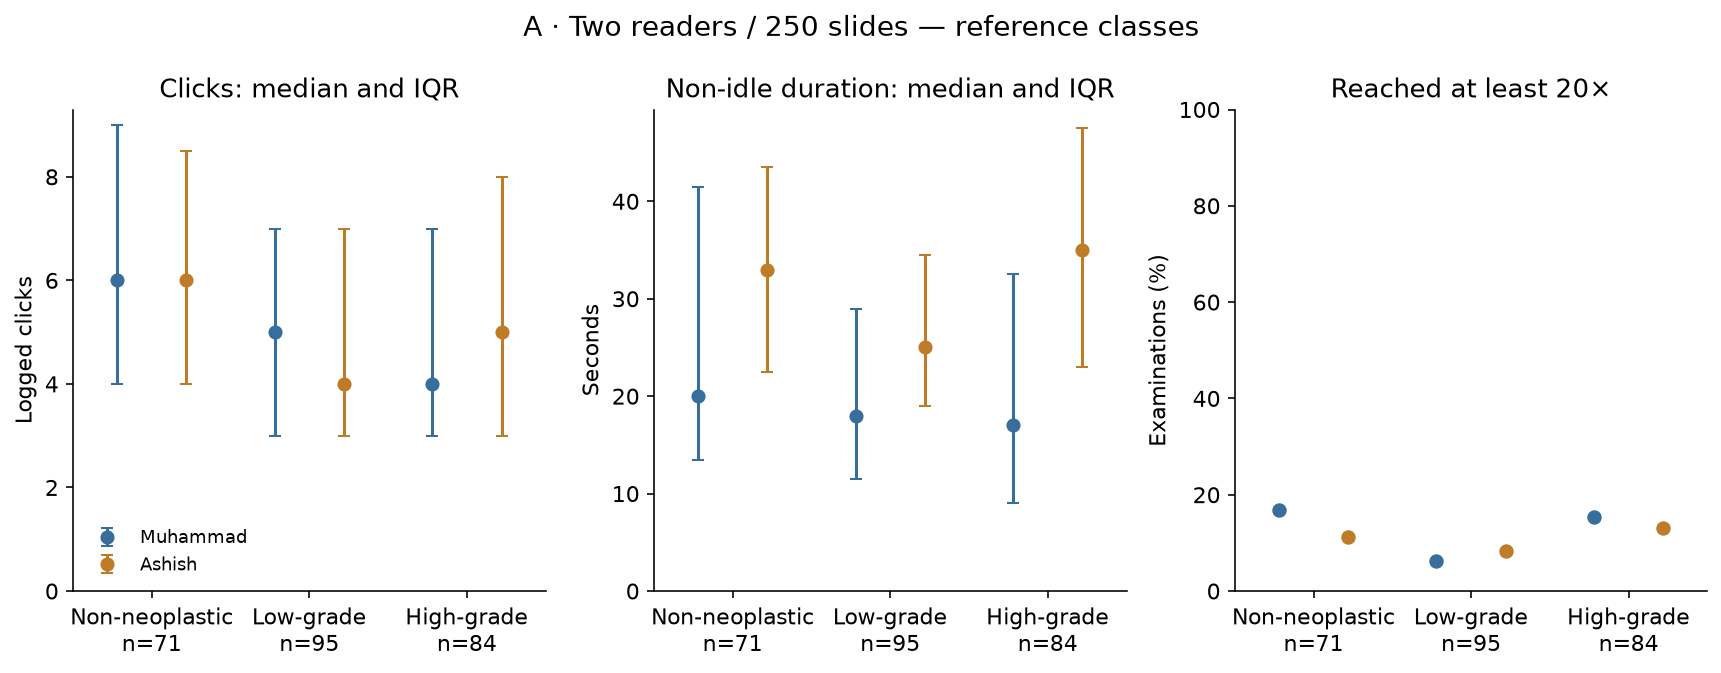

Reader,Reference,N,"Clicks: median [P25,P75]","Duration: median [P25,P75] s",Maximum zoom: median,Reached ≥20×
Muhammad Aslam,non-neoplastic,71,"6.0 [4.0, 9.0]","20.0 [13.5, 41.5]",5.0,12/71 (16.9%)
Muhammad Aslam,low-grade,95,"5.0 [3.0, 7.0]","18.0 [11.5, 29.0]",5.0,6/95 (6.3%)
Muhammad Aslam,high-grade,84,"4.0 [3.0, 7.0]","17.0 [9.0, 32.5]",5.0,13/84 (15.5%)
Ashish Bansal,non-neoplastic,71,"6.0 [4.0, 8.5]","33.0 [22.5, 43.5]",5.0,8/71 (11.3%)
Ashish Bansal,low-grade,95,"4.0 [3.0, 7.0]","25.0 [19.0, 34.5]",5.0,8/95 (8.4%)
Ashish Bansal,high-grade,84,"5.0 [3.0, 8.0]","35.0 [23.0, 47.5]",5.0,11/84 (13.1%)


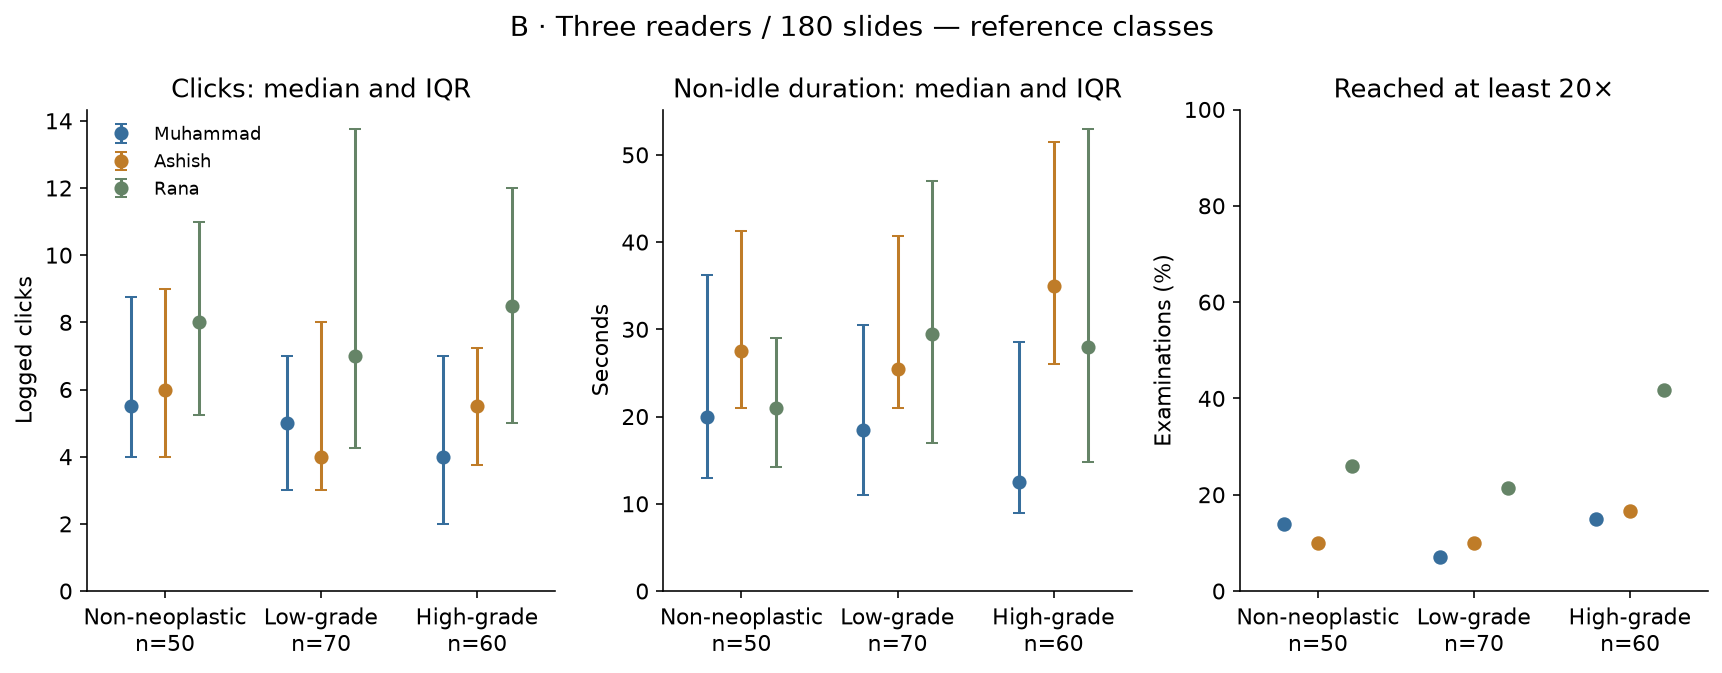

Reader,Reference,N,"Clicks: median [P25,P75]","Duration: median [P25,P75] s",Maximum zoom: median,Reached ≥20×
Muhammad Aslam,non-neoplastic,50,"5.5 [4.0, 8.8]","20.0 [13.0, 36.2]",5.0,7/50 (14.0%)
Muhammad Aslam,low-grade,70,"5.0 [3.0, 7.0]","18.5 [11.0, 30.5]",5.0,5/70 (7.1%)
Muhammad Aslam,high-grade,60,"4.0 [2.0, 7.0]","12.5 [9.0, 28.5]",5.0,9/60 (15.0%)
Ashish Bansal,non-neoplastic,50,"6.0 [4.0, 9.0]","27.5 [21.0, 41.2]",5.0,5/50 (10.0%)
Ashish Bansal,low-grade,70,"4.0 [3.0, 8.0]","25.5 [21.0, 40.8]",5.0,7/70 (10.0%)
Ashish Bansal,high-grade,60,"5.5 [3.8, 7.2]","35.0 [26.0, 51.5]",5.0,10/60 (16.7%)
Iftikhar Rana,non-neoplastic,50,"8.0 [5.2, 11.0]","21.0 [14.2, 29.0]",10.0,13/50 (26.0%)
Iftikhar Rana,low-grade,70,"7.0 [4.2, 13.8]","29.5 [17.0, 47.0]",5.0,15/70 (21.4%)
Iftikhar Rana,high-grade,60,"8.5 [5.0, 12.0]","28.0 [14.8, 53.0]",10.0,25/60 (41.7%)


In [52]:
for ra_key in ["A","B"]:
    fig,axes=plt.subplots(1,3,figsize=(12,4.7))
    ra_readers=cohort_readers[ra_key]
    ra_offsets=np.linspace(-.22,.22,len(ra_readers))
    for ra_j,ra_user in enumerate(ra_readers):
        ra_d=ra_cohorts[ra_key][ra_cohorts[ra_key].user_id.eq(ra_user)]
        for ra_i,ra_class in enumerate(CLASSES):
            ra_g=ra_d[ra_d.reference.eq(ra_class)]
            for ax,metric in zip(axes[:2],["n_cell_click","nonidle_s_30"]):
                q=ra_g[metric].quantile([.25,.5,.75])
                ax.errorbar(ra_i+ra_offsets[ra_j],q.loc[.5],
                    yerr=[[q.loc[.5]-q.loc[.25]],[q.loc[.75]-q.loc[.5]]],
                    fmt="o",capsize=3,color=BH_READER_COLOURS[ra_user],
                    label=FIRST_NAMES[ra_user] if ra_i==0 else None)
            axes[2].scatter(ra_i+ra_offsets[ra_j],100*ra_g.max_zoom.ge(20).mean(),
                            color=BH_READER_COLOURS[ra_user],s=38)
    counts=reference.loc[cohort_ids[ra_key]].value_counts()
    ticklabels=[f"Non-neoplastic\nn={counts['non-neoplastic']}",f"Low-grade\nn={counts['low-grade']}",f"High-grade\nn={counts['high-grade']}"]
    for ax,title in zip(axes,["Clicks: median and IQR","Non-idle duration: median and IQR","Reached at least 20×"]):
        ax.set(xticks=range(3),xticklabels=ticklabels,xlim=(-.5,2.5),title=title)
        ax.set_ylim(bottom=0)
    axes[0].set_ylabel("Logged clicks");axes[1].set_ylabel("Seconds");axes[2].set_ylabel("Examinations (%)")
    axes[2].set_ylim(0,100);axes[0].legend(frameon=False,fontsize=9)
    fig.suptitle(GROUP_NAMES[ra_key]+" — reference classes",fontsize=14)
    fig.tight_layout();show_figure(fig)
    rows=[]
    for ra_user in ra_readers:
        for ra_class in CLASSES:
            g=ra_cohorts[ra_key][ra_cohorts[ra_key].user_id.eq(ra_user)&ra_cohorts[ra_key].reference.eq(ra_class)]
            rows.append({"Reader":READER_NAMES[ra_user],"Reference":ra_class,"N":len(g),
                "Clicks: median [P25,P75]":bh_summary(g.n_cell_click),
                "Duration: median [P25,P75] s":bh_summary(g.nonidle_s_30),
                "Maximum zoom: median":float(g.max_zoom.median()),
                "Reached ≥20×":ratio_text(int(g.max_zoom.ge(20).sum()),len(g))})
    show_table(pd.DataFrame(rows))

### 6.2 Test the negative-versus-positive comparison directly

Combine low-grade and high-grade reference classes and compare that group with non-neoplastic. For each reader, subtract the positive-group median from the negative-group median. A positive difference means the negative group has the larger median under that measure.

We also repeat the grouping using the **reader's final label** as a clearly marked sensitivity. This answers what happened on images the reader ultimately called negative; it changes membership and does not establish the cause of searching behaviour.

In [53]:
ra_q6_binary_rows=[]
for ra_key in ["A","B"]:
    for ra_label_source,ra_column in [("Reference","reference_positive"),("Reader final label","reader_positive")]:
        rows=[]
        for ra_user in cohort_readers[ra_key]:
            d=ra_cohorts[ra_key][ra_cohorts[ra_key].user_id.eq(ra_user)]
            neg=d[~d[ra_column]];pos=d[d[ra_column]]
            row={"Cohort":ra_key,"Label source":ra_label_source,"Reader":READER_NAMES[ra_user],
                "Negative / positive N":f"{len(neg)} / {len(pos)}",
                "Duration medians, neg / pos (s)":f"{neg.nonidle_s_30.median():g} / {pos.nonidle_s_30.median():g}",
                "Duration difference (s)":float(neg.nonidle_s_30.median()-pos.nonidle_s_30.median()),
                "Click medians, neg / pos":f"{neg.n_cell_click.median():g} / {pos.n_cell_click.median():g}",
                "Click difference":float(neg.n_cell_click.median()-pos.n_cell_click.median())}
            rows.append(row);ra_q6_binary_rows.append(row)
        if ra_label_source=="Reference":
            display(Markdown("**"+GROUP_NAMES[ra_key]+" — reference-negative versus reference-positive**"))
            show_table(pd.DataFrame(rows).drop(columns=["Cohort","Label source"]))
        else:
            display(HTML("<details><summary>Own-label sensitivity — "+escape(GROUP_NAMES[ra_key])+"</summary>"+
                pd.DataFrame(rows).drop(columns=["Cohort","Label source"]).to_html(index=False,border=0)+"</details>"))

**A · Two readers / 250 slides — reference-negative versus reference-positive**

Reader,Negative / positive N,"Duration medians, neg / pos (s)",Duration difference (s),"Click medians, neg / pos",Click difference
Muhammad Aslam,71 / 179,20 / 17,3.0,6 / 4,2.0
Ashish Bansal,71 / 179,33 / 29,4.0,6 / 5,1.0


Reader,Negative / positive N,"Duration medians, neg / pos (s)",Duration difference (s),"Click medians, neg / pos",Click difference
Muhammad Aslam,70 / 180,21 / 17,4.0,7 / 4,3.0
Ashish Bansal,78 / 172,30 / 30,0.0,6 / 5,1.0


**B · Three readers / 180 slides — reference-negative versus reference-positive**

Reader,Negative / positive N,"Duration medians, neg / pos (s)",Duration difference (s),"Click medians, neg / pos",Click difference
Muhammad Aslam,50 / 130,20 / 17,3.0,5.5 / 4,1.5
Ashish Bansal,50 / 130,27.5 / 32,-4.5,6 / 5,1.0
Iftikhar Rana,50 / 130,21 / 28.5,-7.5,8 / 8,0.0


Reader,Negative / positive N,"Duration medians, neg / pos (s)",Duration difference (s),"Click medians, neg / pos",Click difference
Muhammad Aslam,52 / 128,20.5 / 16,4.5,6.5 / 4,2.5
Ashish Bansal,58 / 122,27.5 / 32,-4.5,6 / 5,1.0
Iftikhar Rana,53 / 127,23 / 28,-5.0,8 / 7,1.0


In [54]:
for ra_key in ["A","B"]:
    rows=[]
    for ra_user in cohort_readers[ra_key]:
        for ra_class in CLASSES:
            g=ra_cohorts[ra_key][ra_cohorts[ra_key].user_id.eq(ra_user)&ra_cohorts[ra_key].reference.eq(ra_class)]
            rows.append({"Reader":READER_NAMES[ra_user],"Reference":ra_class,"Group N":len(g),
                "Any pan":ratio_text(int(g.n_arrow_pan.gt(0).sum()),len(g)),
                "Click offset: median":round(float(g.median_click_offset.median()),3),
                "Offset valid N":int(g.median_click_offset.notna().sum()),
                "Target jump: median":round(float(g.median_target_jump.median()),3),
                "Jump valid N":int(g.median_target_jump.notna().sum())})
    display(HTML("<details><summary>Pan use and movement with valid denominators — "+escape(GROUP_NAMES[ra_key])+"</summary>"+
                 pd.DataFrame(rows).to_html(index=False,border=0)+"</details>"))
ra_b_reference=[r for r in ra_q6_binary_rows if r["Cohort"]=="B" and r["Label source"]=="Reference"]
display(Markdown("**Observed answer:** reference-negative slides do not consistently have longer logged duration across readers. "
    "On the common 180 slides, the negative-minus-positive difference of median durations is "+
    "; ".join(f"**{r['Reader']}: {r['Duration difference (s)']:+g} s**" for r in ra_b_reference)+
    ". The direction also changes for Ashish between the 250- and 180-slide sets. "
    "This does not support a universal negative-search rule from these records."))

Reader,Reference,Group N,Any pan,Click offset: median,Offset valid N,Target jump: median,Jump valid N
Muhammad Aslam,non-neoplastic,71,8/71 (11.3%),0.217,71,0.163,70
Muhammad Aslam,low-grade,95,8/95 (8.4%),0.213,95,0.184,88
Muhammad Aslam,high-grade,84,7/84 (8.3%),0.187,84,0.126,71
Ashish Bansal,non-neoplastic,71,6/71 (8.5%),0.220,70,0.168,68
Ashish Bansal,low-grade,95,8/95 (8.4%),0.205,94,0.154,85
Ashish Bansal,high-grade,84,6/84 (7.1%),0.167,83,0.121,74


Reader,Reference,Group N,Any pan,Click offset: median,Offset valid N,Target jump: median,Jump valid N
Muhammad Aslam,non-neoplastic,50,6/50 (12.0%),0.207,50,0.178,49
Muhammad Aslam,low-grade,70,6/70 (8.6%),0.213,70,0.183,64
Muhammad Aslam,high-grade,60,4/60 (6.7%),0.188,60,0.142,47
Ashish Bansal,non-neoplastic,50,3/50 (6.0%),0.220,49,0.167,48
Ashish Bansal,low-grade,70,6/70 (8.6%),0.193,69,0.111,63
Ashish Bansal,high-grade,60,5/60 (8.3%),0.161,60,0.137,53
Iftikhar Rana,non-neoplastic,50,9/50 (18.0%),0.157,50,0.092,50
Iftikhar Rana,low-grade,70,19/70 (27.1%),0.149,70,0.101,65
Iftikhar Rana,high-grade,60,12/60 (20.0%),0.144,60,0.059,60


**Observed answer:** reference-negative slides do not consistently have longer logged duration across readers. On the common 180 slides, the negative-minus-positive difference of median durations is **Muhammad Aslam: +3 s**; **Ashish Bansal: -4.5 s**; **Iftikhar Rana: -7.5 s**. The direction also changes for Ashish between the 250- and 180-slide sets. This does not support a universal negative-search rule from these records.

### Question 6 — limits

The category groups are selected images rather than randomized conditions; differences may reflect composition, morphology, reader judgement or interface use. Own-label grouping is an outcome-conditioned description, not a correction of the reference. Movement summaries need their own valid denominators. Logged duration is not measured cognitive effort.

The data can describe class-associated behaviour but cannot reveal why a reader stopped or the exact moment decisive tissue was noticed. That would need additional expert/region-level evidence.

<a id="question-7"></a>

# Question 7 — Do readers display the same regions?

**Purpose.** Question 5 compared how much activity each slide elicited. Here we compare *where the logged viewports were*. We then revisit the meeting suggestion: does spatial consistency remain when both readers match the reference? The three-reader cohort also separates all-three-reference matches and unanimous disagreements.

The unit remains one selected examination per reader–slide, ending at the retained diagnosis. **A** contains Muhammad/Ashish on 250 slides; **B** contains all three on Rana's same 180. A spatial estimate requires positive usable exposure for every cohort reader, so its valid subset can be smaller; missing maps never become uniform maps or zeros.

### 7.1 Turn rectangles into a shared spatial measurement

1. Within each slide, form one **logged viewport envelope** from the minimum and maximum valid coordinates across the selected examinations of the available study readers. Use that same envelope for every reader and both cohorts. Keep negative coordinates: they can represent letterboxing. This is a computational frame, **not the known image boundary or tissue mask**.
2. Divide the envelope into 64 × 64 equal-area bins. A rectangle contributes its estimated non-idle seconds to the fraction of each bin it covers. Follow Q4's idle/reload exclusions and 30-second interval cap. The recorded rectangle at the start of an interval approximates the displayed state; whole-second timestamps and pre-action events limit precision.
3. Primary maps use intervals at **≥2.5×**. This excludes the below-first-rung overview that can make maps look alike simply because much of the slide was on screen. The threshold is an analysis choice, not a guarantee of tissue inspection. All-known-zoom maps are a sensitivity analysis.
4. Normalize each map to sum to one. **Exposure-map similarity (SIM)** is the sum of the smaller value in corresponding bins: 0 is disjoint and 1 is identical normalized exposure. This measures the distribution of *space–time display exposure*: larger rectangles illuminate more bins. It is neither a percentage of viewing time nor a percentage of tissue examined.
5. **Spatial correlation (CC)** compares the relative bin intensities. It is undefined for a constant map; those counts are explicit. Empty shared background can influence it, so retain SIM and the map examples too.

The CSV has no slide dimensions, tissue masks, gaze points or lesion annotations. This analysis cannot establish that readers attended to the same cells, found the tumour, or covered a given fraction of tissue. Current viewer coordinate semantics are in `src/viewer/main.ts` (`viewportToImageCoordinates` and `logEvent`). Unlike the historical `analysis/src/saliency.py`, these maps weight time rather than event frequency, preserve empty/constant-map missingness, and do not merge all attempts.

In [55]:
from itertools import combinations as sp_combinations
sp_grid_size = 64
sp_primary_zoom = 2.5
sp_bounds = ["vbx0", "vby0", "vtx0", "vty0"]

def sp_build_intervals(selected):
    records = []
    for (user, slide), group in selected.groupby(["user_id", "slide_id"], sort=True):
        rows = group.sort_values(["timestamp", "source_row"], kind="stable").to_dict("records")
        idle = False
        for i, row in enumerate(rows[:-1]):
            if row["event"] in BH_LOAD_EVENTS: idle = False
            elif row["event"] == "idle_start": idle = True
            elif row["event"] == "idle_end": idle = False
            following = rows[i + 1]
            seconds = (following["timestamp"] - row["timestamp"]).total_seconds()
            assert seconds >= 0
            if idle or following["event"] in BH_LOAD_EVENTS or seconds == 0:
                continue
            values = np.array([row[c] for c in sp_bounds], dtype=float)
            valid = (np.isfinite(values).all() and values[0] != values[2] and values[1] != values[3])
            records.append({"user_id":user, "slide_id":slide, "source_row":row["source_row"],
                "seconds":min(seconds, BH_PRIMARY_CAP), "uncapped_seconds":seconds,
                "zoom":row["zoom_level"], "valid_geometry":valid,
                "x0":min(values[0],values[2]), "x1":max(values[0],values[2]),
                "y0":min(values[1],values[3]), "y1":max(values[1],values[3])})
    return pd.DataFrame(records)

sp_intervals = sp_build_intervals(bh_selected)
sp_extents = {}
for sp_slide, sp_group in bh_selected.groupby("slide_id", sort=True):
    sp_b = sp_group[sp_bounds].dropna()
    sp_b = sp_b[(sp_b.vbx0 != sp_b.vtx0) & (sp_b.vby0 != sp_b.vty0)]
    if len(sp_b):
        sp_extents[sp_slide] = (float(np.minimum(sp_b.vbx0,sp_b.vtx0).min()),
            float(np.minimum(sp_b.vby0,sp_b.vty0).min()),
            float(np.maximum(sp_b.vbx0,sp_b.vtx0).max()),
            float(np.maximum(sp_b.vby0,sp_b.vty0).max()))

def sp_exposure_map(intervals, extent, grid=64):
    x0, y0, x1, y1 = extent
    xe = np.linspace(x0, x1, grid+1); ye = np.linspace(y0, y1, grid+1)
    result = np.zeros((grid, grid), dtype=float)
    for row in intervals.itertuples(index=False):
        xf = np.maximum(0., np.minimum(xe[1:],row.x1)-np.maximum(xe[:-1],row.x0))/np.diff(xe)
        yf = np.maximum(0., np.minimum(ye[1:],row.y1)-np.maximum(ye[:-1],row.y0))/np.diff(ye)
        result += row.seconds * np.outer(yf, xf)
    return result

def sp_build_maps(intervals, min_zoom, grid=64):
    usable = intervals[intervals.valid_geometry & intervals.zoom.ge(min_zoom) & intervals.zoom.gt(0)]
    maps = {}
    for (user, slide), group in usable.groupby(["user_id","slide_id"], sort=True):
        if slide in sp_extents:
            exposure = sp_exposure_map(group, sp_extents[slide], grid)
            if exposure.sum() > 0:
                maps[(user,slide)] = exposure/exposure.sum()
    return maps

def sp_similarity(first, second):
    a = np.asarray(first).ravel(); b = np.asarray(second).ravel()
    ac = a-a.mean(); bc = b-b.mean()
    denominator = np.linalg.norm(ac)*np.linalg.norm(bc)
    cc = float(np.dot(ac,bc)/denominator) if denominator > 1e-14 else np.nan
    return {"sim":float(np.minimum(a,b).sum()), "cc":cc}

sp_maps = sp_build_maps(sp_intervals, sp_primary_zoom, sp_grid_size)
sp_all_maps = sp_build_maps(sp_intervals, 0, sp_grid_size)
sp_diagnosis = diagnoses.set_index(["user_id","slide_id"]).diagnosis
sp_valid_ids = {k:[s for s in cohort_ids[k] if all((u,s) in sp_maps for u in cohort_readers[k])]
                for k in ["A","B"]}
sp_inventory_rows=[]
for sp_k in ["A","B"]:
    for sp_u in cohort_readers[sp_k]:
        sp_d=sp_intervals[sp_intervals.user_id.eq(sp_u)&sp_intervals.slide_id.isin(cohort_ids[sp_k])]
        sp_inventory_rows.append({"Cohort":sp_k,"Reader":READER_NAMES[sp_u],
            "Diagnoses":len(cohort_ids[sp_k]),
            "Any usable ≥2.5× map":sum((sp_u,s) in sp_maps for s in cohort_ids[sp_k]),
            "Any usable all-zoom map":sum((sp_u,s) in sp_all_maps for s in cohort_ids[sp_k]),
            "Common valid spatial slides":len(sp_valid_ids[sp_k]),
            "Invalid-geometry non-idle seconds":float(sp_d.loc[~sp_d.valid_geometry,"seconds"].sum())})
show_table(pd.DataFrame(sp_inventory_rows))
sp_excluded=[]
for sp_k in ["A","B"]:
    for sp_s in sorted(set(cohort_ids[sp_k])-set(sp_valid_ids[sp_k])):
        for sp_u in cohort_readers[sp_k]:
            if (sp_u,sp_s) not in sp_maps:
                sp_f=bh_features[bh_features.user_id.eq(sp_u)&bh_features.slide_id.eq(sp_s)].iloc[0]
                sp_excluded.append({"Cohort":sp_k,"Slide":sp_s,"Reader without primary map":FIRST_NAMES[sp_u],
                    "Maximum logged magnification":sp_f.max_zoom,
                    "All-zoom map available":(sp_u,sp_s) in sp_all_maps,
                    "Reason":"No positive retained time with valid bounds at ≥2.5×"})
show_table(pd.DataFrame(sp_excluded))

Cohort,Reader,Diagnoses,Any usable ≥2.5× map,Any usable all-zoom map,Common valid spatial slides,Invalid-geometry non-idle seconds
A,Muhammad Aslam,250,250,250,247,0.0
A,Ashish Bansal,250,247,250,247,9.0
B,Muhammad Aslam,180,180,180,178,0.0
B,Ashish Bansal,180,178,180,178,9.0
B,Iftikhar Rana,180,180,180,178,12.0


Cohort,Slide,Reader without primary map,Maximum logged magnification,All-zoom map available,Reason
A,CRC_0824,Ashish,0.63,True,No positive retained time with valid bounds at ≥2.5×
A,CRC_1568,Ashish,0.63,True,No positive retained time with valid bounds at ≥2.5×
A,CRC_3712,Ashish,0.63,True,No positive retained time with valid bounds at ≥2.5×
B,CRC_0824,Ashish,0.63,True,No positive retained time with valid bounds at ≥2.5×
B,CRC_1568,Ashish,0.63,True,No positive retained time with valid bounds at ≥2.5×


### 7.2 Compare the same slide, then check how much generic spatial structure contributes

The primary result is one similarity value per slide and pair, summarized across slides with equal weight. Every pair in B uses the **same all-three spatially valid intersection**.

Two deliberately limited comparators help interpret those values:

- **Reflected same-slide maps:** compare one reader's map with the other's left/right, up/down and both-axis reflections, averaging the three similarities and both reflection directions. This preserves each map's intensity distribution, occupied area and envelope. A central symmetric map may remain similar after reflection. Reflections do not preserve tissue position or represent random human behaviour.
- **Matched different-slide maps:** for each valid focal slide, select up to five other valid slides with the same reference class and envelope width *and* height within a factor of 1.5; choose the closest in log width/height distance. Compare maps in relative envelope coordinates, average both reader assignments, then average controls per focal slide. Matching limits obvious class/geometry differences but does not match tissue layout, lesions or all behavioural features. Different-slide normalization is not physical co-registration.

These are **descriptive controls, not a calibrated chance null**. We report same-slide minus matched-control overlap only on focal slides with an eligible match. Reused control slides, shared readers and overlapping cohorts mean observations are dependent. No p-values or claim of tumour-specific attention follows from these controls.

In [56]:
def sp_reference_pattern(slide, users):
    labels = [sp_diagnosis.loc[(u,slide)] for u in users]
    correct = [label == reference.loc[slide] for label in labels]
    if all(correct): return "All match reference"
    if len(set(labels)) == 1: return "Unanimous non-reference"
    return "Other label pattern"

def sp_pair_frame(maps, cohort, valid_ids, controls=True):
    rows=[]
    for first,second in sp_combinations(cohort_readers[cohort],2):
        for slide in valid_ids:
            a=maps[(first,slide)]; b=maps[(second,slide)]
            stats=sp_similarity(a,b)
            la=sp_diagnosis.loc[(first,slide)]; lb=sp_diagnosis.loc[(second,slide)]
            ca=la==reference.loc[slide]; cb=lb==reference.loc[slide]
            pattern=("Both match reference" if ca and cb else "Same non-reference label" if la==lb
                     else "One matches reference" if ca or cb else "Different labels; neither matches")
            record={"cohort":cohort,"slide_id":slide,"first":first,"second":second,
                "pair":FIRST_NAMES[first]+" / "+FIRST_NAMES[second],"reference":reference.loc[slide],
                "pair_pattern":pattern,"cohort_pattern":sp_reference_pattern(slide,cohort_readers[cohort]),**stats}
            if controls:
                reflected=[]
                for axes in [(0,),(1,),(0,1)]:
                    reflected.extend([sp_similarity(a,np.flip(b,axis=axes))["sim"],
                                      sp_similarity(np.flip(a,axis=axes),b)["sim"]])
                record["reflected_sim"]=float(np.mean(reflected))
                x0,y0,x1,y1=sp_extents[slide]
                geometry=np.array([x1-x0,y1-y0])
                candidates=[]
                for other in valid_ids:
                    if other==slide or reference.loc[other]!=reference.loc[slide]: continue
                    ox0,oy0,ox1,oy1=sp_extents[other]
                    difference=np.log(np.array([ox1-ox0,oy1-oy0])/geometry)
                    if np.abs(difference).max()<=np.log(1.5):
                        candidates.append((float(np.linalg.norm(difference)),other))
                matched=[s for _,s in sorted(candidates)[:5]]
                values=[0.5*(sp_similarity(a,maps[(second,s)])["sim"]+
                             sp_similarity(maps[(first,s)],b)["sim"]) for s in matched]
                record.update({"matched_control_n":len(matched),
                    "matched_slide_ids":"; ".join(matched),
                    "matched_sim":float(np.mean(values)) if values else np.nan})
            rows.append(record)
    return pd.DataFrame(rows)

sp_pairs=pd.concat([sp_pair_frame(sp_maps,k,sp_valid_ids[k]) for k in ["A","B"]],ignore_index=True)
sp_summary_rows=[]
for (sp_k,sp_pair),sp_d in sp_pairs.groupby(["cohort","pair"],sort=False):
    sp_matched=sp_d.dropna(subset=["matched_sim"])
    sp_summary_rows.append({"Cohort":sp_k,"Pair":sp_pair,"Valid / cohort":f"{len(sp_d)}/{len(cohort_ids[sp_k])}",
        "SIM median [P25,P75]":bh_summary(sp_d.sim,3),
        "CC median [P25,P75]":bh_summary(sp_d.cc,3),"CC defined n":int(sp_d.cc.notna().sum()),
        "Matched-control focal n":len(sp_matched),
        "Mean same-minus-reflected SIM":round(float((sp_d.sim-sp_d.reflected_sim).mean()),3),
        "Mean same-minus-control SIM":round(float((sp_matched.sim-sp_matched.matched_sim).mean()),3)})
show_table(pd.DataFrame(sp_summary_rows))

Cohort,Pair,Valid / cohort,"SIM median [P25,P75]","CC median [P25,P75]",CC defined n,Matched-control focal n,Mean same-minus-reflected SIM,Mean same-minus-control SIM
A,Muhammad / Ashish,247/250,"0.801 [0.180, 0.918]","0.434 [0.217, 0.596]",247,246,0.033,0.063
B,Muhammad / Ashish,178/180,"0.815 [0.186, 0.921]","0.450 [0.256, 0.614]",178,178,0.030,0.059
B,Muhammad / Rana,178/180,"0.736 [0.132, 0.909]","0.397 [0.204, 0.583]",178,178,0.028,0.059
B,Ashish / Rana,178/180,"0.799 [0.196, 0.903]","0.439 [0.222, 0.594]",178,178,0.039,0.061


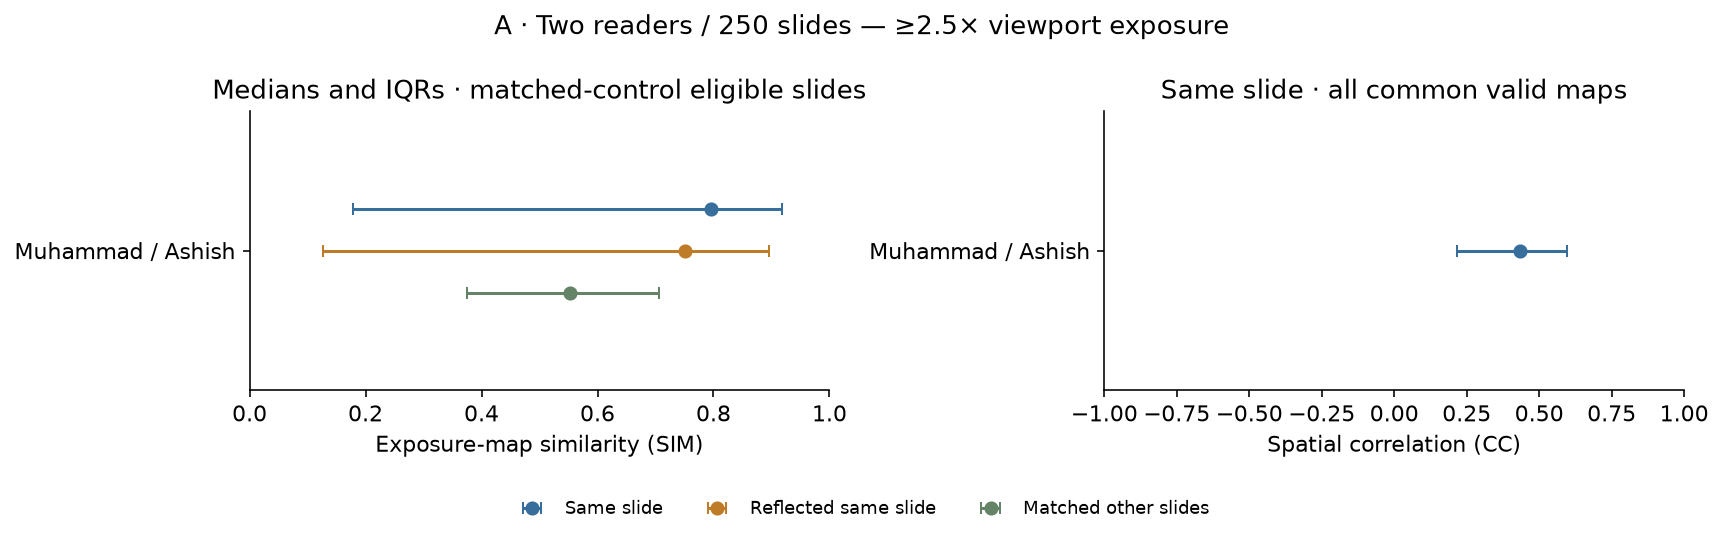

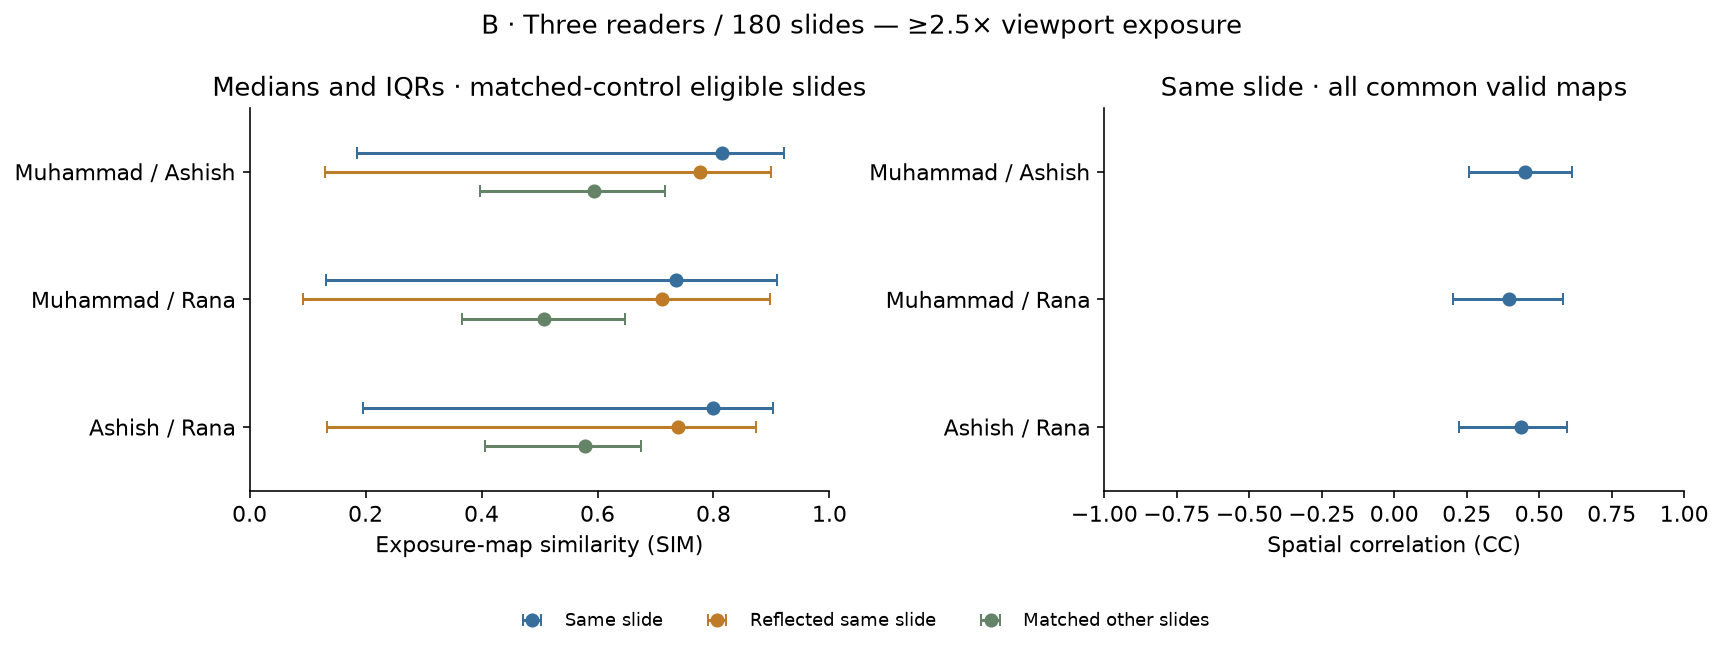

In [57]:
for sp_k in ["A","B"]:
    sp_d=sp_pairs[sp_pairs.cohort.eq(sp_k)]
    sp_names=list(dict.fromkeys(sp_d.pair))
    sp_fig,sp_axes=plt.subplots(1,2,figsize=(12,3.7 if sp_k=="A" else 4.5))
    for sp_i,sp_pair in enumerate(sp_names):
        sp_p=sp_d[sp_d.pair.eq(sp_pair)]
        for sp_field,sp_label,sp_colour,sp_offset in [("sim","Same slide","#376E9C",-.15),
            ("reflected_sim","Reflected same slide","#BF7C28",0.),
            ("matched_sim","Matched other slides","#658467",.15)]:
            sp_values=sp_p.dropna(subset=["matched_sim"])[sp_field]
            sp_q=sp_values.quantile([.25,.5,.75])
            sp_axes[0].errorbar(sp_q.loc[.5],sp_i+sp_offset,
                xerr=[[sp_q.loc[.5]-sp_q.loc[.25]],[sp_q.loc[.75]-sp_q.loc[.5]]],fmt="o",
                color=sp_colour,capsize=3,label=sp_label if sp_i==0 else None)
        sp_q=sp_p.cc.dropna().quantile([.25,.5,.75])
        sp_axes[1].errorbar(sp_q.loc[.5],sp_i,xerr=[[sp_q.loc[.5]-sp_q.loc[.25]],
            [sp_q.loc[.75]-sp_q.loc[.5]]],fmt="o",color="#376E9C",capsize=3)
    for sp_ax in sp_axes:
        sp_ax.set(yticks=range(len(sp_names)),yticklabels=sp_names,ylim=(-.5,len(sp_names)-.5))
        sp_ax.invert_yaxis()
    sp_axes[0].set(xlabel="Exposure-map similarity (SIM)",xlim=(0,1),
        title="Medians and IQRs · matched-control eligible slides")
    sp_fig.legend(*sp_axes[0].get_legend_handles_labels(),frameon=False,loc="lower center",ncol=3,fontsize=9,bbox_to_anchor=(.5,.01))
    sp_axes[1].set(xlabel="Spatial correlation (CC)",xlim=(-1,1),
        title="Same slide · all common valid maps")
    sp_fig.suptitle(GROUP_NAMES[sp_k]+" — ≥2.5× viewport exposure",fontsize=13)
    sp_fig.tight_layout(rect=(0,.11,1,1)); show_figure(sp_fig)

### 7.3 Does overlap remain when diagnoses match the reference?

Compare **both-match-reference** slides against same-label disagreements and other patterns *within each pair*. For B, also use one three-reader SIM per slide: the sum of the minimum of all three normalized maps in every bin. Three-way overlap is stricter than pairwise overlap and should not be compared as if it were the same quantity.

“Correct” here means exact three-class reference agreement, as in Q1. These descriptive subgroups can differ in class, tissue geometry, ambiguity and effort. They do not establish that viewing overlap causes reference agreement, or adjudicate shared disagreements.

In the three-reader distribution plot, each dot is one slide and the black tick is the median. Small vertical separation only keeps observations visible; it is not a second measured quantity.

Overall three-way SIM: 0.360 [0.062, 0.850]; n=178/180


Cohort,Pair,Label pattern,All labelled slides,Spatially valid slides,"SIM median [P25,P75]",CC defined n,"CC median [P25,P75]"
A,Muhammad / Ashish,Both match reference,155,153,"0.807 [0.204, 0.918]",153,"0.450 [0.216, 0.635]"
A,Muhammad / Ashish,Same non-reference label,66,65,"0.759 [0.191, 0.925]",65,"0.424 [0.243, 0.578]"
A,Muhammad / Ashish,One matches reference,29,29,"0.802 [0.162, 0.908]",29,"0.403 [0.211, 0.559]"
A,Muhammad / Ashish,Different labels; neither matches,0,0,Not measurable,0,Not measurable
B,Muhammad / Ashish,Both match reference,116,114,"0.845 [0.217, 0.918]",114,"0.463 [0.314, 0.650]"
B,Muhammad / Ashish,Same non-reference label,45,45,"0.770 [0.191, 0.932]",45,"0.369 [0.227, 0.518]"
B,Muhammad / Ashish,One matches reference,19,19,"0.802 [0.160, 0.917]",19,"0.377 [0.241, 0.568]"
B,Muhammad / Ashish,Different labels; neither matches,0,0,Not measurable,0,Not measurable
B,Muhammad / Rana,Both match reference,108,106,"0.411 [0.105, 0.901]",106,"0.397 [0.204, 0.572]"
B,Muhammad / Rana,Same non-reference label,38,38,"0.808 [0.180, 0.916]",38,"0.389 [0.192, 0.584]"


Label pattern,All labelled slides,Spatially valid slides,"Three-way SIM median [P25,P75]"
All match reference,104,102,"0.198 [0.053, 0.833]"
Unanimous non-reference,36,36,"0.209 [0.092, 0.844]"
Other label pattern,40,40,"0.738 [0.087, 0.894]"


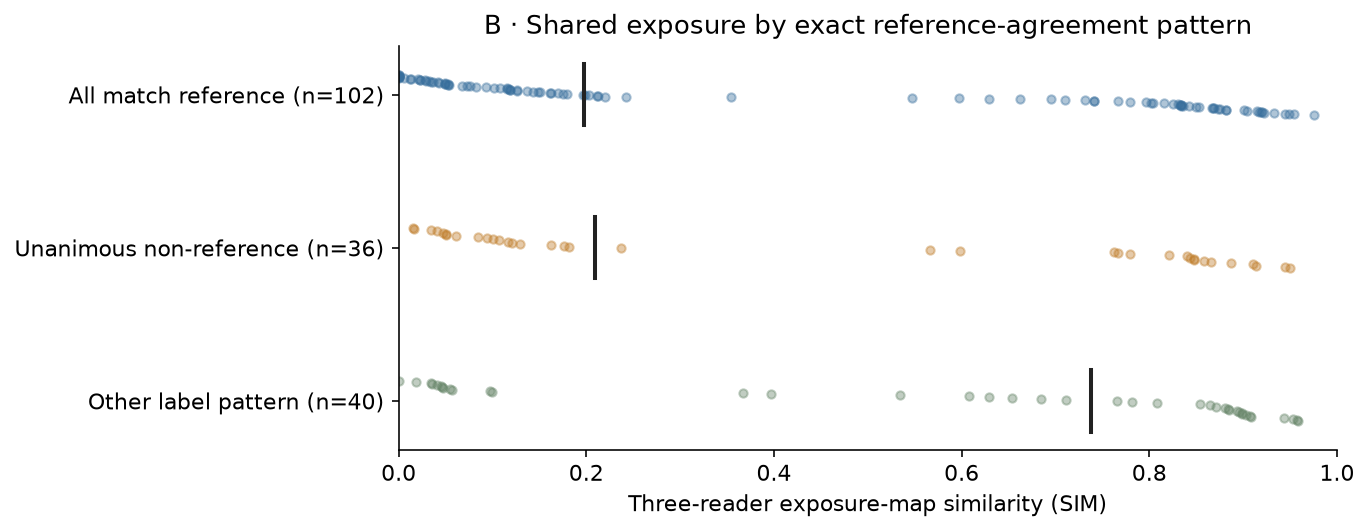

In [58]:
sp_subgroup_rows=[]
for (sp_k,sp_pair),sp_p in sp_pairs.groupby(["cohort","pair"],sort=False):
    sp_full=q2_wide[sp_k]
    sp_a=sp_p.iloc[0]["first"]; sp_b=sp_p.iloc[0]["second"]
    sp_ca=sp_full[sp_a].eq(sp_full.reference); sp_cb=sp_full[sp_b].eq(sp_full.reference)
    sp_same=sp_full[sp_a].eq(sp_full[sp_b])
    sp_masks={"Both match reference":sp_ca&sp_cb,"Same non-reference label":sp_same&~sp_ca,
        "One matches reference":sp_ca^sp_cb,"Different labels; neither matches":~sp_same&~sp_ca&~sp_cb}
    for sp_pattern,sp_mask in sp_masks.items():
        sp_d=sp_p[sp_p.pair_pattern.eq(sp_pattern)]
        sp_subgroup_rows.append({"Cohort":sp_k,"Pair":sp_pair,"Label pattern":sp_pattern,
            "All labelled slides":int(sp_mask.sum()),"Spatially valid slides":len(sp_d),
            "SIM median [P25,P75]":bh_summary(sp_d.sim,3),"CC defined n":int(sp_d.cc.notna().sum()),
            "CC median [P25,P75]":bh_summary(sp_d.cc,3)})
show_table(pd.DataFrame(sp_subgroup_rows))
sp_three_rows=[]
for sp_slide in sp_valid_ids["B"]:
    sp_stack=np.stack([sp_maps[(u,sp_slide)] for u in THREE])
    sp_three_rows.append({"slide_id":sp_slide,"pattern":sp_reference_pattern(sp_slide,THREE),
        "sim_three":float(np.min(sp_stack,axis=0).sum())})
sp_three=pd.DataFrame(sp_three_rows)
print(f"Overall three-way SIM: {bh_summary(sp_three.sim_three,3)}; n={len(sp_three)}/{len(cohort_ids['B'])}")
sp_three_summary=[]
for sp_pattern in ["All match reference","Unanimous non-reference","Other label pattern"]:
    sp_d=sp_three[sp_three.pattern.eq(sp_pattern)]
    sp_three_summary.append({"Label pattern":sp_pattern,
        "All labelled slides":sum(sp_reference_pattern(s,THREE)==sp_pattern for s in cohort_ids["B"]),
        "Spatially valid slides":len(sp_d),"Three-way SIM median [P25,P75]":bh_summary(sp_d.sim_three,3)})
show_table(pd.DataFrame(sp_three_summary))
sp_fig,sp_ax=plt.subplots(figsize=(9.5,3.8))
for sp_i,sp_pattern in enumerate(["All match reference","Unanimous non-reference","Other label pattern"]):
    sp_v=np.sort(sp_three.loc[sp_three.pattern.eq(sp_pattern),"sim_three"].to_numpy())
    sp_jitter=np.linspace(-.13,.13,len(sp_v)) if len(sp_v)>1 else np.zeros(len(sp_v))
    sp_ax.scatter(sp_v,sp_i+sp_jitter,s=17,alpha=.4,color=["#376E9C","#BF7C28","#658467"][sp_i])
    sp_ax.plot([np.median(sp_v)]*2,[sp_i-.2,sp_i+.2],color="#222222",linewidth=2)
sp_ax.set(yticks=[0,1,2],yticklabels=[f"{r['Label pattern']} (n={r['Spatially valid slides']})" for r in sp_three_summary],
    xlabel="Three-reader exposure-map similarity (SIM)",xlim=(0,1),
    title="B · Shared exposure by exact reference-agreement pattern")
sp_ax.invert_yaxis();sp_fig.tight_layout();show_figure(sp_fig)

### 7.4 Inspect one concrete slide

Select the all-three-reference-match slide nearest the median three-way overlap in that subgroup, breaking ties by slide ID. This reproducible descriptive example is neither a best case nor evidence that the unshown tissue was diagnostic. Axes are level-0 pixel coordinates within the same logged envelope. Colours show each normalized map on a common scale; no slide image or tissue annotation is overlaid.

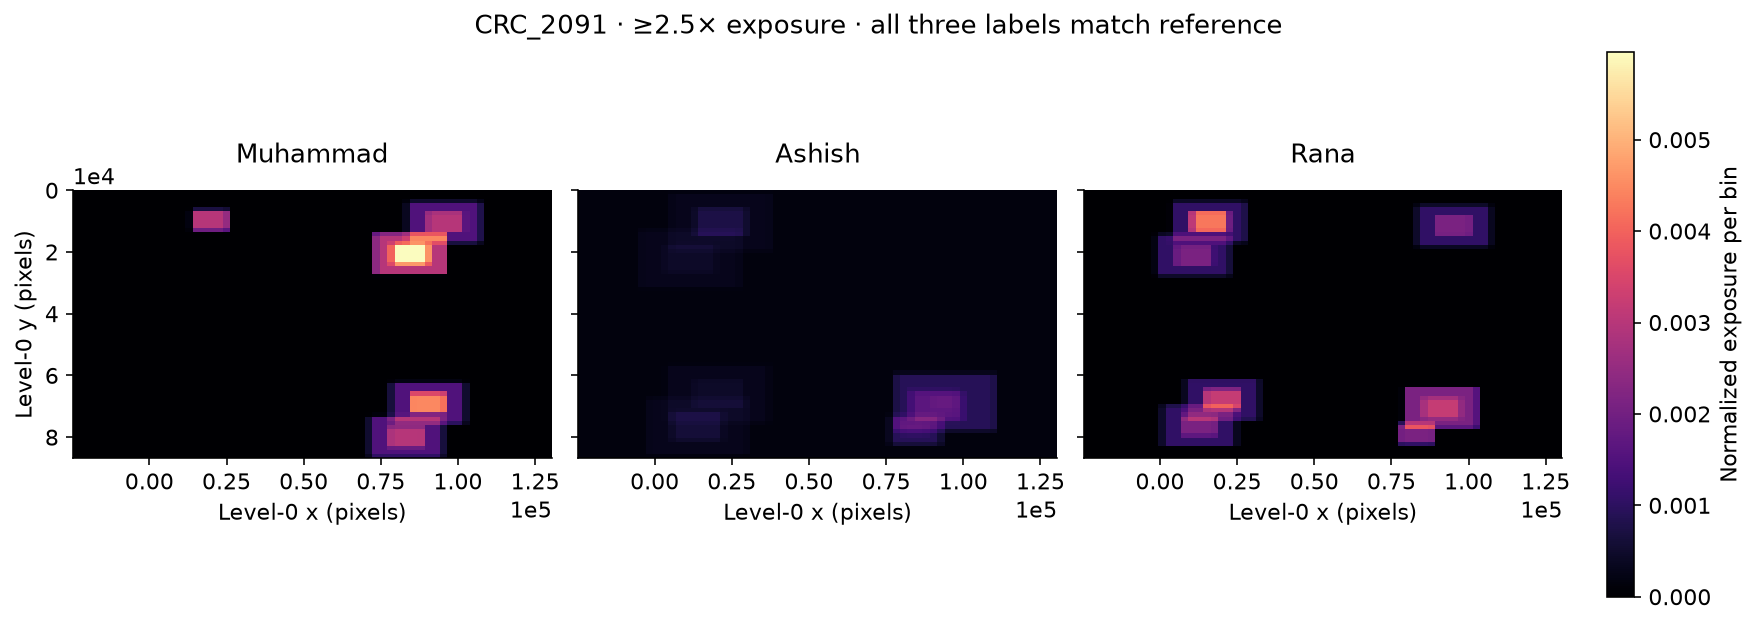

slide_id,pair,reference,sim,cc
CRC_2091,Muhammad / Ashish,low-grade,0.246,0.414
CRC_2091,Muhammad / Rana,low-grade,0.411,0.430
CRC_2091,Ashish / Rana,low-grade,0.367,0.689


In [59]:
sp_candidates=sp_three[sp_three.pattern.eq("All match reference")].sort_values("slide_id").copy()
sp_candidates["distance_to_median"]=(sp_candidates.sim_three-sp_candidates.sim_three.median()).abs()
sp_example_slide=sp_candidates.sort_values(["distance_to_median","slide_id"],kind="stable").iloc[0].slide_id
sp_example_maps=[sp_maps[(u,sp_example_slide)] for u in THREE]
sp_x0,sp_y0,sp_x1,sp_y1=sp_extents[sp_example_slide]
sp_vmax=max(m.max() for m in sp_example_maps)
sp_fig,sp_axes=plt.subplots(1,3,figsize=(12,4.2),sharex=True,sharey=True,layout="constrained")
for sp_ax,sp_u,sp_m in zip(sp_axes,THREE,sp_example_maps):
    sp_im=sp_ax.imshow(sp_m,extent=(sp_x0,sp_x1,sp_y1,sp_y0),cmap="magma",vmin=0,vmax=sp_vmax,aspect="equal")
    sp_ax.text(.5,1.08,FIRST_NAMES[sp_u],ha="center",va="bottom",transform=sp_ax.transAxes,fontsize=13,clip_on=False,zorder=20)
    sp_ax.set_xlabel("Level-0 x (pixels)")
    sp_ax.ticklabel_format(axis="both",style="sci",scilimits=(0,0))
sp_axes[0].set_ylabel("Level-0 y (pixels)")
sp_fig.colorbar(sp_im,ax=sp_axes.ravel().tolist(),label="Normalized exposure per bin",fraction=.025,pad=.025)
sp_fig.suptitle(f"{sp_example_slide} · ≥2.5× exposure · all three labels match reference",fontsize=13)
show_figure(sp_fig)
show_table(sp_pairs.loc[sp_pairs.cohort.eq("B")&sp_pairs.slide_id.eq(sp_example_slide),
    ["slide_id","pair","reference","sim","cc"]].round({"sim":3,"cc":3}))

### 7.5 Sensitivity and independent arithmetic checks

Compare all-zoom maps on the *same primary valid slides*, and repeat the primary maps at 128 × 128 bins. The first changes the scientific quantity by adding the below-2.5× overview; the second changes numerical resolution. A duplicate-row sensitivity checks whether repeated exported records drive these estimates. Additional 15/60-second interval caps check the influence of sparse logging. A separate table also shows the full available all-zoom cohort, keeping the changed denominator explicit. These alternatives do not recover missing gaze or tissue information.

In [60]:
sp_fine_maps=sp_build_maps(sp_intervals,sp_primary_zoom,128)
sp_dedup_intervals=sp_build_intervals(bh_selected.loc[~bh_selected.duplicate_copy])
sp_dedup_maps=sp_build_maps(sp_dedup_intervals,sp_primary_zoom,sp_grid_size)
sp_cap_maps={}
for sp_cap in [15,60]:
    sp_i=sp_intervals.copy();sp_i["seconds"]=sp_i.uncapped_seconds.clip(upper=sp_cap)
    sp_cap_maps[sp_cap]=sp_build_maps(sp_i,sp_primary_zoom,sp_grid_size)
sp_sensitivity_rows=[]
for sp_k in ["A","B"]:
    for sp_a,sp_b in sp_combinations(cohort_readers[sp_k],2):
        sp_ids=sp_valid_ids[sp_k]
        sp_base=np.array([sp_similarity(sp_maps[(sp_a,s)],sp_maps[(sp_b,s)])["sim"] for s in sp_ids])
        sp_record={"Cohort":sp_k,"Pair":FIRST_NAMES[sp_a]+" / "+FIRST_NAMES[sp_b],"Common n":len(sp_ids),
            "Primary SIM median":float(np.median(sp_base))}
        for sp_name,sp_source in [("All zoom",sp_all_maps),("128-bin",sp_fine_maps),
            ("Deduplicated",sp_dedup_maps),("15s cap",sp_cap_maps[15]),("60s cap",sp_cap_maps[60])]:
            assert all((u,s) in sp_source for s in sp_ids for u in [sp_a,sp_b])
            sp_alt=np.array([sp_similarity(sp_source[(sp_a,s)],sp_source[(sp_b,s)])["sim"] for s in sp_ids])
            sp_record[sp_name+" median"]=float(np.median(sp_alt))
            sp_record[sp_name+" max |ΔSIM|"]=float(np.max(np.abs(sp_alt-sp_base)))
        sp_sensitivity_rows.append(sp_record)
sp_sensitivity=pd.DataFrame(sp_sensitivity_rows)
show_table(sp_sensitivity[["Cohort","Pair","Common n","Primary SIM median","All zoom median", "128-bin median",
    "128-bin max |ΔSIM|","Deduplicated max |ΔSIM|","15s cap max |ΔSIM|","60s cap max |ΔSIM|"]].round(3))

sp_all_valid_ids={k:[s for s in cohort_ids[k] if all((u,s) in sp_all_maps for u in cohort_readers[k])]
                  for k in ["A","B"]}
sp_all_pair_results=pd.concat([sp_pair_frame(sp_all_maps,k,sp_all_valid_ids[k],controls=False)
                              for k in ["A","B"]],ignore_index=True)
show_table(pd.DataFrame([{"Cohort":k,"Pair":pair,"All-zoom common n":len(d),
    "All-zoom SIM median [P25,P75]":bh_summary(d.sim,3)}
    for (k,pair),d in sp_all_pair_results.groupby(["cohort","pair"],sort=False)]))

# An independent rectangle-area identity checks the fractional rasterization.
# Sum of bin exposure × bin area must equal sum of (rectangle area × seconds).
sp_area_checks=[]
for sp_u in THREE:
    sp_d=sp_intervals[sp_intervals.user_id.eq(sp_u)&sp_intervals.slide_id.eq(sp_example_slide)
        &sp_intervals.valid_geometry&sp_intervals.zoom.ge(sp_primary_zoom)]
    sp_map=sp_exposure_map(sp_d,sp_extents[sp_example_slide],sp_grid_size)
    sp_bin_area=(sp_x1-sp_x0)*(sp_y1-sp_y0)/(sp_grid_size**2)
    sp_direct=float(((sp_d.x1-sp_d.x0)*(sp_d.y1-sp_d.y0)*sp_d.seconds).sum())
    assert np.isclose(sp_map.sum()*sp_bin_area,sp_direct,rtol=1e-12)
    sp_area_checks.append({"reader":sp_u,"direct_area_seconds":sp_direct,"raster_area_seconds":float(sp_map.sum()*sp_bin_area)})
sp_timing=sp_intervals.groupby(["user_id","slide_id"]).seconds.sum()
sp_expected=bh_features.set_index(["user_id","slide_id"]).nonidle_s_30
assert np.allclose(sp_timing.reindex(sp_expected.index,fill_value=0),sp_expected)
assert sp_pairs.sim.between(0,1+1e-12).all()
assert sp_pairs.cc.dropna().between(-1-1e-12,1+1e-12).all()
assert sp_three.sim_three.between(0,1+1e-12).all()
for sp_s in sp_valid_ids["B"]:
    sp_three_sim=float(sp_three.set_index("slide_id").loc[sp_s,"sim_three"])
    sp_p=sp_pairs.loc[sp_pairs.cohort.eq("B")&sp_pairs.slide_id.eq(sp_s),"sim"].to_numpy()
    assert (sp_p+1e-12>=sp_three_sim).all()
    # Min(A,B,C) >= min(A,B) + min(A,C) - A, summed over normalized bins.
    sp_lower=max(0., *(sp_p[i]+sp_p[j]-1 for i,j in [(0,1),(0,2),(1,2)]))
    assert sp_three_sim+1e-12>=sp_lower
for sp_s in sp_maps:
    assert np.isclose(sp_maps[sp_s].sum(),1.)
    assert np.isclose(sp_similarity(sp_maps[sp_s],sp_maps[sp_s])["sim"],1.)
sp_test=np.array([[1.,0.],[0.,0.]])
assert sp_similarity(sp_test,np.flip(sp_test))["sim"]==0
assert np.isnan(sp_similarity(np.ones((2,2))/4,np.ones((2,2))/4)["cc"])
assert sum(sp_reference_pattern(s,THREE)=="All match reference" for s in cohort_ids["B"])==104
assert sum(sp_reference_pattern(s,THREE)=="Unanimous non-reference" for s in cohort_ids["B"])==36
print("PASS: timing reconciliation; area-time identity; normalized maps; bounds; same/empty/constant-map rules; three-way ≤ pairwise overlap; Q2 subgroup reconciliation.")

PASS: timing reconciliation; area-time identity; normalized maps; bounds; same/empty/constant-map rules; three-way ≤ pairwise overlap; Q2 subgroup reconciliation.


Cohort,Pair,Common n,Primary SIM median,All zoom median,128-bin median,128-bin max |ΔSIM|,Deduplicated max |ΔSIM|,15s cap max |ΔSIM|,60s cap max |ΔSIM|
A,Muhammad / Ashish,247,0.801,0.946,0.798,0.024,0.0,0.086,0.0
B,Muhammad / Ashish,178,0.815,0.948,0.812,0.024,0.0,0.086,0.0
B,Muhammad / Rana,178,0.736,0.941,0.734,0.017,0.0,0.027,0.0
B,Ashish / Rana,178,0.799,0.938,0.797,0.020,0.0,0.021,0.0


Cohort,Pair,All-zoom common n,"All-zoom SIM median [P25,P75]"
A,Muhammad / Ashish,250,"0.946 [0.910, 0.967]"
B,Muhammad / Ashish,180,"0.950 [0.916, 0.970]"
B,Muhammad / Rana,180,"0.942 [0.894, 0.970]"
B,Ashish / Rana,180,"0.938 [0.889, 0.961]"


In [61]:
sp_a=sp_pairs[sp_pairs.cohort.eq("A")]
sp_b=sp_pairs[sp_pairs.cohort.eq("B")]
sp_b_pair_medians=sp_b.groupby("pair").sim.median()
sp_correct=sp_three[sp_three.pattern.eq("All match reference")]
sp_shared=sp_three[sp_three.pattern.eq("Unanimous non-reference")]
sp_differences=sp_pairs.dropna(subset=["matched_sim"]).assign(delta=lambda d:d.sim-d.matched_sim).groupby(["cohort","pair"]).delta.mean()
display(Markdown(f"**Observed spatial result.** Primary maps are available for **{len(sp_valid_ids['A'])}/250** common slides in A "
    f"and **{len(sp_valid_ids['B'])}/180** in B. A's median exposure-map similarity is **{sp_a.sim.median():.3f}**; "
    f"the three B pair medians range from **{sp_b_pair_medians.min():.3f} to {sp_b_pair_medians.max():.3f}**. "
    f"Same-slide minus geometry/class-matched-other-slide mean overlap ranges from **{sp_differences.min():.3f} "
    f"to {sp_differences.max():.3f}** across the cohort/pair comparisons. This contrast remains a limited descriptive control.\n\n"
    f"Overall three-way SIM has median **{sp_three.sim_three.median():.3f}** across **{len(sp_three)}** valid slides. "
    f"Among all-three-reference-match slides, **{len(sp_correct)}/104** have usable maps and their median three-way overlap is "
    f"**{sp_correct.sim_three.median():.3f}**. For unanimous exact-label disagreements, **{len(sp_shared)}/36** are usable and "
    f"the corresponding median is **{sp_shared.sim_three.median():.3f}**. These describe displayed regions; they do not identify "
    "diagnostic tissue or explain why a reference disagreement occurred. Pairwise and three-way medians need not come from the same slide; "
    "the notebook verifies the exact per-slide bounds linking them. No higher overlap in the all-correct subgroup is established here.\n\n"
    "**Understanding checkpoint:** identical normalized maps can arise from very different total reading durations. "
    "Explain why a high overlap value and agreement on the diagnosis still do not establish a shared tumour focus."))

**Observed spatial result.** Primary maps are available for **247/250** common slides in A and **178/180** in B. A's median exposure-map similarity is **0.801**; the three B pair medians range from **0.736 to 0.815**. Same-slide minus geometry/class-matched-other-slide mean overlap ranges from **0.059 to 0.063** across the cohort/pair comparisons. This contrast remains a limited descriptive control.

Overall three-way SIM has median **0.360** across **178** valid slides. Among all-three-reference-match slides, **102/104** have usable maps and their median three-way overlap is **0.198**. For unanimous exact-label disagreements, **36/36** are usable and the corresponding median is **0.209**. These describe displayed regions; they do not identify diagnostic tissue or explain why a reference disagreement occurred. Pairwise and three-way medians need not come from the same slide; the notebook verifies the exact per-slide bounds linking them. No higher overlap in the all-correct subgroup is established here.

**Understanding checkpoint:** identical normalized maps can arise from very different total reading durations. Explain why a high overlap value and agreement on the diagnosis still do not establish a shared tumour focus.

<a id="question-8"></a>

# Question 8 — How are effort and magnification associated with reference agreement?

**Purpose.** Compare the behaviour attached to labels that match or differ from the reference. This asks about an association, not whether longer or deeper examination causes a better or worse diagnosis.

Keep readers separate within A and B. First compare exact three-class matches versus mismatches; then inspect reference-class strata, high-grade undercalls, binary outcomes and maximum-zoom groups. The strata help reveal mixtures hidden by an overall summary but do not control every source of difficulty or selection.

**A · Two readers / 250 slides — exact reference agreement**

Reader,Match / mismatch N,"Time medians, match / mismatch (s)","Click medians, match / mismatch","Max-zoom medians, match / mismatch"
Muhammad Aslam,163 / 87,17 / 21,4 / 6,5 / 5
Ashish Bansal,176 / 74,28.5 / 31.5,5 / 5,5 / 5


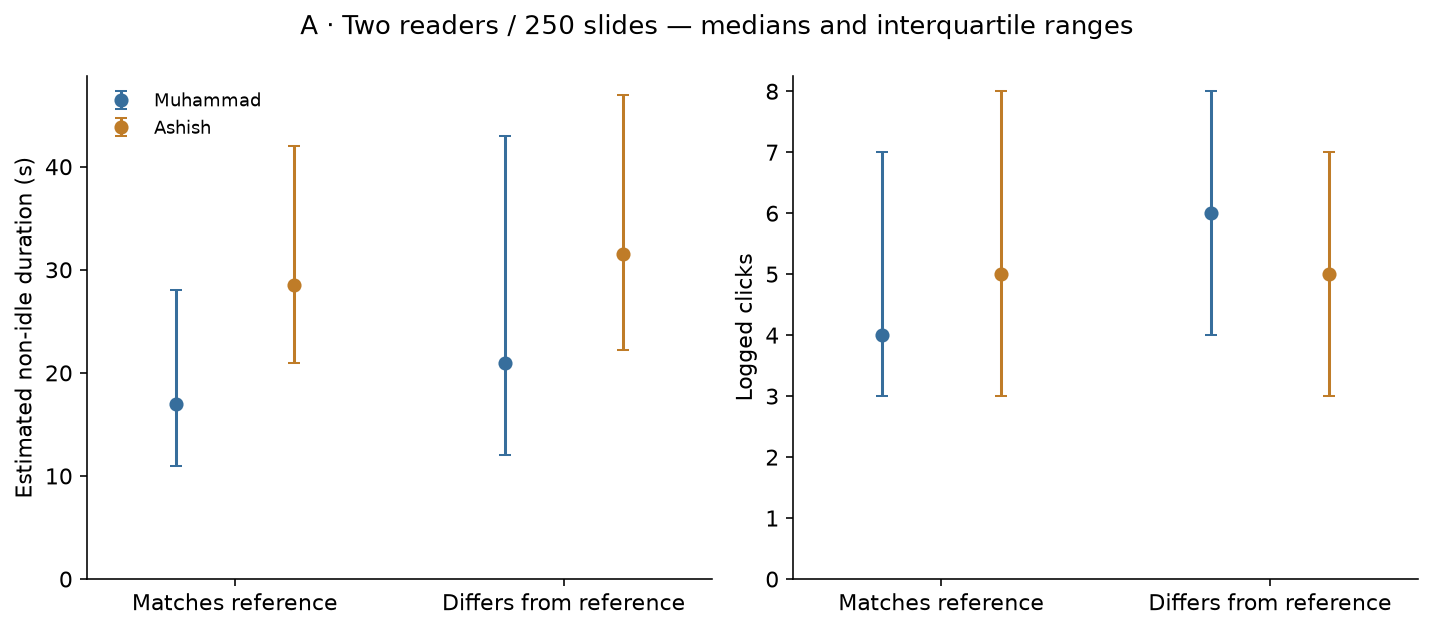

**B · Three readers / 180 slides — exact reference agreement**

Reader,Match / mismatch N,"Time medians, match / mismatch (s)","Click medians, match / mismatch","Max-zoom medians, match / mismatch"
Muhammad Aslam,123 / 57,17 / 21,4 / 6,5 / 10
Ashish Bansal,128 / 52,28 / 32,5 / 6,5 / 5
Iftikhar Rana,126 / 54,22 / 30,7 / 10,10 / 10


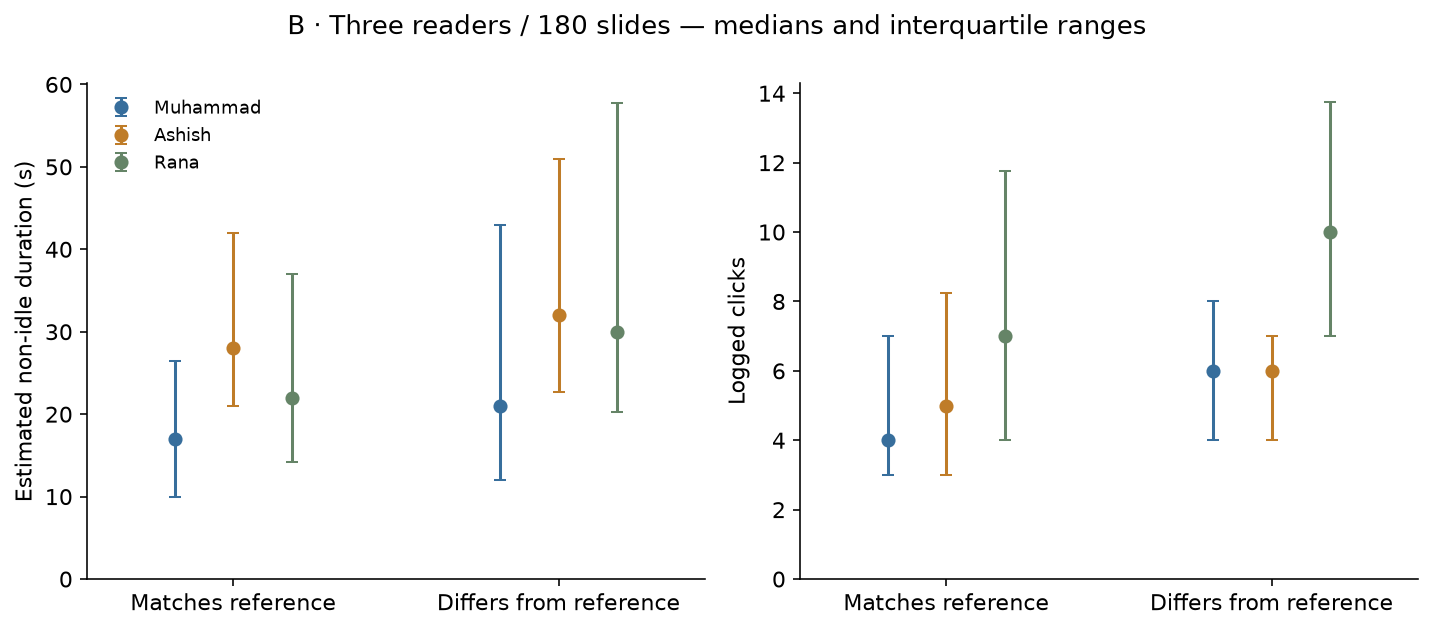

In [62]:
ra_q8_rows=[]
for ra_key in ["A","B"]:
    ra_q8_rows.extend(ra_group_rows(ra_key,"exact_match",[True,False]))
    rows=[]
    for ra_user in cohort_readers[ra_key]:
        d=ra_cohorts[ra_key][ra_cohorts[ra_key].user_id.eq(ra_user)]
        match=d[d.exact_match];diff=d[~d.exact_match]
        rows.append({"Reader":READER_NAMES[ra_user],"Match / mismatch N":f"{len(match)} / {len(diff)}",
            "Time medians, match / mismatch (s)":f"{match.nonidle_s_30.median():g} / {diff.nonidle_s_30.median():g}",
            "Click medians, match / mismatch":f"{match.n_cell_click.median():g} / {diff.n_cell_click.median():g}",
            "Max-zoom medians, match / mismatch":f"{match.max_zoom.median():g} / {diff.max_zoom.median():g}"})
    display(Markdown("**"+GROUP_NAMES[ra_key]+" — exact reference agreement**"));show_table(pd.DataFrame(rows))
    fig,axes=plt.subplots(1,2,figsize=(10,4.4))
    offsets=np.linspace(-.18,.18,len(cohort_readers[ra_key]))
    for j,ra_user in enumerate(cohort_readers[ra_key]):
        d=ra_cohorts[ra_key][ra_cohorts[ra_key].user_id.eq(ra_user)]
        for i,outcome in enumerate([True,False]):
            g=d[d.exact_match.eq(outcome)]
            for ax,metric in zip(axes,["nonidle_s_30","n_cell_click"]):
                q=g[metric].quantile([.25,.5,.75])
                ax.errorbar(i+offsets[j],q.loc[.5],yerr=[[q.loc[.5]-q.loc[.25]],[q.loc[.75]-q.loc[.5]]],
                    fmt="o",capsize=3,color=BH_READER_COLOURS[ra_user],
                    label=FIRST_NAMES[ra_user] if i==0 else None)
    for ax in axes:
        ax.set(xticks=[0,1],xticklabels=["Matches reference","Differs from reference"],xlim=(-.45,1.45))
        ax.set_ylim(bottom=0)
    axes[0].set_ylabel("Estimated non-idle duration (s)");axes[1].set_ylabel("Logged clicks")
    axes[0].legend(frameon=False,fontsize=9)
    fig.suptitle(GROUP_NAMES[ra_key]+" — medians and interquartile ranges",fontsize=13)
    fig.tight_layout();show_figure(fig)
ra_q8=pd.DataFrame(ra_q8_rows)

### 8.1 Check whether the overall pattern holds within reference class

An overall mismatch group can contain more high-grade images than the matching group. Compare matches and mismatches separately within each reference class before describing a universal relationship.

The high-grade table defines **undercalled** as a reference-high image labelled low-grade or non-neoplastic, and gives both counts. Groups with very few observations remain case descriptions.

In [63]:
ra_q8_class_rows=[];ra_q8_high_rows=[]
for ra_key in ["A","B"]:
    for ra_user in cohort_readers[ra_key]:
        d=ra_cohorts[ra_key][ra_cohorts[ra_key].user_id.eq(ra_user)]
        for ra_class in CLASSES:
            for status in [True,False]:
                g=d[d.reference.eq(ra_class)&d.exact_match.eq(status)]
                ra_q8_class_rows.append({"Cohort":ra_key,"Reader":READER_NAMES[ra_user],"Reference":ra_class,
                    "Outcome":"Match" if status else "Mismatch","N":len(g),
                    "Duration: median [P25,P75] s":bh_summary(g.nonidle_s_30),
                    "Clicks: median [P25,P75]":bh_summary(g.n_cell_click),
                    "Offset valid N":int(g.median_click_offset.notna().sum()),
                    "Offset median":float(g.median_click_offset.median()) if g.median_click_offset.notna().any() else np.nan})
        high=d[d.reference.eq("high-grade")];correct=high[high.exact_match];under=high[~high.exact_match]
        ra_q8_high_rows.append({"Cohort":ra_key,"Reader":READER_NAMES[ra_user],
            "Correct / undercalled N":f"{len(correct)} / {len(under)}",
            "Undercalls: low / non-neoplastic":f"{int(under.diagnosis.eq('low-grade').sum())} / {int(under.diagnosis.eq('non-neoplastic').sum())}",
            "Time medians correct / under (s)":f"{correct.nonidle_s_30.median():g} / {under.nonidle_s_30.median():g}",
            "Click medians correct / under":f"{correct.n_cell_click.median():g} / {under.n_cell_click.median():g}"})
    show_table(pd.DataFrame([r for r in ra_q8_high_rows if r["Cohort"]==ra_key]).drop(columns="Cohort"))
    display(HTML("<details><summary>All reference-class strata — "+escape(GROUP_NAMES[ra_key])+"</summary>"+
        pd.DataFrame([r for r in ra_q8_class_rows if r["Cohort"]==ra_key]).drop(columns="Cohort").to_html(index=False,border=0,na_rep="Not measurable")+"</details>"))
ra_ash_high=ra_cohorts["B"][ra_cohorts["B"].user_id.eq("ashish.bansal")&ra_cohorts["B"].reference.eq("high-grade")]
display(Markdown("**A counterexample to a universal rule:** on the shared high-grade slides, Ashish's median duration is "
    f"**{ra_ash_high.loc[ra_ash_high.exact_match,'nonidle_s_30'].median():g} s** for exact matches and "
    f"**{ra_ash_high.loc[~ra_ash_high.exact_match,'nonidle_s_30'].median():g} s** for undercalls. "
    "The class-specific direction differs from his aggregate result."))

Reader,Correct / undercalled N,Undercalls: low / non-neoplastic,Time medians correct / under (s),Click medians correct / under
Muhammad Aslam,34 / 50,50 / 0,9 / 18,3 / 5.5
Ashish Bansal,40 / 44,44 / 0,37 / 31.5,6 / 5


Reader,Reference,Outcome,N,"Duration: median [P25,P75] s","Clicks: median [P25,P75]",Offset valid N,Offset median
Muhammad Aslam,non-neoplastic,Match,54,"20.0 [14.0, 33.5]","6.0 [5.0, 9.0]",54,0.227766
Muhammad Aslam,non-neoplastic,Mismatch,17,"28.0 [12.0, 58.0]","5.0 [3.0, 6.0]",17,0.211521
Muhammad Aslam,low-grade,Match,75,"17.0 [11.0, 25.0]","4.0 [3.0, 5.5]",75,0.228632
Muhammad Aslam,low-grade,Mismatch,20,"24.5 [15.0, 48.0]","7.0 [5.0, 9.0]",20,0.157215
Muhammad Aslam,high-grade,Match,34,"9.0 [6.2, 21.8]","3.0 [1.0, 4.0]",34,0.158754
Muhammad Aslam,high-grade,Mismatch,50,"18.0 [12.0, 37.0]","5.5 [4.0, 8.0]",50,0.190933
Ashish Bansal,non-neoplastic,Match,60,"32.5 [22.8, 42.8]","6.0 [4.0, 9.0]",59,0.219677
Ashish Bansal,non-neoplastic,Mismatch,11,"34.0 [22.0, 44.5]","5.0 [3.0, 7.0]",11,0.259294
Ashish Bansal,low-grade,Match,76,"24.0 [16.0, 33.0]","4.0 [2.0, 6.0]",75,0.203586
Ashish Bansal,low-grade,Mismatch,19,"29.0 [24.0, 49.5]","6.0 [4.5, 10.0]",19,0.206050


Reader,Correct / undercalled N,Undercalls: low / non-neoplastic,Time medians correct / under (s),Click medians correct / under
Muhammad Aslam,29 / 31,31 / 0,9 / 17,3 / 5
Ashish Bansal,31 / 29,29 / 0,36 / 33,6 / 5
Iftikhar Rana,33 / 27,26 / 1,19 / 46,6 / 10


Reader,Reference,Outcome,N,"Duration: median [P25,P75] s","Clicks: median [P25,P75]",Offset valid N,Offset median
Muhammad Aslam,non-neoplastic,Match,39,"18.0 [13.5, 26.5]","6.0 [4.0, 9.0]",39,0.210674
Muhammad Aslam,non-neoplastic,Mismatch,11,"37.0 [12.0, 60.5]","5.0 [3.5, 6.0]",11,0.199308
Muhammad Aslam,low-grade,Match,55,"17.0 [10.5, 25.0]","4.0 [3.0, 5.5]",55,0.226444
Muhammad Aslam,low-grade,Mismatch,15,"40.0 [20.5, 51.5]","8.0 [6.5, 9.0]",15,0.131837
Muhammad Aslam,high-grade,Match,29,"9.0 [6.0, 22.0]","3.0 [1.0, 4.0]",29,0.159308
Muhammad Aslam,high-grade,Mismatch,31,"17.0 [11.0, 32.0]","5.0 [4.0, 7.5]",31,0.196544
Ashish Bansal,non-neoplastic,Match,43,"27.0 [21.0, 39.0]","6.0 [4.0, 9.0]",42,0.215102
Ashish Bansal,non-neoplastic,Mismatch,7,"32.0 [22.0, 54.0]","7.0 [3.5, 8.0]",7,0.272727
Ashish Bansal,low-grade,Match,54,"24.5 [21.0, 33.8]","4.0 [2.0, 6.0]",53,0.195951
Ashish Bansal,low-grade,Mismatch,16,"30.5 [22.8, 51.2]","7.0 [5.0, 11.5]",16,0.150164


**A counterexample to a universal rule:** on the shared high-grade slides, Ashish's median duration is **36 s** for exact matches and **33 s** for undercalls. The class-specific direction differs from his aggregate result.

### 8.2 Describe binary false-positive and false-negative cases

TP/TN/FP/FN use the non-neoplastic versus low/high-grade grouping from Question 1. Show counts alongside behaviour. These selected small subgroups cannot establish whether a reader missed tissue, interpreted it differently, or disagreed with an imperfect reference.

In [64]:
ra_q8_binary_rows=[]
for ra_key in ["A","B"]:
    for ra_user in cohort_readers[ra_key]:
        d=ra_cohorts[ra_key][ra_cohorts[ra_key].user_id.eq(ra_user)]
        for outcome in ["TN","FP","FN","TP"]:
            g=d[d.binary_outcome.eq(outcome)]
            ra_q8_binary_rows.append({"Cohort":ra_key,"Reader":READER_NAMES[ra_user],"Outcome":outcome,"N":len(g),
                "Duration: median [P25,P75] s":bh_summary(g.nonidle_s_30),
                "Clicks: median [P25,P75]":bh_summary(g.n_cell_click),
                "Maximum zoom: median":float(g.max_zoom.median()) if len(g) else np.nan})
    display(HTML("<details><summary>Binary outcome behaviour — "+escape(GROUP_NAMES[ra_key])+"</summary>"+
        pd.DataFrame([r for r in ra_q8_binary_rows if r["Cohort"]==ra_key]).drop(columns="Cohort").to_html(index=False,border=0)+"</details>"))

Reader,Outcome,N,"Duration: median [P25,P75] s","Clicks: median [P25,P75]",Maximum zoom: median
Muhammad Aslam,TN,54,"20.0 [14.0, 33.5]","6.0 [5.0, 9.0]",5.0
Muhammad Aslam,FP,17,"28.0 [12.0, 58.0]","5.0 [3.0, 6.0]",10.0
Muhammad Aslam,FN,16,"28.0 [19.2, 51.2]","7.0 [6.8, 9.0]",10.0
Muhammad Aslam,TP,163,"17.0 [10.0, 29.0]","4.0 [3.0, 6.0]",5.0
Ashish Bansal,TN,60,"32.5 [22.8, 42.8]","6.0 [4.0, 9.0]",5.0
Ashish Bansal,FP,11,"34.0 [22.0, 44.5]","5.0 [3.0, 7.0]",5.0
Ashish Bansal,FN,18,"29.0 [24.0, 50.2]","6.0 [4.2, 8.8]",5.0
Ashish Bansal,TP,161,"29.0 [21.0, 43.0]","5.0 [3.0, 7.0]",5.0


Reader,Outcome,N,"Duration: median [P25,P75] s","Clicks: median [P25,P75]",Maximum zoom: median
Muhammad Aslam,TN,39,"18.0 [13.5, 26.5]","6.0 [4.0, 9.0]",5.0
Muhammad Aslam,FP,11,"37.0 [12.0, 60.5]","5.0 [3.5, 6.0]",10.0
Muhammad Aslam,FN,13,"45.0 [21.0, 52.0]","8.0 [7.0, 9.0]",10.0
Muhammad Aslam,TP,117,"16.0 [9.0, 28.0]","4.0 [3.0, 6.0]",5.0
Ashish Bansal,TN,43,"27.0 [21.0, 39.0]","6.0 [4.0, 9.0]",5.0
Ashish Bansal,FP,7,"32.0 [22.0, 54.0]","7.0 [3.5, 8.0]",10.0
Ashish Bansal,FN,15,"29.0 [21.5, 51.5]","7.0 [5.0, 10.0]",10.0
Ashish Bansal,TP,115,"32.0 [22.0, 44.5]","5.0 [3.0, 7.0]",5.0
Iftikhar Rana,TN,40,"21.5 [15.8, 29.8]","8.0 [5.0, 11.2]",5.0
Iftikhar Rana,FP,10,"18.0 [11.8, 28.2]","8.0 [6.0, 9.8]",20.0


### 8.3 Reference agreement at different maximum magnifications

Divide examinations into three **mutually exclusive** groups: maximum ≤5×, maximum 10×, and maximum ≥20×. Calculate agreement within each group; the labels above the bars are matches/denominator. Also show the reference-class composition of those groups.

Readers selected their magnification in response to each image. Different agreement percentages therefore cannot estimate what would happen if the same reader were forced to use more or less magnification.

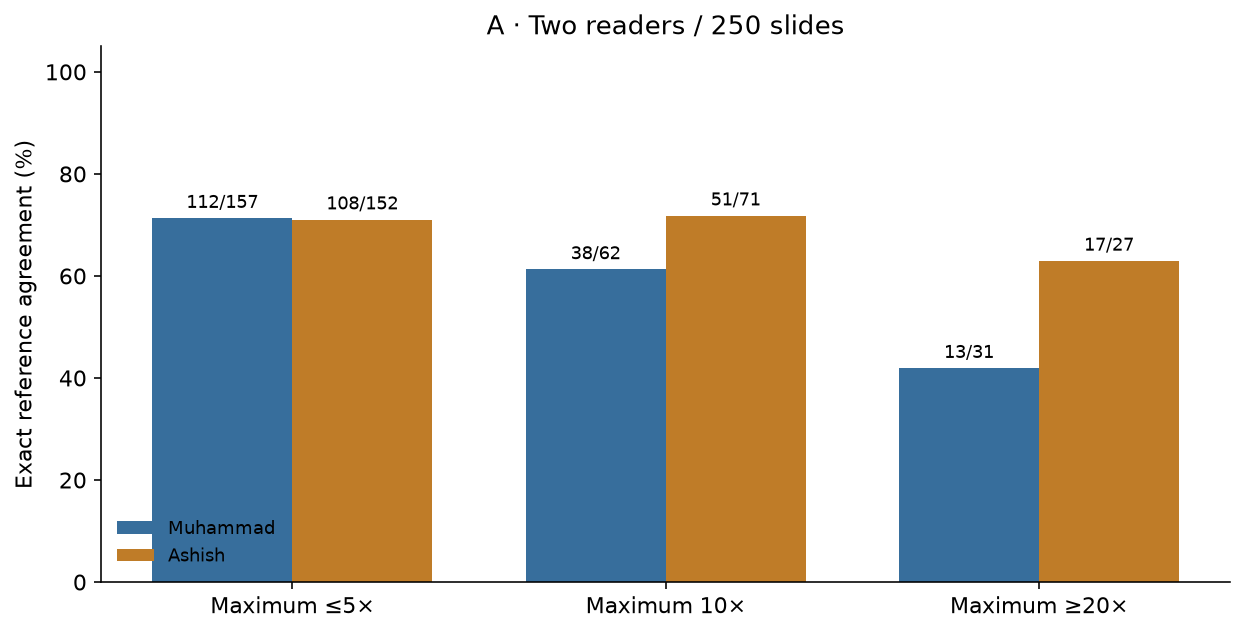

Reader,Maximum zoom,Group N,Exact matches,Combined matches,non-neoplastic,low-grade,high-grade
Muhammad Aslam,≤5×,157,112,143,38,64,55
Muhammad Aslam,10×,62,38,50,21,25,16
Muhammad Aslam,≥20×,31,13,24,12,6,13
Ashish Bansal,≤5×,152,108,136,44,63,45
Ashish Bansal,10×,71,51,63,19,24,28
Ashish Bansal,≥20×,27,17,22,8,8,11


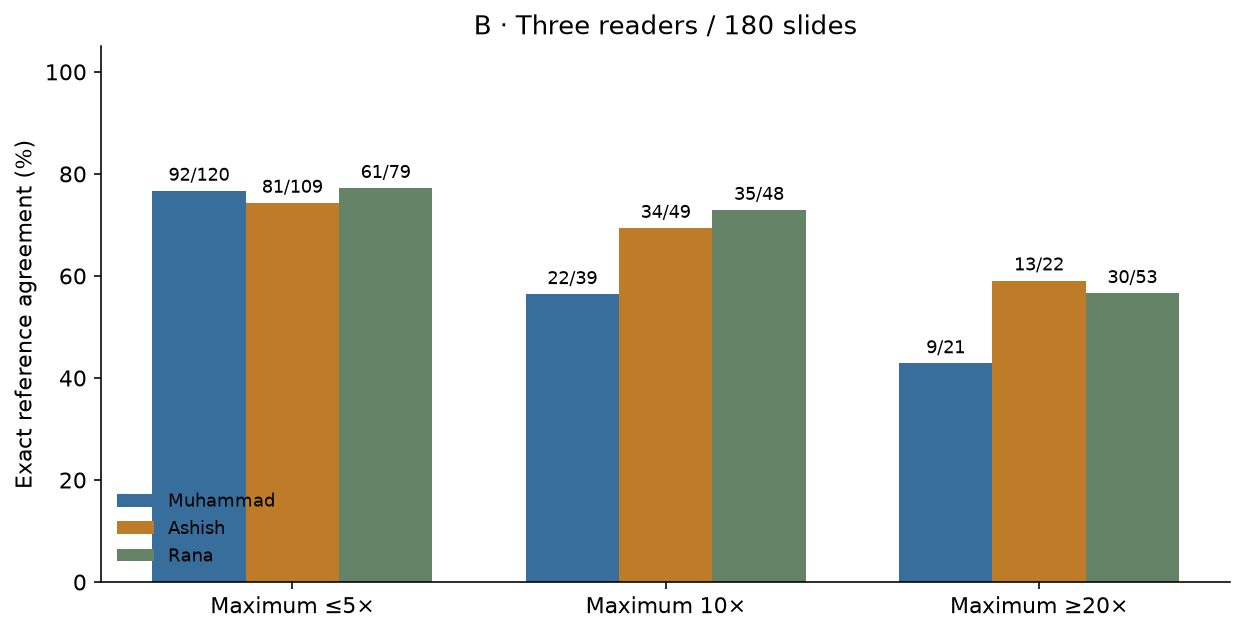

Reader,Maximum zoom,Group N,Exact matches,Combined matches,non-neoplastic,low-grade,high-grade
Muhammad Aslam,≤5×,120,92,109,30,50,40
Muhammad Aslam,10×,39,22,31,13,15,11
Muhammad Aslam,≥20×,21,9,16,7,5,9
Ashish Bansal,≤5×,109,81,99,32,46,31
Ashish Bansal,10×,49,34,42,13,17,19
Ashish Bansal,≥20×,22,13,17,5,7,10
Iftikhar Rana,≤5×,79,61,70,24,44,11
Iftikhar Rana,10×,48,35,44,13,11,24
Iftikhar Rana,≥20×,53,30,43,13,15,25


In [65]:
ra_q8_zoom_rows=[]
for ra_key in ["A","B"]:
    fig,ax=plt.subplots(figsize=(8.7,4.5))
    readers=cohort_readers[ra_key];width=.75/len(readers)
    for j,ra_user in enumerate(readers):
        d=ra_cohorts[ra_key][ra_cohorts[ra_key].user_id.eq(ra_user)]
        bands=[d.max_zoom.le(5),d.max_zoom.eq(10),d.max_zoom.ge(20)]
        assert sum(int(mask.sum()) for mask in bands)==len(d)
        for i,(band,mask) in enumerate(zip(["≤5×","10×","≥20×"],bands)):
            g=d[mask];matches=int(g.exact_match.sum());n=len(g)
            row={"cohort":ra_key,"reader":ra_user,"band":band,"n":n,"exact_matches":matches,
                 "binary_matches":int(g.binary_match.sum()),"agreement":matches/n if n else np.nan,
                 **{c:int(g.reference.eq(c).sum()) for c in CLASSES}}
            ra_q8_zoom_rows.append(row)
            x=i+(j-(len(readers)-1)/2)*width
            ax.bar(x,100*matches/n if n else 0,width=width,color=BH_READER_COLOURS[ra_user],
                   label=FIRST_NAMES[ra_user] if i==0 else None)
            if n:ax.text(x,100*matches/n+2,f"{matches}/{n}",ha="center",fontsize=9)
    ax.set(xticks=[0,1,2],xticklabels=["Maximum ≤5×","Maximum 10×","Maximum ≥20×"],
           ylim=(0,105),ylabel="Exact reference agreement (%)",title=GROUP_NAMES[ra_key])
    ax.legend(frameon=False,loc="lower left",fontsize=9)
    fig.tight_layout();show_figure(fig)
    rows=pd.DataFrame([r for r in ra_q8_zoom_rows if r["cohort"]==ra_key])
    rows["Reader"]=rows.reader.map(READER_NAMES)
    show_table(rows[["Reader","band","n","exact_matches","binary_matches",*CLASSES]].rename(
        columns={"band":"Maximum zoom","n":"Group N","exact_matches":"Exact matches","binary_matches":"Combined matches"}))
ra_q8_zoom=pd.DataFrame(ra_q8_zoom_rows)

### Question 8 — answer and limits

In the aggregate, reference-mismatching examinations have longer median logged duration for each reader/cohort. The relationship is not uniform within reference classes. The zoom groups also differ in which cases they contain.

The observations support an association between recorded behaviour and reference agreement. They do **not** establish that deeper zoom causes mistakes, that spending more time would improve a diagnosis, or that disagreements are interpretive rather than attentional. Slide difficulty, case composition, reader judgement and reference uncertainty remain possible explanations.

In [66]:
for ra_key in ["A","B"]:
    for ra_user in cohort_readers[ra_key]:
        d=ra_cohorts[ra_key][ra_cohorts[ra_key].user_id.eq(ra_user)]
        assert len(d)==len(cohort_ids[ra_key])
        assert int(d.exact_match.sum())==statistics[ra_key][ra_user]["exact"]
        assert int(d.binary_match.sum())==statistics[ra_key][ra_user]["binary"]
        assert d.reference.value_counts().reindex(CLASSES).tolist()==reference.loc[cohort_ids[ra_key]].value_counts().reindex(CLASSES).tolist()
        z=ra_q8_zoom[(ra_q8_zoom.cohort==ra_key)&(ra_q8_zoom.reader==ra_user)]
        assert int(z.n.sum())==len(d)
        assert int(z.exact_matches.sum())==int(d.exact_match.sum())
        assert int(z.binary_matches.sum())==int(d.binary_match.sum())
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()==input_sha256
print("PASS: Q6/Q8 class membership, one-row-per-reader-slide joins, Q1 outcome counts and complete mutually exclusive zoom groups.")

PASS: Q6/Q8 class membership, one-row-per-reader-slide joins, Q1 outcome counts and complete mutually exclusive zoom groups.


<a id="question-9"></a>

# Question 9 — Do recorded diagnoses change during a reading or on a later attempt?

**Purpose.** Separate a change while choosing a label from a new examination on a later attempt. Multiple log rows carrying one label are not multiple decisions. A return to a slide without a label cannot establish whether a diagnosis was stable.

**Method.** Preserve every attempt in an audit table. Within each labelled attempt, read explicit `label_select` and labelled `slide_next` events in timestamp/CSV-row order up to the diagnosis retained by Question 0. Collapse consecutive identical labels. Count the changes between the remaining labels; a low→high→low sequence has two changes even though its endpoints agree. Primary summaries use the same latest labelled attempt as Questions 1–8, separately for A and B. We also compare the first explicit label selection with the retained diagnosis and with the reference. These are recorded UI choices, not a record of every thought or a confidence measure.

In [67]:
q9_attempt_rows=[]
for q9_keys,q9_g in events.loc[events.user_id.isin(THREE)].groupby(view_keys,sort=False):
    q9_g=q9_g.sort_values(["timestamp","source_row"],kind="stable")
    q9_meta=views.set_index(view_keys).loc[q9_keys]
    q9_labelled=pd.notna(q9_meta.diagnosis)
    q9_kept=q9_g.loc[q9_g.source_row.le(q9_meta.label_row)] if q9_labelled else q9_g
    q9_choices=q9_kept.loc[q9_kept.event.isin(["label_select","slide_next"]) & q9_kept.label.ne("")]
    q9_sequence=q9_choices.loc[q9_choices.label.ne(q9_choices.label.shift())]
    q9_selects=q9_kept.loc[q9_kept.event.eq("label_select") & q9_kept.label.ne("")]
    q9_first=q9_selects.iloc[0] if len(q9_selects) else None
    q9_prefix=q9_kept.loc[q9_kept.source_row.le(q9_first.source_row)] if q9_first is not None else q9_kept.iloc[:0]
    # Latency is only shown for an uninterrupted recorded prefix with an observed load.
    q9_startup=q9_prefix.event.isin(BH_LOAD_EVENTS)
    q9_startup_events=q9_prefix.loc[q9_startup,"event"].tolist()
    q9_single_startup=(q9_startup_events in [["slide_load"],["app_start","slide_load"]]
        and q9_prefix.event.iloc[:len(q9_startup_events)].isin(BH_LOAD_EVENTS).all())
    q9_timing_ok=(len(q9_prefix)>0 and q9_prefix.iloc[0].event in BH_LOAD_EVENTS
        and q9_single_startup
        and not q9_prefix.event.isin(["idle_start","idle_end"]).any()
        and not q9_prefix.timestamp.diff().dt.total_seconds().gt(BH_GAP_BREAK).any())
    q9_attempt_rows.append({**dict(zip(view_keys,q9_keys)),"reference":q9_meta.reference,
        "first_timestamp":q9_meta.first_timestamp,"last_timestamp":q9_meta.last_timestamp,
        "label_row":int(q9_meta.label_row),"label_timestamp":q9_meta.label_timestamp,
        "diagnosis":q9_meta.diagnosis,"labelled":q9_labelled,
        "label_select_records":len(q9_selects),"distinct_label_states":len(q9_sequence),
        "label_transitions":max(0,len(q9_sequence)-1),
        "first_selection":q9_first.label if q9_first is not None else None,
        "first_selection_row":int(q9_first.source_row) if q9_first is not None else -1,
        "first_selection_latency_s":float((q9_first.timestamp-q9_prefix.iloc[0].timestamp).total_seconds()) if q9_timing_ok else np.nan,
        "choice_sequence":" → ".join(q9_sequence.label.tolist())})
q9_attempts=pd.DataFrame(q9_attempt_rows)
q9_primary=q9_attempts.merge(diagnoses.loc[diagnoses.user_id.isin(THREE),view_keys+["label_row"]],
    on=view_keys+["label_row"],validate="one_to_one")
assert len(q9_primary)==680 and q9_primary.labelled.all()
q9_primary["first_matches_reference"]=q9_primary.first_selection.eq(q9_primary.reference)
q9_primary["final_matches_reference"]=q9_primary.diagnosis.eq(q9_primary.reference)
q9_primary["first_final_changed"]=q9_primary.first_selection.notna() & q9_primary.first_selection.ne(q9_primary.diagnosis)
q9_summary_rows=[]
for q9_key in ["A","B"]:
    for q9_u in cohort_readers[q9_key]:
        q9_d=q9_primary.loc[q9_primary.user_id.eq(q9_u)&q9_primary.slide_id.isin(cohort_ids[q9_key])]
        q9_s=q9_d.loc[q9_d.first_selection.notna()]
        q9_summary_rows.append({"Cohort":q9_key,"Reader":READER_NAMES[q9_u],"Retained attempts":len(q9_d),
            "Any label change":ratio_text(int(q9_d.label_transitions.gt(0).sum()),len(q9_d)),
            "Total label transitions":int(q9_d.label_transitions.sum()),
            "First selection available":len(q9_s),
            "First differs from final":ratio_text(int(q9_s.first_final_changed.sum()),len(q9_s)),
            "Latency-valid attempts":int(q9_d.first_selection_latency_s.notna().sum()),
            "First-selection latency: median [P25,P75] s":bh_summary(q9_d.first_selection_latency_s)})
    display(Markdown("**"+GROUP_NAMES[q9_key]+"**"))
    show_table(pd.DataFrame([q9_r for q9_r in q9_summary_rows if q9_r["Cohort"]==q9_key]).drop(columns="Cohort"))

**A · Two readers / 250 slides**

Reader,Retained attempts,Any label change,Total label transitions,First selection available,First differs from final,Latency-valid attempts,"First-selection latency: median [P25,P75] s"
Muhammad Aslam,250,8/250 (3.2%),8,250,8/250 (3.2%),212,"15.0 [10.0, 22.0]"
Ashish Bansal,250,1/250 (0.4%),1,250,1/250 (0.4%),219,"25.0 [18.0, 36.0]"


**B · Three readers / 180 slides**

Reader,Retained attempts,Any label change,Total label transitions,First selection available,First differs from final,Latency-valid attempts,"First-selection latency: median [P25,P75] s"
Muhammad Aslam,180,5/180 (2.8%),5,180,5/180 (2.8%),153,"15.0 [9.0, 21.0]"
Ashish Bansal,180,0/180 (0.0%),0,180,0/180 (0.0%),158,"25.5 [18.0, 34.0]"
Iftikhar Rana,180,1/180 (0.6%),1,180,1/180 (0.6%),156,"20.0 [13.0, 32.2]"


### 9.1 Do the revisions move toward or away from the reference?

The four categories below compare each attempt's **first explicit selection** and retained diagnosis. “Disagreement both times” includes changing from one non-reference class to the other. Counts sum to the first-selection denominator, not to the number of transitions. The timing estimate above requires one initial `slide_load`, optionally preceded immediately by `app_start`; both constitute one startup. It excludes later startup/load markers, a logged idle marker or a >60-second event gap. It is elapsed time from the first startup record in a restricted prefix, not cognitive decision time. Timestamps have one-second resolution, so zero seconds is possible.

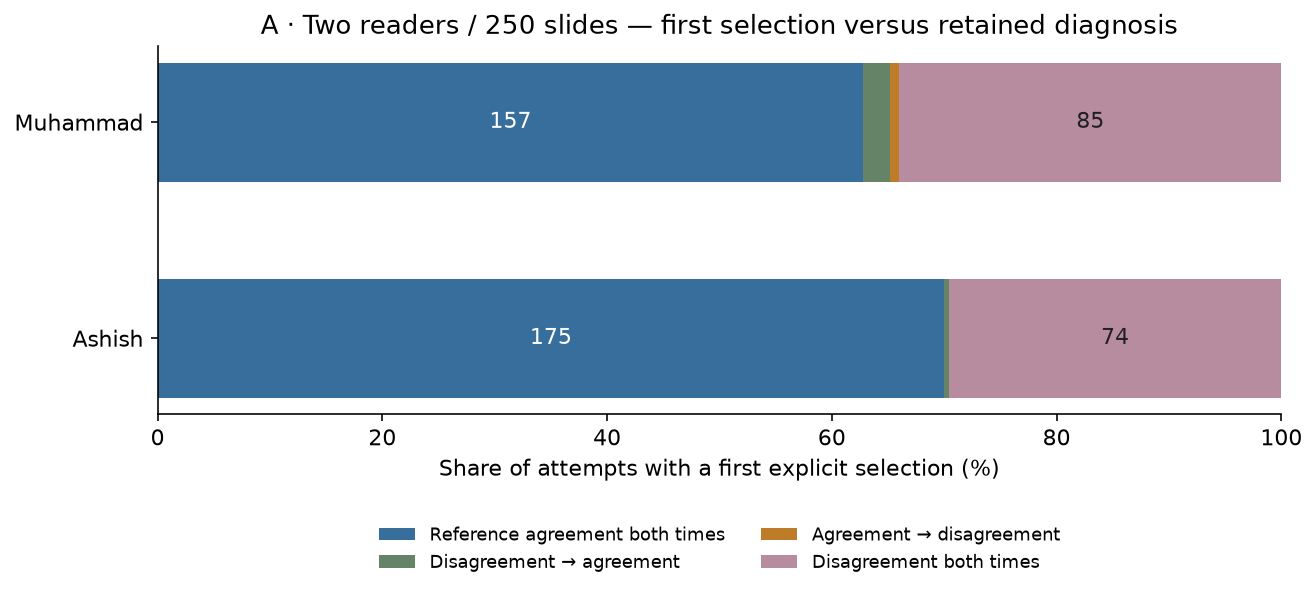

Reader,n,Reference agreement both times,Disagreement → agreement,Agreement → disagreement,Disagreement both times
Muhammad Aslam,250,157,6,2,85
Ashish Bansal,250,175,1,0,74


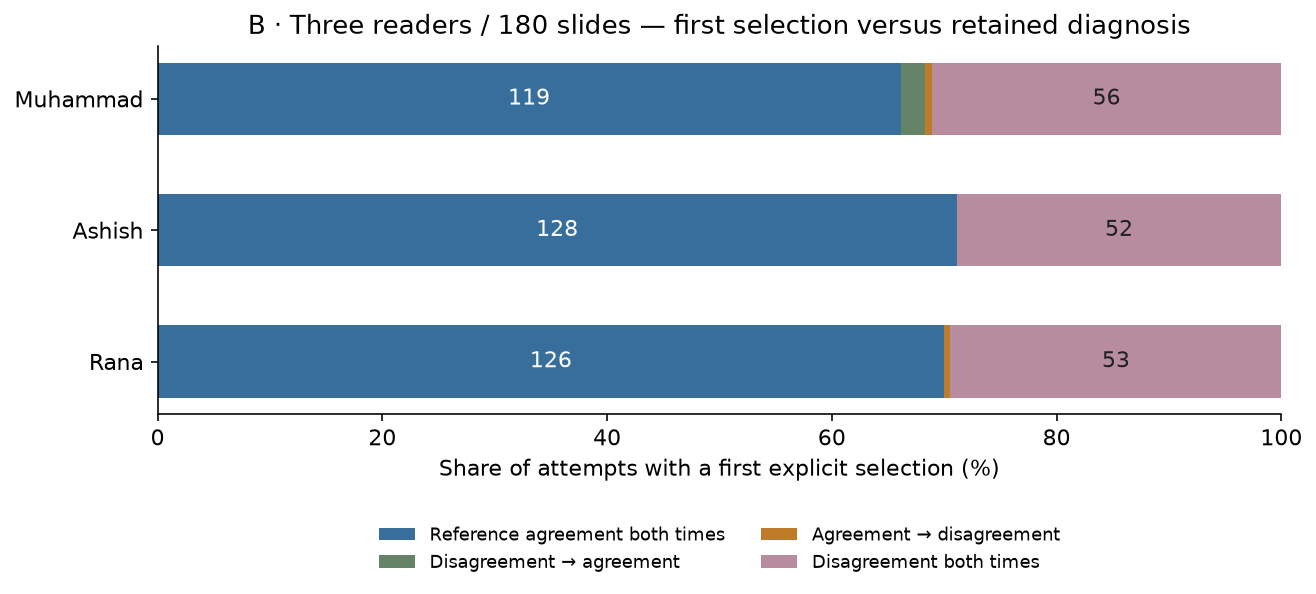

Reader,n,Reference agreement both times,Disagreement → agreement,Agreement → disagreement,Disagreement both times
Muhammad Aslam,180,119,4,1,56
Ashish Bansal,180,128,0,0,52
Iftikhar Rana,180,126,0,1,53


Reader,slide_id,choice_sequence,reference,label_transitions
Muhammad Aslam,CRC_3445,low-grade → non-neoplastic,non-neoplastic,1
Muhammad Aslam,CRC_2807,non-neoplastic → high-grade,high-grade,1
Muhammad Aslam,CRC_4427,low-grade → non-neoplastic,non-neoplastic,1
Muhammad Aslam,CRC_2634,high-grade → low-grade,high-grade,1
Muhammad Aslam,CRC_4318,low-grade → non-neoplastic,non-neoplastic,1
Muhammad Aslam,CRC_1083,low-grade → non-neoplastic,non-neoplastic,1
Muhammad Aslam,CRC_2525,high-grade → low-grade,high-grade,1
Muhammad Aslam,CRC_0492,low-grade → non-neoplastic,non-neoplastic,1
Ashish Bansal,CRC_0135,low-grade → non-neoplastic,non-neoplastic,1
Iftikhar Rana,CRC_2126,high-grade → low-grade,high-grade,1


In [68]:
q9_outcome_rows=[]
q9_outcome_names=["Reference agreement both times","Disagreement → agreement","Agreement → disagreement","Disagreement both times"]
q9_outcome_colours=["#376E9C","#658467","#BF7C28","#B88C9F"]
for q9_key in ["A","B"]:
    q9_fig,q9_ax=plt.subplots(figsize=(10,3.3))
    for q9_i,q9_u in enumerate(cohort_readers[q9_key]):
        q9_s=q9_primary.loc[q9_primary.user_id.eq(q9_u)&q9_primary.slide_id.isin(cohort_ids[q9_key])&q9_primary.first_selection.notna()]
        q9_a=q9_s.first_matches_reference;q9_b=q9_s.final_matches_reference
        q9_counts=[int((q9_a&q9_b).sum()),int((~q9_a&q9_b).sum()),int((q9_a&~q9_b).sum()),int((~q9_a&~q9_b).sum())]
        assert sum(q9_counts)==len(q9_s)
        q9_outcome_rows.append({"Cohort":q9_key,"Reader":READER_NAMES[q9_u],"n":len(q9_s),**dict(zip(q9_outcome_names,q9_counts))})
        q9_left=0
        for q9_j,(q9_count,q9_colour) in enumerate(zip(q9_counts,q9_outcome_colours)):
            q9_width=100*q9_count/len(q9_s)
            q9_ax.barh(q9_i,q9_width,left=q9_left,color=q9_colour,label=q9_outcome_names[q9_j] if q9_i==0 else None,height=.55)
            if q9_width>=6:q9_ax.text(q9_left+q9_width/2,q9_i,str(q9_count),ha="center",va="center",color="white" if q9_j==0 else "#202020")
            q9_left+=q9_width
    q9_ax.set(yticks=range(len(cohort_readers[q9_key])),yticklabels=[FIRST_NAMES[q9_u] for q9_u in cohort_readers[q9_key]],
        xlim=(0,100),xlabel="Share of attempts with a first explicit selection (%)",title=GROUP_NAMES[q9_key]+" — first selection versus retained diagnosis")
    q9_ax.invert_yaxis();q9_ax.legend(loc="upper center",bbox_to_anchor=(.5,-.26),ncol=2,frameon=False,fontsize=9)
    show_figure(q9_fig)
    show_table(pd.DataFrame([q9_r for q9_r in q9_outcome_rows if q9_r["Cohort"]==q9_key]).drop(columns="Cohort"))
q9_changed=q9_primary.loc[q9_primary.label_transitions.gt(0),["user_id","slide_id","choice_sequence","reference","label_transitions"]].copy()
q9_changed["Reader"]=q9_changed.user_id.map(READER_NAMES)
display(HTML("<details><summary>Inspect every retained attempt with a label transition</summary>"+
    q9_changed[["Reader","slide_id","choice_sequence","reference","label_transitions"]].to_html(index=False,border=0,escape=True)+"</details>"))

### 9.2 Later attempts: distinguish interrupted work from a labelled re-reading

The audit counts all attempts on each cohort's slides, including unlabelled attempts. A paired re-reading requires at least **two labelled attempts for the same reader and slide**. For each such slide, compare the earliest and latest labelled attempt, retain the interval between their diagnoses, and describe their click count, maximum magnification and estimated non-idle duration using Question 4's method. These observational returns were not a planned blinded repeat-reading experiment.

In [69]:
q9_repeat_rows=[];q9_pair_rows=[]
for q9_key in ["A","B"]:
    for q9_u in cohort_readers[q9_key]:
        q9_v=q9_attempts.loc[q9_attempts.user_id.eq(q9_u)&q9_attempts.slide_id.isin(cohort_ids[q9_key])]
        q9_grouped=q9_v.groupby("slide_id").agg(attempts=("attempt","size"),labelled=("labelled","sum"))
        q9_repeat_rows.append({"Cohort":q9_key,"Reader":READER_NAMES[q9_u],"Slides":len(q9_grouped),
            "All attempts":len(q9_v),"Unlabelled attempts":int((~q9_v.labelled).sum()),
            "Slides with >1 attempt":int(q9_grouped.attempts.gt(1).sum()),
            "Slides with ≥2 labelled attempts":int(q9_grouped.labelled.ge(2).sum())})
    display(Markdown("**"+GROUP_NAMES[q9_key]+"**"))
    show_table(pd.DataFrame([q9_r for q9_r in q9_repeat_rows if q9_r["Cohort"]==q9_key]).drop(columns="Cohort"))
for (q9_u,q9_slide),q9_v in q9_attempts.loc[q9_attempts.labelled].groupby(["user_id","slide_id"]):
    if len(q9_v)<2:continue
    q9_v=q9_v.sort_values(["label_timestamp","label_row"],kind="stable")
    q9_pair={"Reader":READER_NAMES[q9_u],"Slide":q9_slide,"Labelled attempts":len(q9_v),
        "Reference":q9_v.reference.iloc[0],"Days between labels":round((q9_v.label_timestamp.iloc[-1]-q9_v.label_timestamp.iloc[0]).total_seconds()/86400,2)}
    for q9_name,q9_record in [("First",q9_v.iloc[0]),("Latest",q9_v.iloc[-1])]:
        q9_g=events.loc[events.user_id.eq(q9_u)&events.slide_id.eq(q9_slide)&events.session_id.eq(q9_record.session_id)&events.attempt.eq(q9_record.attempt)&events.source_row.le(q9_record.label_row)].copy()
        q9_g["duplicate_copy"]=q9_g.duplicated(subset=source_columns,keep="first")
        for q9_field in bh_numeric_columns:q9_g[q9_field]=pd.to_numeric(q9_g[q9_field].replace("",np.nan),errors="coerce")
        q9_features=bh_features_for_view(q9_g)
        q9_pair.update({q9_name+" attempt":int(q9_record.attempt),q9_name+" diagnosis":q9_record.diagnosis,
            q9_name+" clicks":q9_features["n_cell_click"],q9_name+" maximum ×":q9_features["max_zoom"],
            q9_name+" non-idle seconds":q9_features["nonidle_s_30"]})
    q9_pair_rows.append(q9_pair)
q9_pairs=pd.DataFrame(q9_pair_rows)
if len(q9_pairs):
    show_table(q9_pairs[["Reader","Slide","Labelled attempts","Reference","Days between labels","First diagnosis","Latest diagnosis"]])
    show_table(q9_pairs[["Reader","Slide","First clicks","Latest clicks","First maximum ×","Latest maximum ×","First non-idle seconds","Latest non-idle seconds"]])
else:display(Markdown("No reader–slide has two labelled attempts; paired diagnostic stability cannot be estimated."))
q9_transition_totals=q9_primary.groupby("user_id").label_transitions.agg(["sum",lambda q9_x:int(q9_x.gt(0).sum())])
display(Markdown(f"**Interpretation.** The export contains **{len(q9_pairs)}** reader–slide(s) with two or more labelled attempts. "
    "This is insufficient for a useful intra-reader reliability estimate or a general conclusion that rereading preserves or improves diagnoses. "
    "Unlabelled interruptions must not be counted as repeated diagnoses. The label-change table answers the narrower, measurable question about recorded selection changes."))

**A · Two readers / 250 slides**

Reader,Slides,All attempts,Unlabelled attempts,Slides with >1 attempt,Slides with ≥2 labelled attempts
Muhammad Aslam,250,254,4,4,0
Ashish Bansal,250,254,4,3,0


**B · Three readers / 180 slides**

Reader,Slides,All attempts,Unlabelled attempts,Slides with >1 attempt,Slides with ≥2 labelled attempts
Muhammad Aslam,180,183,3,3,0
Ashish Bansal,180,184,4,3,0
Iftikhar Rana,180,190,9,8,1


Reader,Slide,Labelled attempts,Reference,Days between labels,First diagnosis,Latest diagnosis
Iftikhar Rana,CRC_0828,2,low-grade,7.0,non-neoplastic,non-neoplastic


Reader,Slide,First clicks,Latest clicks,First maximum ×,Latest maximum ×,First non-idle seconds,Latest non-idle seconds
Iftikhar Rana,CRC_0828,8,4,5.0,5.0,67.0,47.0


**Interpretation.** The export contains **1** reader–slide(s) with two or more labelled attempts. This is insufficient for a useful intra-reader reliability estimate or a general conclusion that rereading preserves or improves diagnoses. Unlabelled interruptions must not be counted as repeated diagnoses. The label-change table answers the narrower, measurable question about recorded selection changes.

<a id="question-10"></a>

# Question 10 — Does behaviour or agreement change as the study progresses?

**Purpose.** Look for descriptive changes across the study and within runs of recorded activity. These are two different time scales. A change across several months cannot be interpreted as within-session fatigue.

**Progress order.** Order each reader's distinct slides by the first recorded event on that slide, using CSV row order to break equal timestamps. This is **first observed exposure**, not the seed-list order. Assign ranks using *all* that reader's encountered slides before selecting cohorts. Consequently, the shared-180 analysis keeps each reader's actual exposure ranks, including the intervening slides outside that cohort. Outcomes and behaviour remain from the retained labelled attempt. Repeat-attempt sensitivity below checks this distinction.

**Measures.** Use fixed 50-exposure bands for reference agreement, click counts and the Question 4 duration estimate. Show group sizes, reference-class composition, Original 200 / Additional 50 composition and calendar dates alongside the results. The classes and seed groups are not randomly balanced across order; their mix can produce a trend. These are descriptive summaries without tests for “learning” or “fatigue”.

In the compact tables, NN = non-neoplastic, LG = low-grade and HG = high-grade; the three counts sum to each band's denominator. “From Additional 50” counts the seed group, not another diagnostic class.

In [70]:
q10_first=(events.loc[events.user_id.isin(THREE)].sort_values(["timestamp","source_row"],kind="stable")
    .drop_duplicates(["user_id","slide_id"],keep="first")[["user_id","slide_id","timestamp","source_row"]]
    .rename(columns={"timestamp":"first_exposure_timestamp","source_row":"first_exposure_row"}))
q10_first["exposure_order"]=q10_first.groupby("user_id",sort=False).cumcount()+1
q10_features=diagnoses.loc[diagnoses.user_id.isin(THREE)].merge(q10_first,on=["user_id","slide_id"],validate="one_to_one")
q10_features=q10_features.merge(bh_features[["user_id","slide_id","n_cell_click","nonidle_s_30","max_zoom"]],on=["user_id","slide_id"],validate="one_to_one")
q10_features["correct"]=q10_features.diagnosis.eq(q10_features.reference)
q10_features["seed_group"]=q10_features.slide_id.map(seed_groups)
q10_features["exposure_band_index"]=(q10_features.exposure_order-1)//50
q10_features["exposure_band"]=q10_features.exposure_band_index.map(lambda q10_i:f"{50*q10_i+1}–{50*q10_i+50}")
q10_attempt_counts=q9_attempts.groupby(["user_id","slide_id"]).size().rename("all_attempt_count")
q10_features=q10_features.merge(q10_attempt_counts,on=["user_id","slide_id"],validate="one_to_one")
q10_features["exposure_to_selected_days"]=(q10_features.first_timestamp-q10_features.first_exposure_timestamp).dt.total_seconds()/86400
q10_overview=[]
for q10_key in ["A","B"]:
    for q10_u in cohort_readers[q10_key]:
        q10_d=q10_features.loc[q10_features.user_id.eq(q10_u)&q10_features.slide_id.isin(cohort_ids[q10_key])]
        q10_overview.append({"Cohort":q10_key,"Reader":READER_NAMES[q10_u],"Slides":len(q10_d),
            "Exposure ranks":f"{q10_d.exposure_order.min()}–{q10_d.exposure_order.max()}",
            "Ranks outside cohort, before its final exposure":int(q10_d.exposure_order.max()-len(q10_d)),
            "First exposure (UTC date)":str(q10_d.first_exposure_timestamp.min().date()),
            "Last retained diagnosis (UTC date)":str(q10_d.label_timestamp.max().date()),
            "Slides with >1 attempt":int(q10_d.all_attempt_count.gt(1).sum())})
show_table(pd.DataFrame(q10_overview))
q10_progress_rows=[]
for q10_key in ["A","B"]:
    q10_d=q10_features.loc[q10_features.user_id.isin(cohort_readers[q10_key])&q10_features.slide_id.isin(cohort_ids[q10_key])]
    for (q10_u,q10_index),q10_g in q10_d.groupby(["user_id","exposure_band_index"],sort=True):
        q10_progress_rows.append({"cohort":q10_key,"user_id":q10_u,"Reader":FIRST_NAMES[q10_u],
            "band_index":int(q10_index),"Exposure band":q10_g.exposure_band.iloc[0],"n":len(q10_g),
            "agreement_count":int(q10_g.correct.sum()),"agreement_pct":100*q10_g.correct.mean(),
            "median_clicks":float(q10_g.n_cell_click.median()),"median_seconds":float(q10_g.nonidle_s_30.median()),
            "non_neoplastic":int(q10_g.reference.eq(CLASSES[0]).sum()),"low_grade":int(q10_g.reference.eq(CLASSES[1]).sum()),"high_grade":int(q10_g.reference.eq(CLASSES[2]).sum()),
            "additional_50":int(q10_g.seed_group.eq("Additional 50").sum()),
            "First exposure date":str(q10_g.first_exposure_timestamp.min().date()),"Last exposure date":str(q10_g.first_exposure_timestamp.max().date())})
q10_progress=pd.DataFrame(q10_progress_rows)
for q10_key in ["A","B"]:
    q10_t=q10_progress.loc[q10_progress.cohort.eq(q10_key)].copy()
    q10_t["Exact agreement"]=q10_t.apply(lambda q10_r:ratio_text(q10_r.agreement_count,q10_r.n),axis=1)
    display(Markdown("**"+GROUP_NAMES[q10_key]+"**"))
    show_table(q10_t[["Reader","Exposure band","n","Exact agreement","median_clicks","median_seconds","non_neoplastic","low_grade","high_grade","additional_50"]].rename(columns={
        "median_clicks":"Median clicks","median_seconds":"Median non-idle s","non_neoplastic":"NN","low_grade":"LG","high_grade":"HG","additional_50":"From Additional 50"}))
    display(HTML("<details><summary>Calendar dates for these exposure bands</summary>"+q10_t[["Reader","Exposure band","First exposure date","Last exposure date"]].to_html(index=False,border=0)+"</details>"))

Cohort,Reader,Slides,Exposure ranks,"Ranks outside cohort, before its final exposure",First exposure (UTC date),Last retained diagnosis (UTC date),Slides with >1 attempt
A,Muhammad Aslam,250,1–250,0,2026-03-26,2026-05-07,4
A,Ashish Bansal,250,1–250,0,2026-04-09,2026-06-19,3
B,Muhammad Aslam,180,3–249,69,2026-03-26,2026-05-07,3
B,Ashish Bansal,180,1–249,69,2026-04-09,2026-06-19,3
B,Iftikhar Rana,180,1–180,0,2026-04-24,2026-09-04,8


**A · Two readers / 250 slides**

Reader,Exposure band,n,Exact agreement,Median clicks,Median non-idle s,NN,LG,HG,From Additional 50
Ashish,1–50,50,27/50 (54.0%),5.0,28.5,10,22,18,8
Ashish,51–100,50,35/50 (70.0%),6.0,31.5,14,16,20,12
Ashish,101–150,50,34/50 (68.0%),4.0,31.0,15,17,18,12
Ashish,151–200,50,39/50 (78.0%),5.0,27.5,18,24,8,7
Ashish,201–250,50,41/50 (82.0%),6.0,33.0,14,16,20,11
Muhammad,1–50,50,32/50 (64.0%),7.0,39.0,19,20,11,1
Muhammad,51–100,50,38/50 (76.0%),4.0,15.0,16,19,15,9
Muhammad,101–150,50,32/50 (64.0%),4.0,17.0,12,17,21,15
Muhammad,151–200,50,33/50 (66.0%),5.0,23.0,12,22,16,15
Muhammad,201–250,50,28/50 (56.0%),4.5,12.5,12,17,21,10


Reader,Exposure band,First exposure date,Last exposure date
Ashish,1–50,2026-04-09,2026-04-10
Ashish,51–100,2026-04-10,2026-04-10
Ashish,101–150,2026-06-12,2026-06-13
Ashish,151–200,2026-06-13,2026-06-19
Ashish,201–250,2026-06-19,2026-06-19
Muhammad,1–50,2026-03-26,2026-05-07
Muhammad,51–100,2026-05-07,2026-05-07
Muhammad,101–150,2026-05-07,2026-05-07
Muhammad,151–200,2026-05-07,2026-05-07
Muhammad,201–250,2026-05-07,2026-05-07


**B · Three readers / 180 slides**

Reader,Exposure band,n,Exact agreement,Median clicks,Median non-idle s,NN,LG,HG,From Additional 50
Ashish,1–50,36,20/36 (55.6%),5.0,27.5,8,17,11,5
Ashish,51–100,39,30/39 (76.9%),6.0,36.0,12,11,16,10
Ashish,101–150,37,25/37 (67.6%),4.0,26.0,10,15,12,9
Ashish,151–200,31,23/31 (74.2%),6.0,27.0,11,15,5,4
Ashish,201–250,37,30/37 (81.1%),6.0,33.0,9,12,16,9
Rana,1–50,50,37/50 (74.0%),8.0,36.5,7,22,21,15
Rana,51–100,50,33/50 (66.0%),7.0,21.5,18,18,14,10
Rana,101–150,50,38/50 (76.0%),8.0,24.0,15,24,11,8
Rana,151–200,30,18/30 (60.0%),7.5,19.0,10,6,14,4
Muhammad,1–50,36,23/36 (63.9%),7.0,37.5,13,15,8,1


Reader,Exposure band,First exposure date,Last exposure date
Ashish,1–50,2026-04-09,2026-04-10
Ashish,51–100,2026-04-10,2026-04-10
Ashish,101–150,2026-06-12,2026-06-13
Ashish,151–200,2026-06-13,2026-06-19
Ashish,201–250,2026-06-19,2026-06-19
Rana,1–50,2026-04-24,2026-07-03
Rana,51–100,2026-07-03,2026-07-24
Rana,101–150,2026-07-24,2026-09-04
Rana,151–200,2026-09-04,2026-09-04
Muhammad,1–50,2026-03-26,2026-05-07


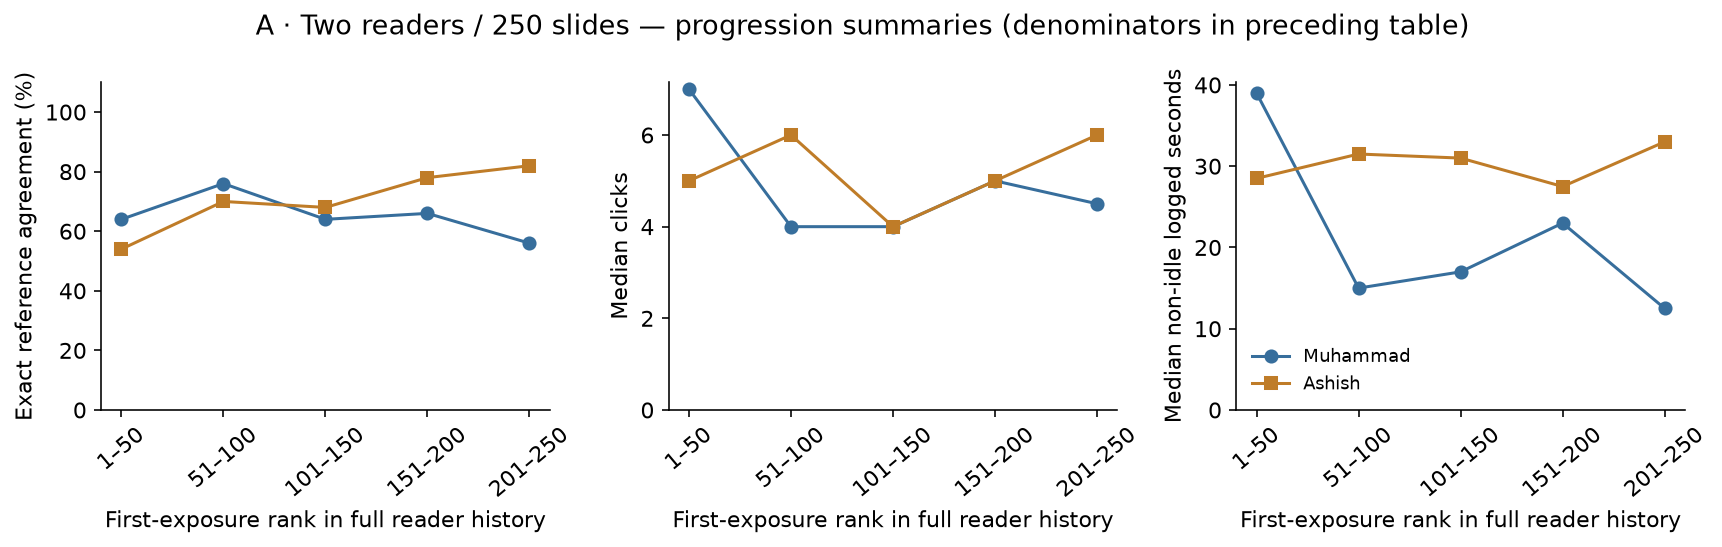

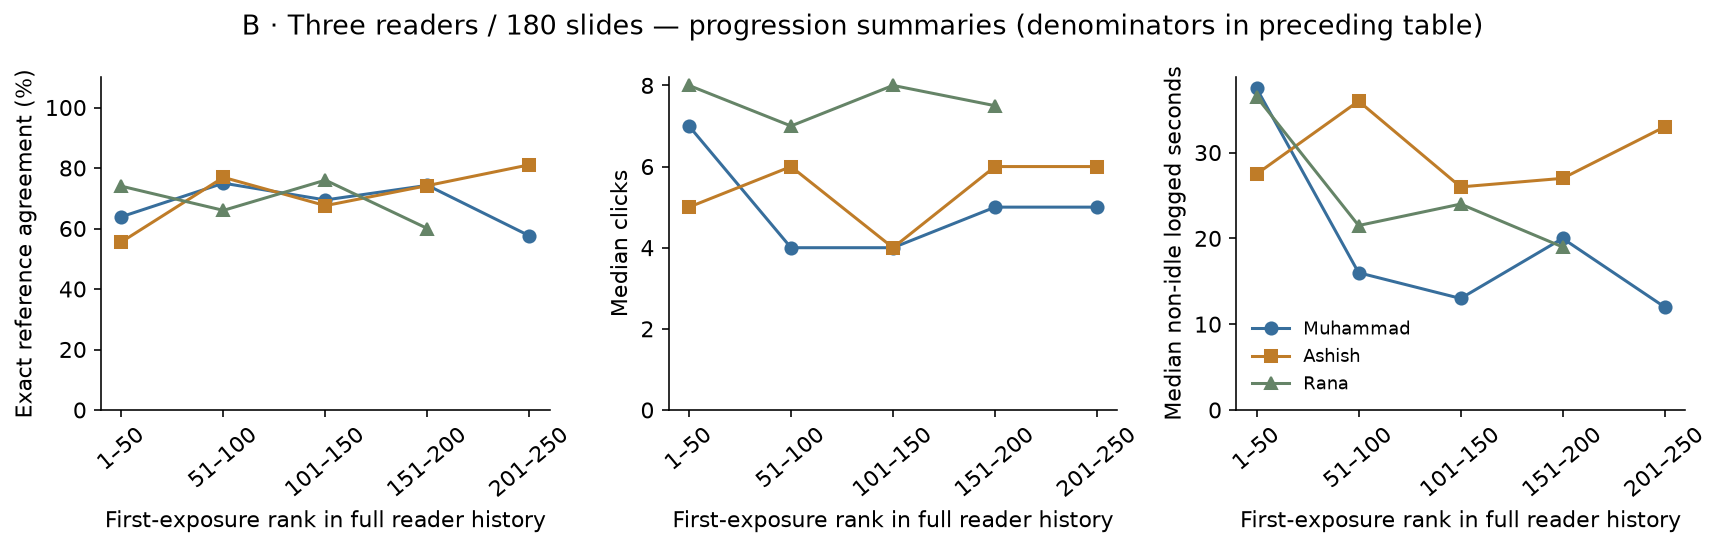

In [71]:
for q10_key in ["A","B"]:
    q10_fig,q10_axes=plt.subplots(1,3,figsize=(12,3.8))
    for q10_ax,q10_metric,q10_label in zip(q10_axes,["agreement_pct","median_clicks","median_seconds"],
        ["Exact reference agreement (%)","Median clicks","Median non-idle logged seconds"]):
        for q10_u,q10_marker in zip(cohort_readers[q10_key],["o","s","^"]):
            q10_p=q10_progress.loc[q10_progress.cohort.eq(q10_key)&q10_progress.user_id.eq(q10_u)].sort_values("band_index")
            q10_ax.plot(q10_p.band_index,q10_p[q10_metric],marker=q10_marker,color=BH_READER_COLOURS[q10_u],label=FIRST_NAMES[q10_u])
        q10_ax.set(xticks=range(5),xticklabels=["1–50","51–100","101–150","151–200","201–250"],xlabel="First-exposure rank in full reader history",ylabel=q10_label)
        q10_ax.tick_params(axis="x",rotation=40);q10_ax.set_ylim(bottom=0)
        if q10_metric=="agreement_pct":q10_ax.set_ylim(0,110)
    q10_axes[-1].legend(frameon=False,fontsize=9)
    q10_fig.suptitle(GROUP_NAMES[q10_key]+" — progression summaries (denominators in preceding table)")
    q10_fig.tight_layout();show_figure(q10_fig)

### 10.1 Check case composition before explaining a progression pattern

We also compare the first 50 observed exposures with the remaining exposures **within each reference class**. Each cell retains its own denominator. This helps reveal whether an aggregate change follows a change in class mix; it does not adjust for all differences in case difficulty. Separately show the Original 200 and Additional 50 at their observed positions. The Additional 50 were introduced later; they cannot be assumed exchangeable with the initial set for attributing a time trend.

In [72]:
q10_stratified_rows=[];q10_seed_rows=[];q10_repeat_sensitivity=[];q10_first45_rows=[]
for q10_key in ["A","B"]:
    for q10_u in cohort_readers[q10_key]:
        q10_d=q10_features.loc[q10_features.user_id.eq(q10_u)&q10_features.slide_id.isin(cohort_ids[q10_key])].copy()
        q10_d["phase"]=np.where(q10_d.exposure_order.le(50),"First 50 exposures","Later exposures")
        for q10_phase,q10_mask in [("First 45 actual exposures",q10_d.exposure_order.le(45)),("Later actual exposures",q10_d.exposure_order.gt(45))]:
            q10_g=q10_d.loc[q10_mask]
            q10_first45_rows.append({"Cohort":q10_key,"Reader":FIRST_NAMES[q10_u],"Historical cut":q10_phase,"n":len(q10_g),
                "Exact agreement":ratio_text(int(q10_g.correct.sum()),len(q10_g)),"Median clicks":float(q10_g.n_cell_click.median()),
                "Median non-idle s":float(q10_g.nonidle_s_30.median()),
                "NN/LG/HG":"/".join(str(int(q10_g.reference.eq(q10_class).sum())) for q10_class in CLASSES),
                "From Additional 50":int(q10_g.seed_group.eq("Additional 50").sum())})
        for q10_class in CLASSES:
            q10_row={"Cohort":q10_key,"Reader":FIRST_NAMES[q10_u],"Reference class":q10_class}
            for q10_phase in ["First 50 exposures","Later exposures"]:
                q10_g=q10_d.loc[q10_d.phase.eq(q10_phase)&q10_d.reference.eq(q10_class)]
                q10_row[q10_phase]=ratio_text(int(q10_g.correct.sum()),len(q10_g)) if len(q10_g) else "No observations"
            q10_stratified_rows.append(q10_row)
        for q10_seed,q10_g in q10_d.groupby("seed_group"):
            q10_seed_rows.append({"Cohort":q10_key,"Reader":FIRST_NAMES[q10_u],"Seed group":q10_seed,"n":len(q10_g),
                "Observed exposure ranks":f"{q10_g.exposure_order.min()}–{q10_g.exposure_order.max()}",
                "Exact agreement":ratio_text(int(q10_g.correct.sum()),len(q10_g)),"Median clicks":float(q10_g.n_cell_click.median()),
                "Median non-idle s":float(q10_g.nonidle_s_30.median())})
        for q10_phase,q10_g in q10_d.groupby("phase"):
            q10_single=q10_g.loc[q10_g.all_attempt_count.eq(1)]
            q10_repeat_sensitivity.append({"Cohort":q10_key,"Reader":FIRST_NAMES[q10_u],"Phase":q10_phase,
                "All retained labels":ratio_text(int(q10_g.correct.sum()),len(q10_g)),
                "Only single-attempt slides":ratio_text(int(q10_single.correct.sum()),len(q10_single)),
                "Excluded multiple-attempt slides":len(q10_g)-len(q10_single)})
    display(Markdown("**"+GROUP_NAMES[q10_key]+" — reference agreement by class**"))
    show_table(pd.DataFrame([q10_r for q10_r in q10_stratified_rows if q10_r["Cohort"]==q10_key]).drop(columns="Cohort"))
    show_table(pd.DataFrame([q10_r for q10_r in q10_seed_rows if q10_r["Cohort"]==q10_key]).drop(columns="Cohort"))
display(HTML("<details><summary>Sensitivity: exclude slides with multiple attempts</summary>"+
    pd.DataFrame(q10_repeat_sensitivity).to_html(index=False,border=0)+"</details>"))
display(Markdown("**Supplementary historical cut: first 45 actual exposures versus later.** Earlier preparation notes mentioned this split without a verified saved calculation. "
    "The table below recomputes it from this export; 45 is a fixed retrospective sensitivity cut, not an established end of learning. "
    "No first-45 slides are dropped from the primary analysis, and B preserves the full-history ranks."))
show_table(pd.DataFrame(q10_first45_rows))

**A · Two readers / 250 slides — reference agreement by class**

Reader,Reference class,First 50 exposures,Later exposures
Muhammad,non-neoplastic,10/19 (52.6%),44/52 (84.6%)
Muhammad,low-grade,17/20 (85.0%),58/75 (77.3%)
Muhammad,high-grade,5/11 (45.5%),29/73 (39.7%)
Ashish,non-neoplastic,9/10 (90.0%),51/61 (83.6%)
Ashish,low-grade,14/22 (63.6%),62/73 (84.9%)
Ashish,high-grade,4/18 (22.2%),36/66 (54.5%)


Reader,Seed group,n,Observed exposure ranks,Exact agreement,Median clicks,Median non-idle s
Muhammad,Additional 50,50,50–250,44/50 (88.0%),4.0,13.5
Muhammad,Original 200,200,1–249,119/200 (59.5%),5.0,19.0
Ashish,Additional 50,50,2–250,46/50 (92.0%),4.0,28.5
Ashish,Original 200,200,1–249,130/200 (65.0%),5.0,30.5


**B · Three readers / 180 slides — reference agreement by class**

Reader,Reference class,First 50 exposures,Later exposures
Muhammad,non-neoplastic,6/13 (46.2%),33/37 (89.2%)
Muhammad,low-grade,12/15 (80.0%),43/55 (78.2%)
Muhammad,high-grade,5/8 (62.5%),24/52 (46.2%)
Ashish,non-neoplastic,7/8 (87.5%),36/42 (85.7%)
Ashish,low-grade,10/17 (58.8%),44/53 (83.0%)
Ashish,high-grade,3/11 (27.3%),28/49 (57.1%)
Rana,non-neoplastic,7/7 (100.0%),33/43 (76.7%)
Rana,low-grade,17/22 (77.3%),36/48 (75.0%)
Rana,high-grade,13/21 (61.9%),20/39 (51.3%)


Reader,Seed group,n,Observed exposure ranks,Exact agreement,Median clicks,Median non-idle s
Muhammad,Additional 50,37,50–245,35/37 (94.6%),4.0,13.0
Muhammad,Original 200,143,3–249,88/143 (61.5%),5.0,18.0
Ashish,Additional 50,37,5–246,36/37 (97.3%),4.0,28.0
Ashish,Original 200,143,1–249,92/143 (64.3%),6.0,32.0
Rana,Additional 50,37,1–168,35/37 (94.6%),7.0,19.0
Rana,Original 200,143,2–180,91/143 (63.6%),8.0,28.0


Cohort,Reader,Phase,All retained labels,Only single-attempt slides,Excluded multiple-attempt slides
A,Muhammad,First 50 exposures,32/50 (64.0%),30/46 (65.2%),4
A,Muhammad,Later exposures,131/200 (65.5%),131/200 (65.5%),0
A,Ashish,First 50 exposures,27/50 (54.0%),27/50 (54.0%),0
A,Ashish,Later exposures,149/200 (74.5%),148/197 (75.1%),3
B,Muhammad,First 50 exposures,23/36 (63.9%),22/33 (66.7%),3
B,Muhammad,Later exposures,100/144 (69.4%),100/144 (69.4%),0
B,Ashish,First 50 exposures,20/36 (55.6%),20/36 (55.6%),0
B,Ashish,Later exposures,108/144 (75.0%),107/141 (75.9%),3
B,Rana,First 50 exposures,37/50 (74.0%),34/46 (73.9%),4
B,Rana,Later exposures,89/130 (68.5%),86/126 (68.3%),4


**Supplementary historical cut: first 45 actual exposures versus later.** Earlier preparation notes mentioned this split without a verified saved calculation. The table below recomputes it from this export; 45 is a fixed retrospective sensitivity cut, not an established end of learning. No first-45 slides are dropped from the primary analysis, and B preserves the full-history ranks.

Cohort,Reader,Historical cut,n,Exact agreement,Median clicks,Median non-idle s,NN/LG/HG,From Additional 50
A,Muhammad,First 45 actual exposures,45,27/45 (60.0%),7.0,41.0,17/17/11,0
A,Muhammad,Later actual exposures,205,136/205 (66.3%),4.0,16.0,54/78/73,50
A,Ashish,First 45 actual exposures,45,24/45 (53.3%),5.0,29.0,9/21/15,7
A,Ashish,Later actual exposures,205,152/205 (74.1%),5.0,31.0,62/74/69,43
B,Muhammad,First 45 actual exposures,34,21/34 (61.8%),7.0,39.0,12/14/8,0
B,Muhammad,Later actual exposures,146,102/146 (69.9%),4.0,15.0,38/56/52,37
B,Ashish,First 45 actual exposures,34,19/34 (55.9%),5.0,28.5,7/17/10,5
B,Ashish,Later actual exposures,146,109/146 (74.7%),5.0,31.5,43/53/50,32
B,Rana,First 45 actual exposures,45,33/45 (73.3%),8.0,37.0,5/21/19,15
B,Rana,Later actual exposures,135,93/135 (68.9%),8.0,22.0,45/49/41,22


### 10.2 Within activity bouts: a separate, explicitly inferred time scale

The app's `session_id` identifies a **reader–slide record**, not a laboratory reading session. We infer activity bouts from each reader's full event history: start a new bout after an event gap **greater than 30 minutes**, a new UTC date, or a recorded idle period >30 minutes ending in `idle_end`. The date boundary prevents different calendar days being joined; UTC is retained consistently with Question 0. Bouts are only runs of recorded activity, not verified uninterrupted work. We repeat with 15- and 60-minute thresholds.

For each bout containing at least 10 retained labelled slides, compare its **first five and last five retained slides**. Define those windows in the reader's full history before applying cohort B. Exclude attempts spanning multiple inferred bouts, so their accumulated behaviour is not assigned to one bout. A cohort-specific bout comparison must retain at least three slides in each window. This means cohort B can have fewer eligible bouts and fewer than five slides per window. Compare within the same bout, then summarize the paired differences across bouts with equal weight per bout; the table reports the number of bouts and slide observations. This avoids treating a large bout as several independent sessions.

In [73]:
Q10_BOUT_GAPS_MINUTES=[15,30,60]
def q10_assign_bouts(gap_minutes):
    q10_mapping=[]
    for q10_u,q10_g in events.loc[events.user_id.isin(THREE)].groupby("user_id",sort=False):
        q10_g=q10_g.sort_values(["timestamp","source_row"],kind="stable")
        q10_bout=0;q10_previous=None;q10_idle_start=None
        for q10_r in q10_g.itertuples(index=False):
            q10_boundary=q10_previous is None or (q10_r.timestamp-q10_previous).total_seconds()>60*gap_minutes or q10_r.timestamp.date()!=q10_previous.date()
            if q10_r.event=="idle_end" and q10_idle_start is not None:
                q10_boundary=q10_boundary or (q10_r.timestamp-q10_idle_start).total_seconds()>60*gap_minutes
            if q10_boundary:q10_bout+=1
            if q10_r.event in BH_LOAD_EVENTS:q10_idle_start=None
            elif q10_r.event=="idle_start":q10_idle_start=q10_r.timestamp
            elif q10_r.event=="idle_end":q10_idle_start=None
            q10_mapping.append({"source_row":q10_r.source_row,"bout":q10_bout})
            q10_previous=q10_r.timestamp
    return pd.DataFrame(q10_mapping)

def q10_bout_comparisons(gap_minutes):
    q10_map=q10_assign_bouts(gap_minutes)
    q10_e=bh_selected.merge(q10_map,on="source_row",validate="one_to_one")
    q10_bounds=q10_e.groupby(["user_id","slide_id"]).agg(bout=("bout","last"),n_bouts=("bout","nunique"),first_row=("source_row","first"))
    q10_d=q10_features.merge(q10_bounds,on=["user_id","slide_id"],validate="one_to_one")
    q10_eligible=q10_d.loc[q10_d.n_bouts.eq(1)].sort_values(["first_timestamp","first_row"],kind="stable").copy()
    q10_eligible["position"]=q10_eligible.groupby(["user_id","bout"]).cumcount()+1
    q10_eligible["bout_n"]=q10_eligible.groupby(["user_id","bout"]).slide_id.transform("size")
    q10_eligible=q10_eligible.loc[q10_eligible.bout_n.ge(10)].copy()
    q10_eligible["window"]=np.select([q10_eligible.position.le(5),q10_eligible.position.gt(q10_eligible.bout_n-5)],["First five","Last five"],default="Middle")
    q10_pairs=[]
    for q10_key in ["A","B"]:
        q10_scope=q10_eligible.loc[q10_eligible.user_id.isin(cohort_readers[q10_key])&q10_eligible.slide_id.isin(cohort_ids[q10_key])]
        for (q10_u,q10_bout),q10_g in q10_scope.groupby(["user_id","bout"]):
            q10_early=q10_g.loc[q10_g.window.eq("First five")];q10_late=q10_g.loc[q10_g.window.eq("Last five")]
            if min(len(q10_early),len(q10_late))<3:continue
            q10_pair={"cohort":q10_key,"user_id":q10_u,"bout":q10_bout,"gap_minutes":gap_minutes,
                "early_n":len(q10_early),"late_n":len(q10_late),"date":str(q10_g.first_timestamp.min().date())}
            for q10_name,q10_w in [("early",q10_early),("late",q10_late)]:
                q10_pair.update({q10_name+"_accuracy":100*q10_w.correct.mean(),q10_name+"_clicks":float(q10_w.n_cell_click.median()),
                    q10_name+"_seconds":float(q10_w.nonidle_s_30.median()),q10_name+"_hg_pct":100*q10_w.reference.eq("high-grade").mean(),
                    q10_name+"_additional_pct":100*q10_w.seed_group.eq("Additional 50").mean()})
            q10_pairs.append(q10_pair)
    q10_counts=q10_d.groupby("user_id").agg(retained_slides=("slide_id","size"),attempts_spanning_bouts=("n_bouts",lambda q10_x:int(q10_x.gt(1).sum())))
    q10_all=events.loc[events.user_id.isin(THREE)].merge(q10_map,on="source_row",validate="one_to_one")
    q10_bout_inventory=q10_all.groupby("user_id").bout.nunique()
    return pd.DataFrame(q10_pairs),q10_counts,q10_bout_inventory

q10_bout_results={q10_gap:q10_bout_comparisons(q10_gap) for q10_gap in Q10_BOUT_GAPS_MINUTES}
q10_bout_pairs=q10_bout_results[30][0]
q10_bout_summary_rows=[]
for q10_gap,(q10_p,q10_counts,q10_inventory) in q10_bout_results.items():
    for q10_key in ["A","B"]:
        for q10_u in cohort_readers[q10_key]:
            q10_g=q10_p.loc[q10_p.cohort.eq(q10_key)&q10_p.user_id.eq(q10_u)]
            q10_bout_summary_rows.append({"Cohort":q10_key,"Reader":FIRST_NAMES[q10_u],"Gap threshold (min)":q10_gap,
                "All reader bouts":int(q10_inventory.loc[q10_u]),"Paired eligible bouts":len(q10_g),
                "First/last window slides":f"{int(q10_g.early_n.sum())}/{int(q10_g.late_n.sum())}",
                "Mean agreement change (pp)":float((q10_g.late_accuracy-q10_g.early_accuracy).mean()),
                "Median paired click change":float((q10_g.late_clicks-q10_g.early_clicks).median()),
                "Median paired seconds change":float((q10_g.late_seconds-q10_g.early_seconds).median()),
                "Mean high-grade share change (pp)":float((q10_g.late_hg_pct-q10_g.early_hg_pct).mean()),
                "Mean Additional50 share change (pp)":float((q10_g.late_additional_pct-q10_g.early_additional_pct).mean())})
q10_bout_summary=pd.DataFrame(q10_bout_summary_rows)
for q10_key in ["A","B"]:
    display(Markdown("**"+GROUP_NAMES[q10_key]+" — primary 30-minute rule; changes are last minus first**"))
    q10_t=q10_bout_summary.loc[q10_bout_summary.Cohort.eq(q10_key)&q10_bout_summary["Gap threshold (min)"].eq(30)]
    show_table(q10_t.drop(columns=["Cohort","Gap threshold (min)"]).round(1))
display(HTML("<details><summary>15-, 30- and 60-minute bout-threshold sensitivity</summary>"+q10_bout_summary.round(1).to_html(index=False,border=0)+"</details>"))
display(HTML("<details><summary>Inspect each paired bout (30-minute rule)</summary>"+q10_bout_pairs.round(2).to_html(index=False,border=0)+"</details>"))
show_table(q10_bout_results[30][1].reset_index().rename(columns={"user_id":"Reader","retained_slides":"Retained slides","attempts_spanning_bouts":"Excluded from within-bout analysis: multi-bout attempt"}))

**A · Two readers / 250 slides — primary 30-minute rule; changes are last minus first**

Reader,All reader bouts,Paired eligible bouts,First/last window slides,Mean agreement change (pp),Median paired click change,Median paired seconds change,Mean high-grade share change (pp),Mean Additional50 share change (pp)
Muhammad,8,5,25/25,8.0,0.0,0.0,-4.0,-4.0
Ashish,6,5,25/25,32.0,-1.0,-4.0,-16.0,12.0


**B · Three readers / 180 slides — primary 30-minute rule; changes are last minus first**

Reader,All reader bouts,Paired eligible bouts,First/last window slides,Mean agreement change (pp),Median paired click change,Median paired seconds change,Mean high-grade share change (pp),Mean Additional50 share change (pp)
Muhammad,8,3,10/12,-37.2,-2.0,-4.0,12.2,-12.8
Ashish,6,4,16/15,39.2,-0.8,-2.8,-12.9,3.8
Rana,14,5,25/25,-20.0,2.0,-5.0,24.0,0.0


Cohort,Reader,Gap threshold (min),All reader bouts,Paired eligible bouts,First/last window slides,Mean agreement change (pp),Median paired click change,Median paired seconds change,Mean high-grade share change (pp),Mean Additional50 share change (pp)
A,Muhammad,15,9,5,25/25,8.0,0.0,-5.0,-4.0,-4.0
A,Ashish,15,6,5,25/25,32.0,-1.0,-4.0,-16.0,12.0
B,Muhammad,15,9,3,10/12,-26.1,-2.0,-4.5,1.1,-12.8
B,Ashish,15,6,4,16/15,39.2,-0.8,-2.8,-12.9,3.8
B,Rana,15,14,5,25/25,-20.0,2.0,-5.0,24.0,0.0
A,Muhammad,30,8,5,25/25,8.0,0.0,0.0,-4.0,-4.0
A,Ashish,30,6,5,25/25,32.0,-1.0,-4.0,-16.0,12.0
B,Muhammad,30,8,3,10/12,-37.2,-2.0,-4.0,12.2,-12.8
B,Ashish,30,6,4,16/15,39.2,-0.8,-2.8,-12.9,3.8
B,Rana,30,14,5,25/25,-20.0,2.0,-5.0,24.0,0.0


cohort,user_id,bout,gap_minutes,early_n,late_n,date,early_accuracy,early_clicks,early_seconds,early_hg_pct,early_additional_pct,late_accuracy,late_clicks,late_seconds,late_hg_pct,late_additional_pct
A,ashish.bansal,1,30,5,5,2026-04-09,40.00,8.0,47.0,60.0,40.00,60.00,2.0,11.0,60.00,20.00
A,ashish.bansal,2,30,5,5,2026-04-10,40.00,4.0,26.0,60.0,0.00,100.00,10.0,36.0,60.00,20.00
A,ashish.bansal,4,30,5,5,2026-06-13,80.00,2.0,35.0,40.0,40.00,100.00,4.0,23.0,0.00,40.00
A,ashish.bansal,5,30,5,5,2026-06-19,40.00,5.0,32.0,20.0,20.00,80.00,4.0,28.0,0.00,40.00
A,ashish.bansal,6,30,5,5,2026-06-19,80.00,13.0,41.0,40.0,20.00,100.00,6.0,38.0,20.00,60.00
A,muhammad.aslam,1,30,5,5,2026-03-26,60.00,6.0,34.0,40.0,0.00,40.00,5.0,62.0,0.00,0.00
A,muhammad.aslam,5,30,5,5,2026-04-01,60.00,7.0,23.0,0.0,0.00,100.00,8.0,38.0,20.00,0.00
A,muhammad.aslam,6,30,5,5,2026-05-07,100.00,6.0,18.0,0.0,20.00,80.00,6.0,13.0,20.00,20.00
A,muhammad.aslam,7,30,5,5,2026-05-07,40.00,5.0,20.0,40.0,60.00,80.00,3.0,10.0,40.00,20.00
A,muhammad.aslam,8,30,5,5,2026-05-07,40.00,4.0,11.0,60.0,20.00,40.00,4.0,11.0,40.00,40.00


Reader,Retained slides,Excluded from within-bout analysis: multi-bout attempt
ashish.bansal,250,1
iftikhar.rana,180,0
muhammad.aslam,250,3


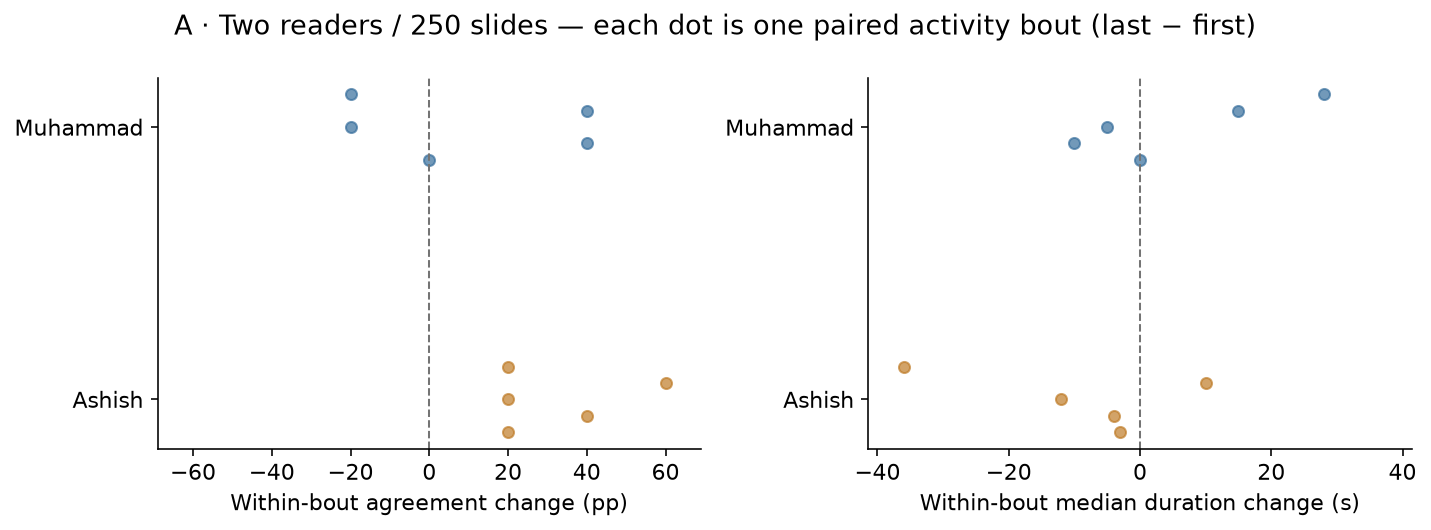

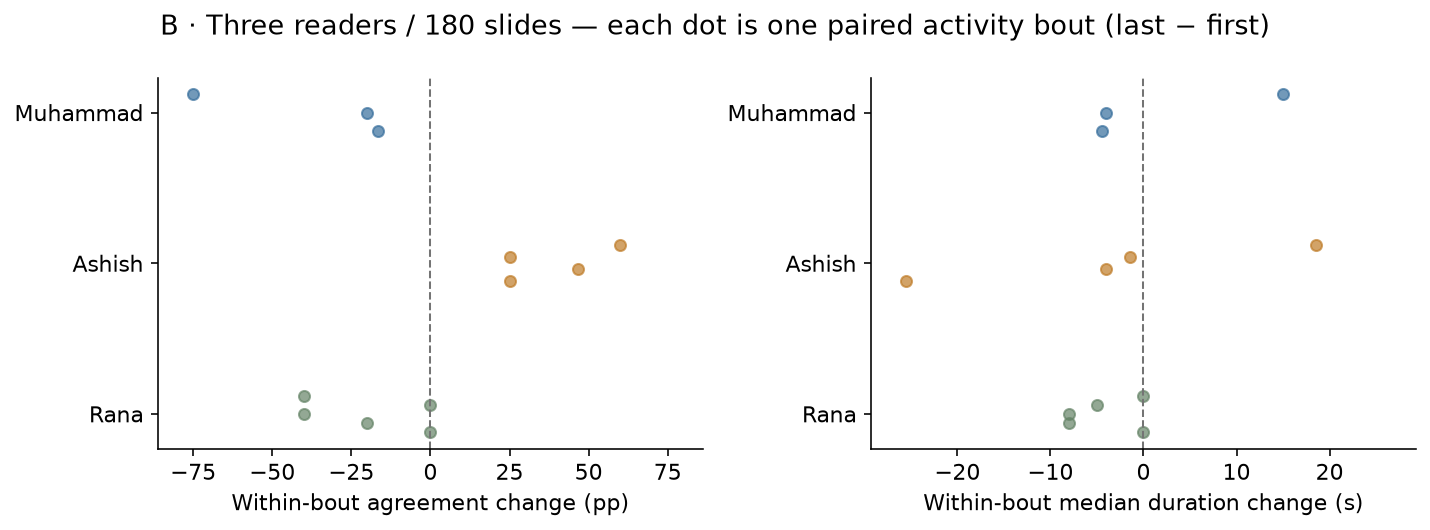

In [74]:
for q10_key in ["A","B"]:
    q10_fig,q10_axes=plt.subplots(1,2,figsize=(10,3.7))
    for q10_ax,q10_metric,q10_label in zip(q10_axes,["accuracy","seconds"],["Within-bout agreement change (pp)","Within-bout median duration change (s)"]):
        q10_limit=1
        for q10_i,q10_u in enumerate(cohort_readers[q10_key]):
            q10_g=q10_bout_pairs.loc[q10_bout_pairs.cohort.eq(q10_key)&q10_bout_pairs.user_id.eq(q10_u)]
            q10_values=q10_g["late_"+q10_metric]-q10_g["early_"+q10_metric]
            q10_offsets=np.linspace(-.12,.12,len(q10_values)) if len(q10_values)>1 else np.zeros(len(q10_values))
            q10_ax.scatter(q10_values,np.full(len(q10_values),q10_i)+q10_offsets,s=30,color=BH_READER_COLOURS[q10_u],alpha=.7)
            if len(q10_values):q10_limit=max(q10_limit,float(q10_values.abs().max())*1.15)
        q10_ax.axvline(0,color="#747474",linestyle="--",linewidth=1)
        q10_ax.set(xlim=(-q10_limit,q10_limit),yticks=range(len(cohort_readers[q10_key])),
            yticklabels=[FIRST_NAMES[q10_u] for q10_u in cohort_readers[q10_key]],xlabel=q10_label)
        q10_ax.invert_yaxis()
    q10_fig.suptitle(GROUP_NAMES[q10_key]+" — each dot is one paired activity bout (last − first)")
    q10_fig.tight_layout();show_figure(q10_fig)

### 10.3 What this can and cannot establish

The figures show whether the observed measures move with order, and whether early/late differences recur within the **same inferred bouts**. They do not identify why. The reader, reference class, case difficulty, Original 200/Additional 50 mix, long calendar breaks, and familiarity with the interface can all change together. In a short five-slide window, one diagnosis changes agreement by 20 percentage points (and more when cohort B retains fewer slides). A handful of inferred bouts provides a fragile basis for broad claims.

Do not call an early/late difference fatigue or learning on this evidence alone. The result is a descriptive pattern to discuss, with its denominators and sensitivity checks. A stronger causal study would require a prespecified exposure/order design, usable reading-session boundaries and a way to distinguish case mix from within-reader change.

In [75]:
q9_checks=[]
# Independent label-transition calculation from the selected raw event strings.
q9_independent={}
for (q9_u,q9_slide),q9_g in bh_selected.groupby(["user_id","slide_id"]):
    q9_labels=q9_g.loc[q9_g.event.isin(["label_select","slide_next"])&q9_g.label.ne("")].sort_values(["timestamp","source_row"]).label.tolist()
    q9_independent[(q9_u,q9_slide)]=sum(q9_a!=q9_b for q9_a,q9_b in zip(q9_labels,q9_labels[1:]))
for q9_r in q9_primary.itertuples(index=False):assert q9_r.label_transitions==q9_independent[(q9_r.user_id,q9_r.slide_id)]
for q10_key in ["A","B"]:
    for q10_u in cohort_readers[q10_key]:
        q10_p=q10_progress.loc[q10_progress.cohort.eq(q10_key)&q10_progress.user_id.eq(q10_u)]
        assert q10_p.n.sum()==len(cohort_ids[q10_key])
        assert (q10_p.non_neoplastic+q10_p.low_grade+q10_p.high_grade).eq(q10_p.n).all()
        assert q10_p.agreement_count.sum()==int(cohorts[q10_key].loc[cohorts[q10_key].user_id.eq(q10_u)].diagnosis.eq(cohorts[q10_key].loc[cohorts[q10_key].user_id.eq(q10_u)].reference).sum())
# Cohort B uses the already assigned full-history ranks; no subset ranking is performed.
assert not q10_first.duplicated(["user_id","exposure_order"]).any()
assert q9_primary.first_selection_latency_s.dropna().ge(0).all()
for q10_gap,(q10_p,_,_) in q10_bout_results.items():
    assert q10_p.early_n.between(3,5).all() and q10_p.late_n.between(3,5).all()
    assert not q10_p.duplicated(["cohort","user_id","bout"]).any()
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()==input_sha256
print("PASS: independent label-transition counts; cohort denominators; progression class totals and Q1 agreement reconciliation; full-history exposure ranks; paired-bout eligibility; input unchanged.")
q10_takeaway=[]
for q10_u in THREE:
    q10_p=q10_progress.loc[q10_progress.cohort.eq("B")&q10_progress.user_id.eq(q10_u)].sort_values("band_index")
    q10_first_band=q10_p.iloc[0];q10_last_band=q10_p.iloc[-1]
    q10_takeaway.append(f"{FIRST_NAMES[q10_u]}: first observed band **{int(q10_first_band.agreement_count)}/{int(q10_first_band.n)}** exact agreement, "
        f"last observed band **{int(q10_last_band.agreement_count)}/{int(q10_last_band.n)}**. These bands occupy that reader's own full-history ranks.")
display(Markdown("**Question 10 reading aid — shared 180 slides.**\n\n"+"\n\n".join(q10_takeaway)+
    "\n\nRead these endpoint counts with the composition tables and within-bout plot; they do not by themselves establish learning or fatigue."))

PASS: independent label-transition counts; cohort denominators; progression class totals and Q1 agreement reconciliation; full-history exposure ranks; paired-bout eligibility; input unchanged.


**Question 10 reading aid — shared 180 slides.**

Muhammad: first observed band **23/36** exact agreement, last observed band **19/33**. These bands occupy that reader's own full-history ranks.

Ashish: first observed band **20/36** exact agreement, last observed band **30/37**. These bands occupy that reader's own full-history ranks.

Rana: first observed band **37/50** exact agreement, last observed band **18/30**. These bands occupy that reader's own full-history ranks.

Read these endpoint counts with the composition tables and within-bout plot; they do not by themselves establish learning or fatigue.

## Checks and calculation record

The following checks verify cohort membership, matrix totals, label sources and arithmetic identities. An external verification during authoring also reconstructed Q1 with standard-library CSV/date parsing and direct counts, without the old analysis helpers. That independent check and the historical Q1 snapshot agree with the displayed results; older results were not used to compute these tables.

**Presentation verification:** the original five figures remain unchanged, and all three new Question 2 figures were visually inspected locally; saved table outputs were also checked. The full notebook page was not inspected in a browser; that layout check remains unverified.

Question 2 is also checked against independent raw-CSV pairing/counting and scikit-learn coefficients. The original Question 0–1 calculation cells are preserved.

Questions 3–5 add a diagnosis-bounded behavioural feature table. Independent implementations checked all 680 reader–slide records for feature construction, timing and common-set rank correlations. Prior Question 0–2 calculation sources and outputs remain preserved; current figure review status is recorded in the notebook validation metadata.

**Question 3–5 presentation check:** all nine new figures were inspected locally; two distribution plots were simplified after overlapping annotations were observed. The final calculation cells ran top-to-bottom, and saved tables/results were checked. Full-page browser layout remains unverified after the earlier research-data approval block; no browser was retried.

The initial Questions 6–10 extension adds class/outcome comparisons, spatial exposure maps with controls and sensitivities, recorded label transitions, repeat-attempt auditing and chronological/activity-bout descriptions. Validation combines independent raw-data calculations, arithmetic identities, cross-question count reconciliation and local figure inspection. The final execution receipt is in notebook metadata. Earlier computational cells and outputs are preserved.

**Final initial-analysis verification:** all 76 calculation cells executed successfully; 125 Question 6/8 group summaries matched independent calculations, 150 spatial bin probabilities matched direct rectangle-intersection arithmetic, and chronology/label-transition counts reconciled with earlier questions. All 16 new figures were inspected locally. Earlier 51 calculation-cell sources and saved outputs remain unchanged. Full-page browser layout remains unverified after the prior automatic approval block for research-data access; no browser retry was attempted.

In [76]:
for key in ["A","B"]:
    for user in cohort_readers[key]:
        frame=cohorts[key][cohorts[key].user_id.eq(user)]
        m=matrices[key][user]; s=statistics[key][user]
        assert int(m.to_numpy().sum()) == s["n"] == len(cohort_ids[key])
        assert m.sum(axis=1).reindex(CLASSES).tolist() == reference.loc[cohort_ids[key]].value_counts().reindex(CLASSES,fill_value=0).tolist()
        assert s["exact"]+s["under"]+s["over"] == s["n"]
        assert s["binary"] >= s["exact"]
assert set(cohort_ids["B"]).issubset(cohort_ids["A"])
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest() == input_sha256
print("PASS: input identity; schema and label checks; paired cohort membership; one label per reader-slide; matrix totals; independent arithmetic identities; raw export unchanged.")
display(Markdown("**Question 1 result recap — the two populations remain separate.**"))
for key in ["A","B"]:
    display(Markdown("**"+GROUP_NAMES[key]+"**")); show_table(summary_table(key))

PASS: input identity; schema and label checks; paired cohort membership; one label per reader-slide; matrix totals; independent arithmetic identities; raw export unchanged.


**Question 1 result recap — the two populations remain separate.**

**A · Two readers / 250 slides**

Reader,Labelled slides,Exact three-class agreement,Combined low/high agreement
Muhammad Aslam,250,163/250 (65.2%),217/250 (86.8%)
Ashish Bansal,250,176/250 (70.4%),221/250 (88.4%)


**B · Three readers / 180 slides**

Reader,Labelled slides,Exact three-class agreement,Combined low/high agreement
Muhammad Aslam,180,123/180 (68.3%),156/180 (86.7%)
Ashish Bansal,180,128/180 (71.1%),158/180 (87.8%)
Iftikhar Rana,180,126/180 (70.0%),157/180 (87.2%)


## Initial analysis: synthesis, limitations and next decisions

The completed scope is the descriptive analysis of the September 15 export under the two fixed cohorts. The findings-at-a-glance section at the top is generated from the executed results. This is a selected-slide, small-reader study; it cannot support a general ranking of pathologists, causal claims about effort, or clinical adjudication of the reference.

The strongest methodological distinctions to retain in any later presentation are:

- Diagnostic agreement with a reference, agreement between readers, and spatial exposure similarity are different quantities.
- Events, attempts, reader–slide diagnoses, image IDs and patients are different observation units. The 180-slide cohort overlaps the 250-slide cohort.
- Magnification and viewport position are logged display measures. Duration is estimated from event intervals, and eye attention or decisive tissue is not observed.
- Behavioural associations depend on class composition and reader-specific choices. Greater zoom or longer time does not establish their causal effect on agreement.
- Repeated selections are not repeated diagnoses; one paired labelled re-reading is insufficient for reliability inference.
- Order and inferred activity-bout patterns remain confounded by case mix, calendar gaps and study selection.

### What remains outside this initial analysis

| Follow-up | Additional evidence or decision needed |
|---|---|
| Expert review of shared reference disagreements | Independent case-level review/adjudication; current labels must not be replaced by majority vote. |
| Tissue-normalised coverage or first encounter with decisive tissue | Verified slide dimensions, tissue/lesion annotations and coordinate alignment. |
| Matched human–AdaZoom comparison | Appropriate out-of-fold predictions/routes, eligible slide membership, coordinate alignment and patient grouping. |
| Human-guided model training | An approved learning objective, leakage-aware split and independent evaluation. |
| A causal fatigue/learning or test–retest study | Prespecified order/session design, adequate paired readings and control of case composition. |

These follow-ups are identified dependencies, not unfinished calculations silently omitted from Questions 0–10.

### Sources and provenance

- Raw input: `pathology_events_2026-09-15.csv`, checked against the SHA-256 printed in Question 0. Original export remains unchanged and separate from the notebook.
- Study manifest: `backend/src/seed-slide-list.ts`; a dated snapshot is embedded, its file hash is printed, and every exported slide ID/reference label is checked against it.
- Export/completion implementation inspected: `backend/src/routes/admin.ts` (event CSV, including reference-label join); `backend/src/routes/slides.ts` (completion timestamp); `src/viewer/main.ts` (`label_select` / `slide_next` event sequence). These code reads establish export semantics, not a current live-database check.
- Previous reference artifacts, used only for authoring checks: `analysis/reports/results.json` and `analysis/snapshots/2026-09-15/q1-results.json`. The new notebook has no computational dependency on them.
- [Official IMP-CRS 2024 dataset record](https://rdm.inesctec.pt/dataset/nis-2023-008), DOI [10.25747/fb1q-j507](https://doi.org/10.25747/fb1q-j507), accessed September 22, 2026.
- [Neto et al. (2024), An interpretable machine learning system for colorectal cancer diagnosis from pathology slides](https://www.nature.com/articles/s41698-024-00539-4), Methods—Datasets and Clinical evaluation, accessed September 22, 2026. Dataset-level labelling procedure is kept distinct from later test-case re-review.
- [Cohen's kappa: scikit-learn definition and formula](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.cohen_kappa_score.html), accessed September 22, 2026. Coefficients are calculated directly and the weighting convention declared.
- Behavioural semantics: current study source in src/viewer/main.ts (event logging, DZI mapping, polling/idle, click/pan and page visibility) and backend/src/routes/admin.ts (export timestamp precision). Local source was inspected on September 22; a constant app-version field does not prove all historical deployments were identical.
- [SciPy Spearman rank-correlation definition](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html), accessed September 22, 2026. The notebook calculates rank correlations directly, with average ranks for ties and undefined results for constant inputs.
- Question provenance: June 16/30 and August 18 supervision discussions, consolidated in SecondBrain's `phd/user-study/2026-09-22-question-coverage-audit.md`. September 22 conversation approves Questions 0–10 and the two matched cohorts. The audit is a navigation source, not numerical evidence.

**Review status:** the initial descriptive Questions 0–10 are executed for the fixed September 15 snapshot. A sparse or unidentifiable result is reported as such, rather than treated as proof of no effect. Interpretation and any subsequent scientific claims remain for Connor and Jiaxiang to review. No external handoff or publication has occurred.